In [4]:
from pathlib import Path
import webbrowser

# 匯入自訂模組
from data_loader import load_and_preprocess
from voyage_splitter import detect_stops, split_voyages, voyage_quality_checker
from visualization import visualize_voyages
from od_marker import assign_ports
from Trajectory_Recon import TrajectoryReconstructor

## 短距離修復 & 測試

In [ ]:
import importlib, visualization
importlib.reload(visualization)
from visualization import visualize_voyages_with_gaps
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "Device_AB00030.csv"
target_mmsi = 636012794


print("載入與前處理資料中...")
df = load_and_preprocess(csv_path, target_mmsi)
print(f"清理後資料筆數: {len(df)}")

    # -----------------------------------
    # Step 2: 停泊判斷
    # -----------------------------------
print("執行停泊判斷...")
stop_segments = detect_stops(df)
print(f"偵測到停泊區段數量: {len(stop_segments)}")

    # -----------------------------------
    # Step 3: 航程切分
    # -----------------------------------
print("切分航程...")
df_with_voyages, voyages = split_voyages(df, stop_segments)
print(f"切分後航程數量: {len(voyages)}")
#voyages_test = df_with_voyages[df_with_voyages['voyage_id'] == 579]
#visualize_voyages(df_with_voyages, voyages_test)
visualize_voyages(df_with_voyages, voyages)
import webbrowser

webbrowser.open("voyages_map.html")

print("執行航程 QA 檢查...")
voyages_qc = voyage_quality_checker(df_with_voyages, voyages)
print(f"QA 完成，有效航程數量: {voyages_qc['valid_flag'].sum()}")

#voyages_test = voyages_qc[voyages_qc["voyage_id"] == 101].copy()
#visualize_voyages_with_gaps(df_with_voyages, voyages_test)
#import webbrowser
#webbrowser.open("voyages_map.html")



載入與前處理資料中...
清理後資料筆數: 1072505
執行停泊判斷...
偵測到停泊區段數量: 108
切分航程...
切分後航程數量: 107
Map saved to voyages_map.html
執行航程 QA 檢查...
QA 完成，有效航程數量: 56


In [22]:
voyages_test = voyages_qc[voyages_qc["voyage_id"] == 81].copy()
visualize_voyages_with_gaps(df_with_voyages, voyages_test)
import webbrowser
webbrowser.open("voyages_map.html")

Map with gaps saved to voyages_map.html


True

In [11]:
import data_loader
import importlib
importlib.reload(data_loader)

print("✅ 檢查函式來源：", data_loader.__file__)

# 顯示關鍵行確認是不是舊的版本
import inspect
print(inspect.getsource(data_loader.load_and_preprocess)[:500])



✅ 檢查函式來源： c:\Users\slab\Desktop\Slab Project\Stage2 ETA\data_loader.py
def load_and_preprocess(csv_path: Path, target_mmsi: int) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)

    # -----------------------------------
    # 經度欄位名稱處理
    # -----------------------------------
    if "Long" in df.columns:
        pass
    elif "Lng" in df.columns:
        df = df.rename(columns={"Lng": "Long"})
    else:
        print(f" 找不到經度欄位，欄位清單: {list(df.columns)}")
        raise ValueError("請確認經度欄位名稱 (必須是 Long 或 Lng)")

    # --------------------------------


In [13]:
from data_loader import load_and_preprocess
from pathlib import Path

csv_path = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Device_AB00030.csv")
target_mmsi = 636012794

df = load_and_preprocess(csv_path, target_mmsi)
print(df.head(3))
print(df["MMSI"].unique())


   PKY           Timestamp  MsgId  \
0   59 2024-03-08 16:35:28    3.0   
1   81 2024-03-08 16:38:29    3.0   
2  117 2024-03-08 16:41:29    3.0   

                                     OriginMessage         MMSI        Lat  \
0  !AIVDM,1,1,,A,39NS8vQ002`iLEHAgMR4kbtH0000,0*6C  636012794.0  31.005667   
1  !AIVDM,1,1,,B,39NS8vQ003`iLClAgMTaM:pL0000,0*61  636012794.0  31.005683   
2  !AIVDM,1,1,,A,39NS8vQ001`iLB@AgMTVf;<J0000,0*1A  636012794.0  31.005683   

         Long    Cog  Rot    Hdg  Sog Error  NavigationStatus  \
0  122.649033  123.0  0.0  350.0  0.2   NaN               1.0   
1  122.648950  242.0  0.0  348.0  0.3   NaN               1.0   
2  122.648867  172.0  0.0  358.0  0.1   NaN               1.0   

          ReceiveTime  IsSend  SendTime    Long_360  
0  14/5/2024 11:29:58       0       NaN  122.649033  
1  14/5/2024 11:29:59       0       NaN  122.648950  
2  14/5/2024 11:30:00       0       NaN  122.648867  
[6.36012794e+08]


In [9]:
import importlib, visualization
from data_loader import load_and_preprocess
importlib.reload(visualization)
from visualization import visualize_voyages_with_gaps
csv_path = Path(r"C:\Users\slab\Desktop") / "Slab Project" / "Stage1" / "data" / "Device_AB00030.csv"
target_mmsi = 636012794


print("載入與前處理資料中...")
df = load_and_preprocess(csv_path, target_mmsi)
df.head()

載入與前處理資料中...
讀取檔案中: C:\Users\slab\Desktop\Slab Project\Stage1\data\Device_AB00030.csv


ValueError: MMSI 636012794 找不到任何資料

In [14]:
from data_loader import load_and_preprocess
df = load_and_preprocess(csv_path, 636012794)
print(df["Timestamp"].head())
print(df["Timestamp"].dtype)


0   2024-03-08 16:35:28
1   2024-03-08 16:38:29
2   2024-03-08 16:41:29
3   2024-03-08 16:44:27
4   2024-03-08 16:47:28
Name: Timestamp, dtype: datetime64[ns]
datetime64[ns]


In [29]:
import pandas as pd
path = r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Device_AB00030.csv"
df_raw = pd.read_csv(path, low_memory=False)
print(df_raw["Timestamp"].head(10))
print(df_raw["Timestamp"].dtype)

0    20240308163052
1    20240308163106
2    20240308163132
3    20240308163145
4    20240308163152
5    20240308163237
6    20240308163249
7    20240308163256
8    20240308163309
9    20240308163313
Name: Timestamp, dtype: int64
int64


In [36]:
def parse_timestamp(series: pd.Series) -> pd.Series:
    """
    嘗試解析時間欄位，支援:
    - AIS 格式: 20250711081924
    - ISO 格式: 2025-07-11T08:19:24
    """
    s = series.astype(str).str.strip()
    mask_ais14 = s.str.match(r"^\d{14}$")

    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    # 先處理 14 位數 AIS 格式
    if mask_ais14.any():
        result.loc[mask_ais14] = pd.to_datetime(
            s.loc[mask_ais14],
            format="%Y%m%d%H%M%S",
            errors="coerce"
        )

    # 其他格式
    if (~mask_ais14).any():
        result.loc[~mask_ais14] = pd.to_datetime(
            s.loc[~mask_ais14],
            errors="coerce"
        )

    return result

s = pd.Series(["20240308163052", "20240308163106"])
print(parse_timestamp(s))

0   2024-03-08 16:30:52
1   2024-03-08 16:31:06
dtype: datetime64[ns]


In [38]:
df = load_and_preprocess(csv_path, 636012794)
print(df["Timestamp"].head())

0   1970-01-01 05:37:20.308163528
1   1970-01-01 05:37:20.308163829
2   1970-01-01 05:37:20.308164129
3   1970-01-01 05:37:20.308164427
4   1970-01-01 05:37:20.308164728
Name: Timestamp, dtype: datetime64[ns]


In [14]:
voyages_test = voyages_qc[voyages_qc["voyage_id"] == 743].copy()

In [15]:
import sys
import importlib
from Trajectory_Recon import TrajectoryReconstructor
from datetime import datetime

# ----------------------------
# 建立「雙重輸出」的 log class
# ----------------------------
import sys
from datetime import datetime
from IPython import get_ipython

class SafeDualLogger:
    """安全雙輸出：不修改 sys.stdout"""
    def __init__(self, filename):
        self.filename = filename
        with open(filename, "a", encoding="utf-8") as f:
            f.write(f"\n--- Logging started at {datetime.now()} ---\n")

    def log(self, message):
        # 1️⃣ 顯示在 Notebook cell
        print(message)
        # 2️⃣ 同步寫入 log 檔
        with open(self.filename, "a", encoding="utf-8") as f:
            f.write(message + "\n")


logger = SafeDualLogger("reconstruction_debug.log")
logger.log("載入與前處理資料中...")
logger.log(f"清理後資料筆數: {len(df)}")
# ----------------------------
# 執行主程式
# ----------------------------
import Trajectory_Recon
importlib.reload(Trajectory_Recon)

reconstructor = TrajectoryReconstructor()
df_recon, gap_summary = reconstructor.reconstruct_voyages(
    df=df_with_voyages,
    voyages_summary=voyages_test,
    target_reason="R5_missing_time_gap",
    verbose=True,
)

print(f"\n修復完成，共插入 {gap_summary['inserted_points'].sum()} 筆點")
print("Gap Summary:")
print(gap_summary.head())

# 視覺化與結果開啟
visualize_voyages_with_gaps(df_recon, voyages_test)
import webbrowser
webbrowser.open("voyages_map.html")




載入與前處理資料中...
清理後資料筆數: 9658
[快取] 初始化區域陸地快取系統

🔧 [DEBUG] 開始處理 voyage 743, gap#0
Gap 類型: small_time_gap, 時長: 1.05 小時
📍 起點: (122.080800, 40.304001)
📍 終點: (122.080720, 40.304024)
📏 直線距離: 0.01 km
[快取] 首次載入陸地檔案...
[快取] 陸地檔案載入完成: 11 個多邊形
  [快取] 新增區域陸地 union: (np.float64(121.8), np.float64(40.0), np.float64(122.4), np.float64(40.6))
⚠️ 起點距離陸地 < 3.0 km，跳過修復
[warn] voyage 743 gap#0: reconstruction failed.

🔧 [DEBUG] 開始處理 voyage 743, gap#1
Gap 類型: small_time_gap, 時長: 1.00 小時
📍 起點: (122.080720, 40.304024)
📍 終點: (122.080800, 40.303986)
📏 直線距離: 0.01 km
⚠️ 起點距離陸地 < 3.0 km，跳過修復
[warn] voyage 743 gap#1: reconstruction failed.

🔧 [DEBUG] 開始處理 voyage 743, gap#2
Gap 類型: small_time_gap, 時長: 1.01 小時
📍 起點: (122.080800, 40.303986)
📍 終點: (122.080700, 40.303986)
📏 直線距離: 0.01 km
⚠️ 起點距離陸地 < 3.0 km，跳過修復
[warn] voyage 743 gap#2: reconstruction failed.

🔧 [DEBUG] 開始處理 voyage 743, gap#3
Gap 類型: small_time_gap, 時長: 1.01 小時
📍 起點: (122.080700, 40.303986)
📍 終點: (121.929800, 40.302738)
📏 直線距離: 12.80 km
⚠️ 起點距離陸地 < 3.0 km，

c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:935: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  width: int,
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:936: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  ) -> Tuple[np.ndarray, np.ndarray]:
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:1052: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  self,


  [快取] 新增區域陸地 union: (np.float64(121.6), np.float64(37.5), np.float64(122.9), np.float64(38.6))
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 14
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 14
🔧 確保端點後: 14 個點

✨ 實際插入: 12 個點

[ok] voyage 743 gap#18 (small_time_gap) -> 12 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#19
Gap 類型: small_time_gap, 時長: 1.01 小時
📍 起點: (122.388240, 37.955532)
📍 終點: (122.633270, 37.905453)
📏 直線距離: 22.20 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  [快取] 新增區域陸地 union: (np.float64(121.9), np.float64(37.4), np.float64(123.1), np.float64(38.5))
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 13
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 13
🔧 確保端點後: 13 個點

✨ 實際插入: 11 個點

[ok] voyage 743 gap#19 (small_time_gap) -> 11 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#20
Gap 類型: small_time_gap, 時長: 0.99 小時
📍 起點: (122.633270, 37.905453)
📍 終點: (122.870850, 37.860706)
📏 直線距離: 21.44 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  [快取] 新增區域陸地 union: (np.float64(122.1), np.float64(37.4), np.float64(123.4), np.float64(38.4))
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 12
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 12
🔧 確保端點後: 12 個點

✨ 實際插

c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:935: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  width: int,
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:936: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  ) -> Tuple[np.ndarray, np.ndarray]:
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:1052: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  self,
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:948: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  lon0: float,
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Tr

  ✅ 開闊海域，使用直線路徑
  → 目標點數: 13
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 13
🔧 確保端點後: 13 個點

✨ 實際插入: 11 個點

[ok] voyage 743 gap#26 (small_time_gap) -> 11 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#27
Gap 類型: small_time_gap, 時長: 1.14 小時
📍 起點: (123.883290, 37.047401)
📍 終點: (123.913230, 36.846821)
📏 直線距離: 22.46 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 13
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 13
🔧 確保端點後: 13 個點

✨ 實際插入: 11 個點

[ok] voyage 743 gap#27 (small_time_gap) -> 11 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#28
Gap 類型: small_time_gap, 時長: 0.92 小時
📍 起點: (123.913230, 36.846821)
📍 終點: (123.915130, 36.678928)
📏 直線距離: 18.67 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 11
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 11
🔧 確保端點後: 11 個點

✨ 實際插入: 9 個點

[ok] voyage 743 gap#28 (small_time_gap) -> 9 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#29
Gap 類型: small_time_gap, 時長: 0.50 小時
📍 起點: (123.915130, 36.678928)
📍 終點: (123.916210, 36.596992)
📏 直線距離: 9.11 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 6
✅ 路徑搜尋完成: 成功
📈 最終路徑點數

...

c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:935: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  width: int,
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:936: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  ) -> Tuple[np.ndarray, np.ndarray]:
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:1052: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  self,


✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 7
🔧 確保端點後: 7 個點

✨ 實際插入: 5 個點

[ok] voyage 743 gap#36 (large_time_gap) -> 5 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#37
Gap 類型: mid_time_gap, 時長: 1.92 小時
📍 起點: (123.936420, 33.740356)
📍 終點: (123.922360, 33.447014)
📏 直線距離: 32.64 km

🔍 開始路徑搜尋 (方法: mid_time_gap)...


c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:935: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  width: int,
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:936: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  ) -> Tuple[np.ndarray, np.ndarray]:
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\Trajectory_Recon.py:1052: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  self,


✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 4
🔧 確保端點後: 4 個點

✨ 實際插入: 2 個點

[ok] voyage 743 gap#37 (mid_time_gap) -> 2 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#38
Gap 類型: small_time_gap, 時長: 1.00 小時
📍 起點: (123.922360, 33.447014)
📍 終點: (123.921770, 33.286594)
📏 直線距離: 17.84 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 10
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 10
🔧 確保端點後: 10 個點

✨ 實際插入: 8 個點

[ok] voyage 743 gap#38 (small_time_gap) -> 8 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#39
Gap 類型: small_time_gap, 時長: 0.92 小時
📍 起點: (123.921770, 33.286594)
📍 終點: (123.916820, 33.137402)
📏 直線距離: 16.60 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 10
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 10
🔧 確保端點後: 10 個點

✨ 實際插入: 8 個點

[ok] voyage 743 gap#39 (small_time_gap) -> 8 pts

🔧 [DEBUG] 開始處理 voyage 743, gap#40
Gap 類型: small_time_gap, 時長: 1.09 小時
📍 起點: (123.916820, 33.137402)
📍 終點: (123.921390, 32.962437)
📏 直線距離: 19.46 km

🔍 開始路徑搜尋 (方法: small_time_gap)...
  ✅ 開闊海域，使用直線路徑
  → 目標點數: 11
✅ 路徑搜尋完成: 成功
📈 最終路徑點數: 11
🔧 確保端點後: 11 個點

✨ 實際插入: 9 個點



True

## 海圖試做

### 影像裁切

裁切後影像尺寸: (2200, 1500)


c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37096 (\N{CJK UNIFIED IDEOGRAPH-90E8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\

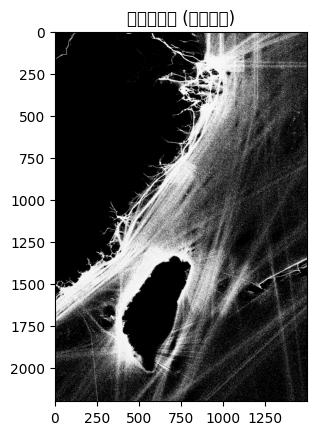

In [33]:
import rasterio
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt

tif_path = r"C:\Users\slab\Desktop\Slab Project\Stage1\data\ShipDensity_Commercial\ShipDensity_Commercial1.tif"
land_shp = r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp"
#BBOX = dict(minx=118.0, miny=21.0, maxx=125.5, maxy=32.0)
# 讀取局部海區
with rasterio.open(tif_path) as src:
    window = from_bounds(
        left=118.0, bottom=21.0, right=125.5, top=32.0,  # 台灣區域
        transform=src.transform
    )
    dens = src.read(1, window=window).astype(np.float32)
    transform = src.window_transform(window)

print("裁切後影像尺寸:", dens.shape)
plt.imshow(np.log1p(dens), cmap='gray')
plt.title("局部密度圖 (台灣區域)")
plt.show()


### 光柵化shapefile

c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38520 (\N{CJK UNIFIED IDEOGRAPH-9678}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22320 (\N{CJK UNIFIED IDEOGRAPH-5730}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21312 (\N{CJK UNIFIED IDEOGRAPH-5340}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\slab\Desktop\Slab Project\Stage2 ETA\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22495 (\N{CJK UNIFIED IDEOGRAPH-57DF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


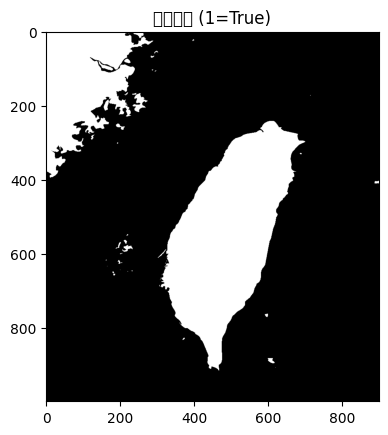

In [25]:
import geopandas as gpd
from rasterio.features import rasterize

land = gpd.read_file(land_shp).to_crs("EPSG:4326")

land_mask = rasterize(
    [(geom, 1) for geom in land.geometry],
    out_shape=dens.shape,
    transform=transform,
    fill=0,
    dtype="uint8"
).astype(bool)

plt.imshow(land_mask, cmap='gray')
plt.title("陸地區域 (1=True)")
plt.show()


### 陸地膨脹遮蔽區

In [28]:
from skimage.morphology import binary_dilation, disk
import numpy as np

# 計算像素解析度（度數 -> 公里）
lat0 = transform.f + transform.e * (dens.shape[0] / 2)
sx_km = abs(transform.e) * 111.0
sy_km = abs(transform.a) * 111.0 * np.cos(np.deg2rad(lat0))
px_per_km = max(1.0 / sx_km, 1.0 / sy_km)

buffer_km = 5.0
buf_px = max(1, int(round(buffer_km * px_per_km)))
print(f"解析度: {sx_km:.4f} km/pix, {sy_km:.4f} km/pix, 膨脹像素: {buf_px}")

coast_buffer = binary_dilation(land_mask, disk(buf_px))


解析度: 0.5550 km/pix, 0.5070 km/pix, 膨脹像素: 10


### 結合密度圖

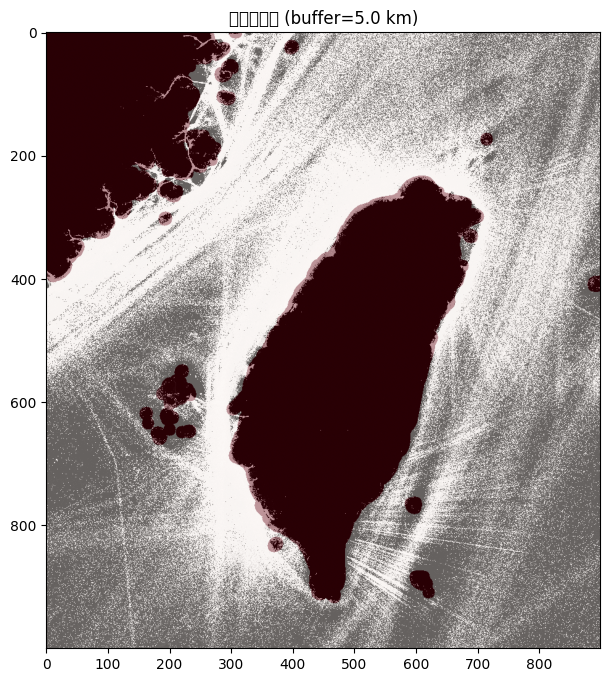

In [29]:
dens_masked = dens.copy()
dens_masked[coast_buffer] = 0

plt.figure(figsize=(10, 8))
plt.imshow(np.log1p(dens), cmap='gray')
plt.imshow(coast_buffer, cmap='Reds', alpha=0.4)
plt.title(f"膨脹遮蔽區 (buffer={buffer_km} km)")
plt.show()


### AIS密度做骨幹圖

[1/7] 讀取密度 TIF…
  影像尺寸：(6700, 3900)，CRS=EPSG:4326
[2/7] 生成陸地遮罩…
[3/7] 平滑與二值化 → skeletonize …
[4/7] 建立骨幹圖…
[5/7] 估算像素大小（公尺）並去枝…
[6/7] 圖 → 線段，輸出 GeoPackage …
  ✅ 已輸出：route_backbone_RouteB.gpkg (layer=skeleton_edges)
[7/7] 輸出預覽圖 …
  ✅ 預覽圖：route_backbone_RouteB_preview.png


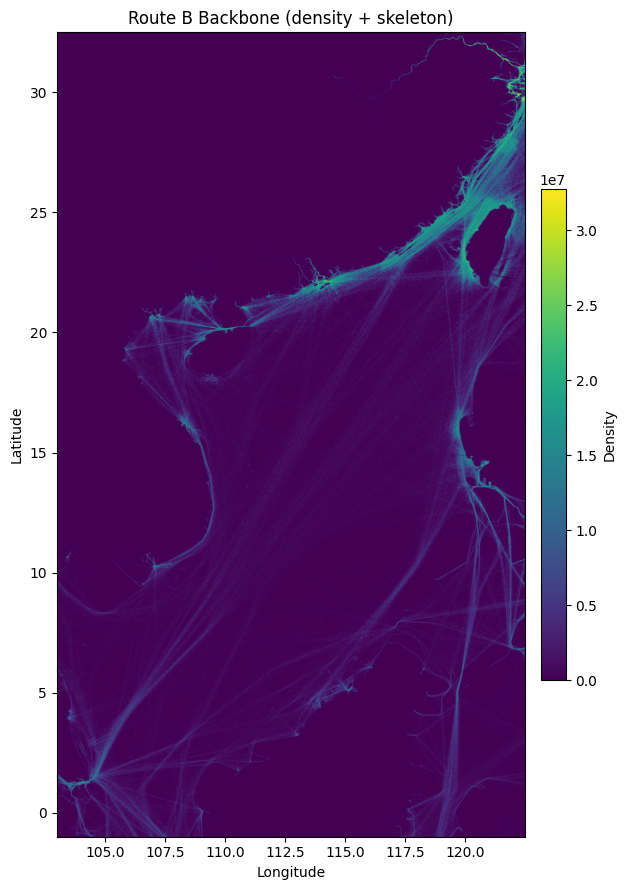

In [ ]:
"""
航道骨幹 (Route B) 產生器 — 使用商船密度 TIF + 大陸陸地遮罩
-----------------------------------------------------------------
目標：
- 以 AIS 熱點密度圖 (GeoTIFF) 作為主依據，搭配陸地矢量圖 (shapefile) 做海陸遮罩，抽取主航道骨幹。
- 產出：
  1) GeoPackage：route_backbone_RouteB.gpkg 內含 skeleton_edges (LineString, WGS84)
  2) 圖檔預覽：route_backbone_RouteB_preview.png（底圖為密度熱圖，疊合骨幹）

依賴（若缺少可安裝）：
  pip install numpy pandas geopandas shapely scikit-image networkx pyproj matplotlib rasterio

使用方式：
  1) 調整 CONFIG 區塊的輸入路徑與參數（已填入你提供的兩個路徑）。
  2) 直接執行：python route_backbone_route_b.py
  3) 若骨幹斷裂或過多雜枝，調整：binarize_method/threshold、closing_radius_px、prune_leaf_shorter_than_m。

流程概要：
  (a) 讀取密度 TIF → (b) 讀取陸地 shapefile 並轉至 TIF CRS → (c) 陸地栅格化遮罩 →
  (d) 平滑與二值化（僅保留高密度水域）→ (e) skeletonize 細化 → (f) 圖化與去枝 → (g) 輸出。
"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, List

import math
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
from pyproj import CRS, Transformer, Geod
from skimage.morphology import skeletonize, binary_closing
from skimage.filters import threshold_otsu
import networkx as nx
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize

# ----------------------------
# CONFIG：請依需求修改
# ----------------------------
@dataclass
class Config:
    # 你提供的路徑（密度 TIF + 陸地圖層）
    tif_path: Path = Path(r"C:/Users/slab/Desktop/Slab Project/Stage1/data/ShipDensity_Commercial/ShipDensity_Commercial1.tif")
    land_shp: Path = Path(r"C:/Users/slab/Desktop/Slab Project/Stage1/data/Land/ne_10m_land.shp")

    # Route B 區域（可選）：若提供會先裁切（以 TIF CRS）
    # 使用 bbox (minx, miny, maxx, maxy)。若不裁切設為 None。
    roi_bbox: Tuple[float, float, float, float] | None = (103.0, -1.0, 122.5, 32.5)  # 例： (119.9, 23.6, 121.2, 25.0)

    # 二值化與平滑
    binarize_method: str = "quantile"  # "quantile" 或 "otsu" 或 "absolute"
    binarize_quantile: float = 0.90     # 取前 10% 高密度
    absolute_threshold: float | None = None  # 若 binarize_method='absolute' 時使用
    closing_radius_px: int = 1  # morphological closing 的半徑（像素）

    # skeleton 去枝（以公尺為單位，會自動估算像素對應公尺）
    prune_leaf_shorter_than_m: float = 2000.0

    # 預覽圖最大尺寸（避免超大影像佔記憶體）
    preview_downsample_max: int = 2200

    # 輸出
    out_gpkg: Path = Path("route_backbone_RouteB.gpkg")
    out_layer: str = "skeleton_edges"
    out_preview_png: Path = Path("route_backbone_RouteB_preview.png")

CFG = Config()

# ----------------------------
# 工具函式
# ----------------------------

def read_density_and_meta(cfg: Config):
    ds = rasterio.open(cfg.tif_path)
    arr = ds.read(1).astype(float)
    transform = ds.transform
    crs = ds.crs

    if cfg.roi_bbox is not None:
        # 1) 原 AOI polygon (WGS84 假設)
        minx, miny, maxx, maxy = cfg.roi_bbox
        aoi_wgs84 = box(minx, miny, maxx, maxy)

        # 2) 投影到 3857 做公尺 buffer
        tf_w2m = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
        x1, y1 = tf_w2m.transform(minx, miny)
        x2, y2 = tf_w2m.transform(maxx, maxy)
        aoi_m = box(x1, y1, x2, y2).buffer(cfg.aoi_expand_km * 1000.0)

        # 3) 轉回 TIF CRS，取擴張後 bounds
        tf_m2r = Transformer.from_crs("EPSG:3857", crs, always_xy=True)
        xs = [aoi_m.bounds[0], aoi_m.bounds[2]]
        ys = [aoi_m.bounds[1], aoi_m.bounds[3]]
        rx1, ry1 = tf_m2r.transform(xs[0], ys[0])
        rx2, ry2 = tf_m2r.transform(xs[1], ys[1])
        expanded_bounds = (min(rx1, rx2), min(ry1, ry2), max(rx1, rx2), max(ry1, ry2))

        # 4) 用擴張 bounds 建 window 讀圖
        window = rasterio.windows.from_bounds(*expanded_bounds, transform=transform)
        arr = ds.read(1, window=window).astype(float)
        transform = ds.window_transform(window)

        # 把「原 AOI（未外擴）」也變成 TIF CRS polygon，等等用來裁回
        tf_w2r = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
        ax1, ay1 = tf_w2r.transform(minx, miny)
        ax2, ay2 = tf_w2r.transform(maxx, maxy)
        aoi_raster_crs = box(ax1, ay1, ax2, ay2)
    else:
        aoi_raster_crs = None

    return arr, transform, crs, aoi_raster_crs


def rasterize_land_mask(cfg: Config, shape, transform, raster_crs: CRS) -> np.ndarray:
    land = gpd.read_file(cfg.land_shp)
    if land.crs is None:
        land = land.set_crs(4326)
    land = land.to_crs(raster_crs)
    shapes = [(geom, 1) for geom in land.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros(shape, dtype=bool)
    land_mask = rasterize(
        shapes=shapes,
        out_shape=shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype="uint8",
    ).astype(bool)
    return land_mask


def estimate_pixel_size_m(transform, raster_crs: CRS, shape) -> float:
    """估算像素大小（公尺）。若 CRS 是投影座標（公尺），直接用；若是經緯度，換算成近似公尺。"""
    ax = abs(transform.a)
    ay = abs(transform.e)
    if raster_crs.is_projected:
        # 投影座標：像素寬高（公尺）
        return float((ax + ay) * 0.5)
    # 地理座標：以中心緯度估算 1 度對應公尺
    rows, cols = shape
    # 中心點經緯度
    cx = transform.c + ax * (cols / 2)
    cy = transform.f + ay * (rows / 2)
    geod = Geod(ellps="WGS84")
    # 經度方向每像素公尺
    lon1, lat1 = cx, cy
    lon2, lat2 = cx + ax, cy
    _, _, dist_x = geod.inv(lon1, lat1, lon2, lat2)
    # 緯度方向每像素公尺
    lon3, lat3 = cx, cy
    lon4, lat4 = cx, cy + ay
    _, _, dist_y = geod.inv(lon3, lat3, lon4, lat4)
    return float((abs(dist_x) + abs(dist_y)) * 0.5)


def close_and_binarize(arr: np.ndarray, land_mask: np.ndarray, cfg: Config) -> np.ndarray:
    # 去除 NaN/負值
    A = np.nan_to_num(arr, nan=0.0)
    A[A < 0] = 0
    # 只考慮海面：mask 掉陸地
    A[land_mask] = 0

    # 二值化
    if cfg.binarize_method == "quantile":
        pos = A[A > 0]
        thr = np.quantile(pos, cfg.binarize_quantile) if pos.size > 0 else 0
        M = (A >= thr) & (A > 0)
    elif cfg.binarize_method == "otsu":
        thr = threshold_otsu(A) if np.any(A > 0) else 0
        M = A >= thr
    elif cfg.binarize_method == "absolute":
        thr = cfg.absolute_threshold or 0
        M = A >= thr
    else:
        raise ValueError("binarize_method 僅支援 'quantile'/'otsu'/'absolute'")

    # 平滑連續化（binary closing）
    if cfg.closing_radius_px > 0:
        from skimage.morphology import disk
        se = disk(cfg.closing_radius_px)
        M = binary_closing(M, footprint=se)

    # 細化骨幹
    Sk = skeletonize(M.astype(bool))
    return Sk

# ----------------------------
# Skeleton → Graph → 去枝 → 線段
# ----------------------------

def skeleton_to_graph(Sk: np.ndarray) -> nx.Graph:
    G = nx.Graph()
    rows, cols = Sk.shape
    dirs = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    for r in range(rows):
        for c in range(cols):
            if not Sk[r, c]:
                continue
            G.add_node((r, c))
            for dr, dc in dirs:
                rr, cc = r + dr, c + dc
                if 0 <= rr < rows and 0 <= cc < cols and Sk[rr, cc]:
                    w = math.sqrt(2) if (dr != 0 and dc != 0) else 1.0
                    G.add_edge((r, c), (rr, cc), weight=w)
    return G


def prune_leaves(G: nx.Graph, pixel_size_m: float, cfg: Config) -> nx.Graph:
    """健壯版去枝：避免在刪除節點/邊後存取已不存在的節點。"""
    G = G.copy()
    if G.number_of_nodes() == 0:
        return G
    changed = True
    iters = 0
    MAX_ITERS = 200
    while changed and iters < MAX_ITERS and G.number_of_nodes() > 0:
        changed = False
        iters += 1
        # 需要拷貝，避免迭代期間被刪除
        leaves = [n for n in list(G.nodes) if n in G and G.degree[n] == 1]
        for leaf in leaves:
            if leaf not in G:
                continue
            # 由葉子往內走，量測長度（像素）
            path_len_px = 0.0
            curr = leaf
            prev = None
            while True:
                if curr not in G:
                    break
                # 安全取得鄰居
                nbrs_iter = G.neighbors(curr) if curr in G else []
                nbrs = [v for v in nbrs_iter if v != prev and v in G]
                if len(nbrs) != 1:
                    break
                nxt = nbrs[0]
                if not (curr in G and nxt in G and G.has_edge(curr, nxt)):
                    break
                path_len_px += G[curr][nxt]["weight"]
                prev, curr = curr, nxt
                if curr not in G or G.degree[curr] != 2:
                    break

            if path_len_px * pixel_size_m < cfg.prune_leaf_shorter_than_m:
                # 刪除這條葉子鏈
                curr = leaf
                prev = None
                while True:
                    if curr not in G:
                        break
                    nbrs_iter = G.neighbors(curr) if curr in G else []
                    nbrs = [v for v in nbrs_iter if v != prev and v in G]
                    if len(nbrs) == 0:
                        if curr in G:
                            G.remove_node(curr)
                            changed = True
                        break
                    if len(nbrs) > 1:
                        # 到了分叉
                        break
                    nxt = nbrs[0]
                    if curr in G and nxt in G and G.has_edge(curr, nxt):
                        G.remove_edge(curr, nxt)
                        changed = True
                    if curr in G and G.degree[curr] == 0:
                        G.remove_node(curr)
                    prev, curr = curr, nxt
    return G


def graph_to_lines(G: nx.Graph, transform, raster_crs: CRS) -> gpd.GeoDataFrame:
    # 將 (row,col) 轉為該像素中心點之地圖座標
    def rc_to_xy(r: int, c: int):
        x = transform.c + transform.a * (c + 0.5) + transform.b * (r + 0.5)
        y = transform.f + transform.d * (c + 0.5) + transform.e * (r + 0.5)
        return float(x), float(y)

    lines = []
    endpoints = [n for n in G.nodes if G.degree[n] != 2]
    visited = set()
    for u in endpoints:
        for v in list(G.neighbors(u)):
            e = tuple(sorted((u, v)))
            if e in visited:
                continue
            path = [u, v]
            visited.add(e)
            prev, curr = u, v
            while G.degree[curr] == 2:
                nbrs = [x for x in G.neighbors(curr) if x != prev]
                if not nbrs:
                    break
                nxt = nbrs[0]
                e2 = tuple(sorted((curr, nxt)))
                if e2 in visited:
                    break
                path.append(nxt)
                visited.add(e2)
                prev, curr = curr, nxt
            coords = [rc_to_xy(r, c) for (r, c) in path]
            if len(coords) >= 2:
                lines.append(LineString(coords))

    gdf = gpd.GeoDataFrame(geometry=lines, crs=raster_crs)
    # 統一輸出到 WGS84
    gdf = gdf.to_crs(4326)
    return gdf

# ----------------------------
# 主流程
# ----------------------------

def main(cfg: Config = CFG):
    print("[1/7] 讀取密度 TIF…")
    arr, transform, raster_crs = read_density_and_meta(cfg)
    print(f"  影像尺寸：{arr.shape}，CRS={raster_crs.to_string()}")

    print("[2/7] 生成陸地遮罩…")
    land_mask = rasterize_land_mask(cfg, arr.shape, transform, raster_crs)

    print("[3/7] 平滑與二值化 → skeletonize …")
    Sk = close_and_binarize(arr, land_mask, cfg)

    print("[4/7] 建立骨幹圖…")
    G = skeleton_to_graph(Sk)

    print("[5/7] 估算像素大小（公尺）並去枝…")
    pixel_m = estimate_pixel_size_m(transform, raster_crs, arr.shape)
    Gp = prune_leaves(G, pixel_m, cfg)

    print("[6/7] 圖 → 線段，輸出 GeoPackage …")
    lines = graph_to_lines(Gp, transform, raster_crs)
    if not lines.empty:
        lines.to_file(cfg.out_gpkg, layer=cfg.out_layer, driver="GPKG")
        print(f"  已輸出：{cfg.out_gpkg} (layer={cfg.out_layer})")
    else:
        print("  [注意] 無線段輸出，請調整閾值/平滑/去枝參數。")

    print("[7/7] 輸出預覽圖 …")
    # 為避免超大圖，必要時下採樣預覽
    A = np.nan_to_num(arr, nan=0.0)
    r, c = A.shape
    scale = 1.0
    if max(r, c) > cfg.preview_downsample_max:
        scale = cfg.preview_downsample_max / max(r, c)
        from skimage.transform import resize
        A_disp = resize(A, (int(r * scale), int(c * scale)), anti_aliasing=True, preserve_range=True)
        Sk_disp = resize(Sk.astype(float), (int(r * scale), int(c * scale)), order=0, preserve_range=True) > 0.5
        # 近似的仿射縮放（僅用於畫圖範圍，非精確座標）
        tx = rasterio.Affine(transform.a/scale, transform.b, transform.c, transform.d, transform.e/scale, transform.f)
        extent = [tx.c, tx.c + tx.a * A_disp.shape[1], tx.f + tx.e * A_disp.shape[0], tx.f]
    else:
        A_disp, Sk_disp = A, Sk
        extent = [transform.c, transform.c + transform.a * c, transform.f + transform.e * r, transform.f]

    fig, ax = plt.subplots(figsize=(9, 9))
    im = ax.imshow(A_disp, origin="upper", extent=extent)
    ax.imshow(np.where(Sk_disp, np.nanmax(A_disp), np.nan), origin="upper", extent=extent, alpha=0.6)
    ax.set_title("Route B Backbone (density + skeleton)")
    ax.set_xlabel(raster_crs.axis_info[0].name if raster_crs.is_projected else "Longitude")
    ax.set_ylabel(raster_crs.axis_info[1].name if raster_crs.is_projected else "Latitude")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Density")
    plt.tight_layout()
    fig.savefig(cfg.out_preview_png, dpi=180)
    print(f"  ✅ 預覽圖：{cfg.out_preview_png}")


if __name__ == "__main__":
    main()


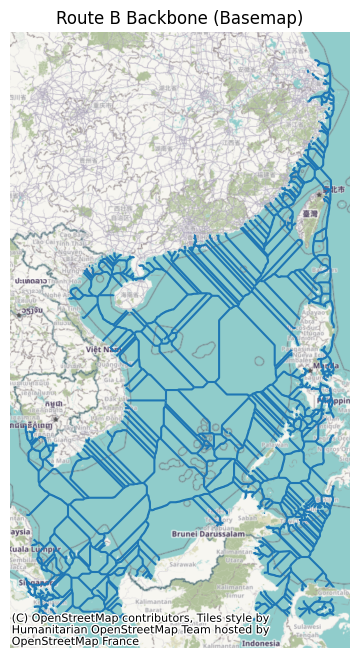

In [11]:
# pip install contextily
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

gdf = gpd.read_file(path, layer="skeleton_edges").to_crs(3857)  # Web Mercator

ax = gdf.plot(figsize=(10,8), linewidth=1.5)
cx.add_basemap(ax, crs=gdf.crs)  # 加底圖
ax.set_title("Route B Backbone (Basemap)")
ax.set_axis_off()
plt.show()


### 直接做航道骨幹圖

[1/7] 讀取密度 TIF…
  影像尺寸：(7524, 4798)，CRS=EPSG:4326
[2/7] 生成陸地遮罩…
[3/7] 由海洋遮罩生成骨架（不使用密度值）…
[4/7] 建立骨幹圖…
[5/7] 估算像素大小（公尺）並去枝…
[6/7] 圖 → 線段，輸出 GeoPackage …
  已輸出：route_backbone_RouteB.gpkg (layer=skeleton_edges)
[7/7] 輸出預覽圖 …
  ✅ 預覽圖：route_backbone_RouteB_preview.png


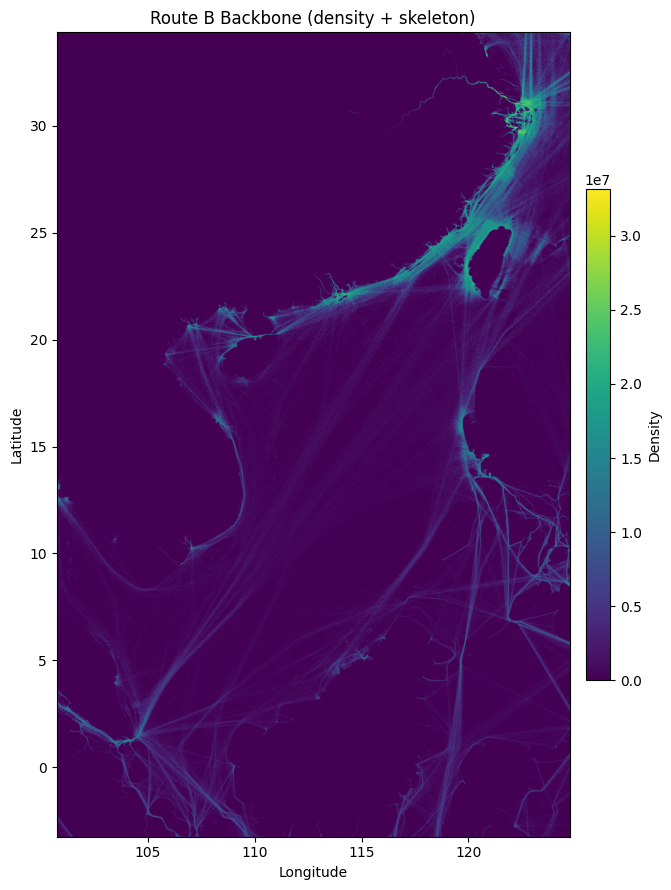

In [ ]:
"""
航道骨幹 (Route B) 產生器 — 使用商船密度 TIF + 大陸陸地遮罩
-----------------------------------------------------------------
目標：
- 以 AIS 熱點密度圖 (GeoTIFF) 作為主依據，搭配陸地矢量圖 (shapefile) 做海陸遮罩，抽取主航道骨幹。
- 產出：
  1) GeoPackage：route_backbone_RouteB.gpkg 內含 skeleton_edges (LineString, WGS84)
  2) 圖檔預覽：route_backbone_RouteB_preview.png（底圖為密度熱圖，疊合骨幹）

依賴（若缺少可安裝）：
  pip install numpy pandas geopandas shapely scikit-image networkx pyproj matplotlib rasterio

使用方式：
  1) 調整 CONFIG 區塊的輸入路徑與參數（已填入你提供的兩個路徑）。
  2) 直接執行：python route_backbone_route_b.py
  3) 若骨幹斷裂或過多雜枝，調整：binarize_method/threshold、closing_radius_px、prune_leaf_shorter_than_m。

流程概要：
  (a) 讀取密度 TIF → (b) 讀取陸地 shapefile 並轉至 TIF CRS → (c) 陸地栅格化遮罩 →
  (d) 平滑與二值化（僅保留高密度水域）→ (e) skeletonize 細化 → (f) 圖化與去枝 → (g) 輸出。
"""
from __future__ import annotations
from shapely.geometry import box
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, List

import math
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
from pyproj import CRS, Transformer, Geod
from skimage.morphology import skeletonize, binary_closing
from skimage.filters import threshold_otsu
import networkx as nx
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize

# ----------------------------
# CONFIG：請依需求修改
# ----------------------------
@dataclass
class Config:
    # 你提供的路徑（密度 TIF + 陸地圖層）
    tif_path: Path = Path(r"C:/Users/slab/Desktop/Slab Project/Stage1/data/ShipDensity_Commercial/ShipDensity_Commercial1.tif")
    land_shp: Path = Path(r"C:/Users/slab/Desktop/Slab Project/Stage1/data/Land/ne_10m_land.shp")

    # Route B 區域（可選）：若提供會先裁切（以 TIF CRS）
    # 使用 bbox (minx, miny, maxx, maxy)。若不裁切設為 None。
    roi_bbox: Tuple[float, float, float, float] | None = (103.0, -1.0, 122.5, 32.5)  # 例： (119.9, 23.6, 121.2, 25.0)

    # 二值化與平滑
    binarize_method: str = "quantile"  # "quantile" 或 "otsu" 或 "absolute"
    binarize_quantile: float = 0.90     # 取前 10% 高密度
    absolute_threshold: float | None = None  # 若 binarize_method='absolute' 時使用
    closing_radius_px: int = 1  # morphological closing 的半徑（像素）

    # skeleton 去枝（以公尺為單位，會自動估算像素對應公尺）
    prune_leaf_shorter_than_m: float = 2000.0
    # 避免外框影響設置的範圍增幅
    aoi_expand_km: float = 250.0  # 先試 250km；200~300km 都可

    # 預覽圖最大尺寸（避免超大影像佔記憶體）
    preview_downsample_max: int = 2200

    # 輸出
    out_gpkg: Path = Path("route_backbone_RouteB.gpkg")
    out_layer: str = "skeleton_edges"
    out_preview_png: Path = Path("route_backbone_RouteB_preview.png")

CFG = Config()

# ----------------------------
# 工具函式
# ----------------------------

def read_density_and_meta(cfg: Config):
    ds = rasterio.open(cfg.tif_path)
    arr = ds.read(1).astype(float)
    transform = ds.transform
    crs = ds.crs

    if cfg.roi_bbox is not None:
        # 1) 原 AOI polygon (WGS84 假設)
        minx, miny, maxx, maxy = cfg.roi_bbox
        aoi_wgs84 = box(minx, miny, maxx, maxy)

        # 2) 投影到 3857 做公尺 buffer
        tf_w2m = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
        x1, y1 = tf_w2m.transform(minx, miny)
        x2, y2 = tf_w2m.transform(maxx, maxy)
        aoi_m = box(x1, y1, x2, y2).buffer(cfg.aoi_expand_km * 1000.0)

        # 3) 轉回 TIF CRS，取擴張後 bounds
        tf_m2r = Transformer.from_crs("EPSG:3857", crs, always_xy=True)
        xs = [aoi_m.bounds[0], aoi_m.bounds[2]]
        ys = [aoi_m.bounds[1], aoi_m.bounds[3]]
        rx1, ry1 = tf_m2r.transform(xs[0], ys[0])
        rx2, ry2 = tf_m2r.transform(xs[1], ys[1])
        expanded_bounds = (min(rx1, rx2), min(ry1, ry2), max(rx1, rx2), max(ry1, ry2))

        # 4) 用擴張 bounds 建 window 讀圖
        window = rasterio.windows.from_bounds(*expanded_bounds, transform=transform)
        arr = ds.read(1, window=window).astype(float)
        transform = ds.window_transform(window)

        # 把「原 AOI（未外擴）」也變成 TIF CRS polygon，等等用來裁回
        tf_w2r = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
        ax1, ay1 = tf_w2r.transform(minx, miny)
        ax2, ay2 = tf_w2r.transform(maxx, maxy)
        aoi_raster_crs = box(ax1, ay1, ax2, ay2)
    else:
        aoi_raster_crs = None

    return arr, transform, crs, aoi_raster_crs


def rasterize_land_mask(cfg: Config, shape, transform, raster_crs: CRS) -> np.ndarray:
    """以 *公尺* 緩衝後的陸地面轉成遮罩（True=陸地）。
    流程：land(WGS84/原CRS)→投影(EPSG:3857)做 buffer(m)→轉回 raster_crs → rasterize。
    """
    land = gpd.read_file(cfg.land_shp)
    # 若沒有 CRS，假設為 WGS84
    if land.crs is None:
        land = land.set_crs(4326)
    # 先投影到 Web Mercator 以便用「公尺」緩衝
    land_m = land.to_crs(3857)
    # 小島過濾（可選）：面積 < 1e6 m² (~1 km²) 的小島先忽略，減少毛邊骨架
    # 如要保留全部小島，將下一行註解掉
    # land_m = land_m[land_m.area > 1e6]
    # 近岸緩衝（預設 5 km）
    buffer_m = 5000.0
    land_m = land_m.buffer(buffer_m)
    land_m = gpd.GeoSeries(land_m, crs=3857).to_frame("geometry")
    # 轉回 raster_crs 再 rasterize
    land_r = land_m.to_crs(raster_crs)
    shapes = [(geom, 1) for geom in land_r.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros(shape, dtype=bool)
    land_mask = rasterize(
        shapes=shapes,
        out_shape=shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype="uint8",
    ).astype(bool)
    return land_mask
    land = gpd.read_file(cfg.land_shp)
    if land.crs is None:
        land = land.set_crs(4326)
    land = land.to_crs(raster_crs)
    shapes = [(geom, 1) for geom in land.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros(shape, dtype=bool)
    land_mask = rasterize(
        shapes=shapes,
        out_shape=shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype="uint8",
    ).astype(bool)
    return land_mask


def estimate_pixel_size_m(transform, raster_crs: CRS, shape) -> float:
    """估算像素大小（公尺）。若 CRS 是投影座標（公尺），直接用；若是經緯度，換算成近似公尺。"""
    ax = abs(transform.a)
    ay = abs(transform.e)
    if raster_crs.is_projected:
        # 投影座標：像素寬高（公尺）
        return float((ax + ay) * 0.5)
    # 地理座標：以中心緯度估算 1 度對應公尺
    rows, cols = shape
    # 中心點經緯度
    cx = transform.c + ax * (cols / 2)
    cy = transform.f + ay * (rows / 2)
    geod = Geod(ellps="WGS84")
    # 經度方向每像素公尺
    lon1, lat1 = cx, cy
    lon2, lat2 = cx + ax, cy
    _, _, dist_x = geod.inv(lon1, lat1, lon2, lat2)
    # 緯度方向每像素公尺
    lon3, lat3 = cx, cy
    lon4, lat4 = cx, cy + ay
    _, _, dist_y = geod.inv(lon3, lat3, lon4, lat4)
    return float((abs(dist_x) + abs(dist_y)) * 0.5)


def close_and_binarize(arr: np.ndarray, land_mask: np.ndarray, cfg: Config) -> np.ndarray:
    """
    依照「地理骨幹」策略：**完全忽略密度值**；僅使用海洋遮罩造骨架。
    - 海洋=1, 陸地=0
    - 可選：做少量 closing 以連續化海面走廊
    - 回傳 skeleton 布林陣列
    """
    # 海洋可通行區（True=海）
    M = ~land_mask
    # 輕度形態平滑以連續化狹窄通道
    if cfg.closing_radius_px > 0:
        from skimage.morphology import disk
        se = disk(cfg.closing_radius_px)
        M = binary_closing(M.astype(bool), footprint=se)
    # 抽骨架
    Sk = skeletonize(M.astype(bool))
    return Sk
    # 去除 NaN/負值
    A = np.nan_to_num(arr, nan=0.0)
    A[A < 0] = 0
    # 只考慮海面：mask 掉陸地
    A[land_mask] = 0

    # 二值化
    if cfg.binarize_method == "quantile":
        pos = A[A > 0]
        thr = np.quantile(pos, cfg.binarize_quantile) if pos.size > 0 else 0
        M = (A >= thr) & (A > 0)
    elif cfg.binarize_method == "otsu":
        thr = threshold_otsu(A) if np.any(A > 0) else 0
        M = A >= thr
    elif cfg.binarize_method == "absolute":
        thr = cfg.absolute_threshold or 0
        M = A >= thr
    else:
        raise ValueError("binarize_method 僅支援 'quantile'/'otsu'/'absolute'")

    # 平滑連續化（binary closing）
    if cfg.closing_radius_px > 0:
        from skimage.morphology import disk
        se = disk(cfg.closing_radius_px)
        M = binary_closing(M, footprint=se)

    # 細化骨幹
    Sk = skeletonize(M.astype(bool))
    return Sk

# ----------------------------
# Skeleton → Graph → 去枝 → 線段
# ----------------------------

def skeleton_to_graph(Sk: np.ndarray) -> nx.Graph:
    G = nx.Graph()
    rows, cols = Sk.shape
    dirs = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    for r in range(rows):
        for c in range(cols):
            if not Sk[r, c]:
                continue
            G.add_node((r, c))
            for dr, dc in dirs:
                rr, cc = r + dr, c + dc
                if 0 <= rr < rows and 0 <= cc < cols and Sk[rr, cc]:
                    w = math.sqrt(2) if (dr != 0 and dc != 0) else 1.0
                    G.add_edge((r, c), (rr, cc), weight=w)
    return G

from skimage.filters import gaussian

def compute_preference_from_density(arr: np.ndarray,
                                    dist_px: np.ndarray,
                                    pixel_m: float,
                                    cfg: Config) -> np.ndarray:
    """
    將原始密度 arr 轉成偏好場 P ∈ [0,1]：
    log1p → 百分位標準化 → 高斯模糊(以 km → px) → 0-1 → sigmoid →
    近岸衰減（用 dist_px）→ 上限截斷
    """
    A = np.nan_to_num(arr, nan=0.0)
    # log 壓亮
    A1 = np.log1p(np.maximum(A, 0.0))

    # 取有效值（>0）做百分位標準化
    pos = A1[A1 > 0]
    if pos.size > 50:
        lo = np.percentile(pos, cfg.pref_pmin)
        hi = np.percentile(pos, cfg.pref_pmax)
        if hi <= lo:  # 退化保護
            lo, hi = np.percentile(pos, 70), np.percentile(pos, 99)
    else:
        lo, hi = A1.min(), A1.max()

    # 標準化到 [0,1]
    N = (A1 - lo) / (max(hi - lo, 1e-9))
    N = np.clip(N, 0.0, 1.0)

    # 高斯模糊（sigma：km → px）
    sigma_px = max((cfg.pref_sigma_km * 1000.0) / max(pixel_m, 1e-6), 1.0)
    N_blur = gaussian(N, sigma=sigma_px, preserve_range=True)

    # sigmoid 提升高值、抑制低值
    X = N_blur - cfg.pref_tau
    P = 1.0 / (1.0 + np.exp(-cfg.pref_k * X))  # >tau 才會快速上升

    # 近岸衰減：dist < r0 的像素把偏好縮小
    if dist_px is not None:
        dist_km = (dist_px * pixel_m) / 1000.0
        r0 = cfg.pref_nearshore_km
        scale = np.where(dist_km < r0, cfg.pref_nearshore_scale, 1.0)
        P = P * scale

    # 上限截斷，避免極端值支配
    P = np.clip(P, 0.0, 0.95)
    return P


def attach_preference_to_edges(G: nx.Graph,
                               P: np.ndarray) -> nx.Graph:
    """
    對每條邊取端點+中點的偏好平均，寫入 edge['pref_edge'] ∈ [0,1]
    """
    rows, cols = P.shape

    def clip_rc(r, c):
        r2 = int(min(max(r, 0), rows - 1))
        c2 = int(min(max(c, 0), cols - 1))
        return r2, c2

    for u, v, data in G.edges(data=True):
        (r1, c1), (r2, c2) = u, v
        rm, cm = int(round((r1 + r2) * 0.5)), int(round((c1 + c2) * 0.5))
        r1, c1 = clip_rc(r1, c1)
        r2, c2 = clip_rc(r2, c2)
        rm, cm = clip_rc(rm, cm)
        p_edge = float((P[r1, c1] + P[r2, c2] + P[rm, cm]) / 3.0)
        data["pref_edge"] = p_edge
    return G

def prune_leaves(G: nx.Graph, pixel_size_m: float, cfg: Config) -> nx.Graph:
    """健壯版去枝：避免在刪除節點/邊後存取已不存在的節點。"""
    G = G.copy()
    if G.number_of_nodes() == 0:
        return G
    changed = True
    iters = 0
    MAX_ITERS = 200
    while changed and iters < MAX_ITERS and G.number_of_nodes() > 0:
        changed = False
        iters += 1
        # 需要拷貝，避免迭代期間被刪除
        leaves = [n for n in list(G.nodes) if n in G and G.degree[n] == 1]
        for leaf in leaves:
            if leaf not in G:
                continue
            # 由葉子往內走，量測長度（像素）
            path_len_px = 0.0
            curr = leaf
            prev = None
            while True:
                if curr not in G:
                    break
                # 安全取得鄰居
                nbrs_iter = G.neighbors(curr) if curr in G else []
                nbrs = [v for v in nbrs_iter if v != prev and v in G]
                if len(nbrs) != 1:
                    break
                nxt = nbrs[0]
                if not (curr in G and nxt in G and G.has_edge(curr, nxt)):
                    break
                path_len_px += G[curr][nxt]["weight"]
                prev, curr = curr, nxt
                if curr not in G or G.degree[curr] != 2:
                    break

            if path_len_px * pixel_size_m < cfg.prune_leaf_shorter_than_m:
                # 刪除這條葉子鏈
                curr = leaf
                prev = None
                while True:
                    if curr not in G:
                        break
                    nbrs_iter = G.neighbors(curr) if curr in G else []
                    nbrs = [v for v in nbrs_iter if v != prev and v in G]
                    if len(nbrs) == 0:
                        if curr in G:
                            G.remove_node(curr)
                            changed = True
                        break
                    if len(nbrs) > 1:
                        # 到了分叉
                        break
                    nxt = nbrs[0]
                    if curr in G and nxt in G and G.has_edge(curr, nxt):
                        G.remove_edge(curr, nxt)
                        changed = True
                    if curr in G and G.degree[curr] == 0:
                        G.remove_node(curr)
                    prev, curr = curr, nxt
    return G


def graph_to_lines(G: nx.Graph, transform, raster_crs: CRS) -> gpd.GeoDataFrame:
    # 將 (row,col) 轉為該像素中心點之地圖座標
    def rc_to_xy(r: int, c: int):
        x = transform.c + transform.a * (c + 0.5) + transform.b * (r + 0.5)
        y = transform.f + transform.d * (c + 0.5) + transform.e * (r + 0.5)
        return float(x), float(y)

    lines = []
    endpoints = [n for n in G.nodes if G.degree[n] != 2]
    visited = set()
    for u in endpoints:
        for v in list(G.neighbors(u)):
            e = tuple(sorted((u, v)))
            if e in visited:
                continue
            path = [u, v]
            visited.add(e)
            prev, curr = u, v
            while G.degree[curr] == 2:
                nbrs = [x for x in G.neighbors(curr) if x != prev]
                if not nbrs:
                    break
                nxt = nbrs[0]
                e2 = tuple(sorted((curr, nxt)))
                if e2 in visited:
                    break
                path.append(nxt)
                visited.add(e2)
                prev, curr = curr, nxt
            coords = [rc_to_xy(r, c) for (r, c) in path]
            if len(coords) >= 2:
                lines.append(LineString(coords))

    gdf = gpd.GeoDataFrame(geometry=lines, crs=raster_crs)
    # 統一輸出到 WGS84
    gdf = gdf.to_crs(4326)
    return gdf

# ----------------------------
# 主流程
# ----------------------------

def main(cfg: Config = CFG):
    print("[1/7] 讀取密度 TIF…")
    #arr, transform, raster_crs = read_density_and_meta(cfg)
    arr, transform, raster_crs, aoi_raster_crs = read_density_and_meta(cfg)
    print(f"  影像尺寸：{arr.shape}，CRS={raster_crs.to_string()}")

    print("[2/7] 生成陸地遮罩…")
    land_mask = rasterize_land_mask(cfg, arr.shape, transform, raster_crs)

    print("[3/7] 由海洋遮罩生成骨架（不使用密度值）…")
    Sk = close_and_binarize(arr, land_mask, cfg)

    print("[4/7] 建立骨幹圖…")
    G = skeleton_to_graph(Sk)

    print("[5/7] 估算像素大小（公尺）並去枝…")
    pixel_m = estimate_pixel_size_m(transform, raster_crs, arr.shape)
    Gp = prune_leaves(G, pixel_m, cfg)

    print("[6/7] 圖 → 線段，輸出 GeoPackage …")
    lines = graph_to_lines(Gp, transform, raster_crs)

    if 'aoi_raster_crs' in locals() and aoi_raster_crs is not None and not lines.empty:
        aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_raster_crs], crs=raster_crs).to_crs(4326)
        try:
            # geopandas 0.10+ 推薦用 clip
            lines = lines.clip(aoi_gdf)
        except Exception:
            # 萬一你的版本沒有 clip，就用 overlay 當後備
            lines = gpd.overlay(lines, aoi_gdf, how="intersection")

    if not lines.empty:
        lines.to_file(cfg.out_gpkg, layer=cfg.out_layer, driver="GPKG")
        print(f"  已輸出：{cfg.out_gpkg} (layer={cfg.out_layer})")
    else:
        print("  [注意] 無線段輸出，請調整閾值/平滑/去枝參數。")

    print("[7/7] 輸出預覽圖 …")
    # 為避免超大圖，必要時下採樣預覽
    A = np.nan_to_num(arr, nan=0.0)
    r, c = A.shape
    scale = 1.0
    if max(r, c) > cfg.preview_downsample_max:
        scale = cfg.preview_downsample_max / max(r, c)
        from skimage.transform import resize
        A_disp = resize(A, (int(r * scale), int(c * scale)), anti_aliasing=True, preserve_range=True)
        Sk_disp = resize(Sk.astype(float), (int(r * scale), int(c * scale)), order=0, preserve_range=True) > 0.5
        # 近似的仿射縮放（僅用於畫圖範圍，非精確座標）
        tx = rasterio.Affine(transform.a/scale, transform.b, transform.c, transform.d, transform.e/scale, transform.f)
        extent = [tx.c, tx.c + tx.a * A_disp.shape[1], tx.f + tx.e * A_disp.shape[0], tx.f]
    else:
        A_disp, Sk_disp = A, Sk
        extent = [transform.c, transform.c + transform.a * c, transform.f + transform.e * r, transform.f]

    fig, ax = plt.subplots(figsize=(9, 9))
    im = ax.imshow(A_disp, origin="upper", extent=extent)
    ax.imshow(np.where(Sk_disp, np.nanmax(A_disp), np.nan), origin="upper", extent=extent, alpha=0.6)
    ax.set_title("Route B Backbone (density + skeleton)")
    ax.set_xlabel(raster_crs.axis_info[0].name if raster_crs.is_projected else "Longitude")
    ax.set_ylabel(raster_crs.axis_info[1].name if raster_crs.is_projected else "Latitude")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Density")
    plt.tight_layout()
    fig.savefig(cfg.out_preview_png, dpi=180)
    print(f"  ✅ 預覽圖：{cfg.out_preview_png}")


if __name__ == "__main__":
    main()


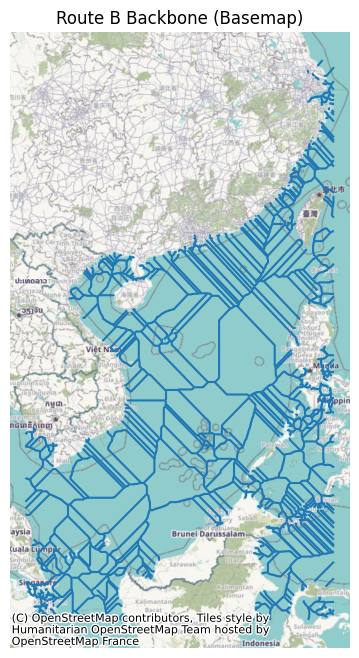

In [14]:
# pip install contextily
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

gdf = gpd.read_file(path, layer="skeleton_edges").to_crs(3857)  # Web Mercator

ax = gdf.plot(figsize=(10,8), linewidth=1.5)
cx.add_basemap(ax, crs=gdf.crs)  # 加底圖
ax.set_title("Route B Backbone (Basemap)")
ax.set_axis_off()
plt.show()

### 加入權重函數

[1/8] 讀取影像（含 AOI 外擴）…
  影像尺寸：(7524, 4798)，CRS=EPSG:4326
[2/8] 生成陸地遮罩（5 km 緩衝）…
[3/8] 海洋遮罩 → 骨架 + 距離場（像素）…
[4/8] 建立骨幹圖並去枝 …
[5/8] 寫入距離屬性，並以 D_min 過濾貼岸邊 …
[6/8] 圖 → 線段（骨幹）並裁回原 AOI …
[7/8] A* 規劃：新加坡 → 高雄 …
[8/8] 寫入 GeoPackage 並輸出預覽 …
   骨幹輸出：route_backbone_RouteB.gpkg (layer=skeleton_edges)
   路徑輸出：route_backbone_RouteB.gpkg (layer=route_sin_to_ks)
  路徑總長：3498.8 km | 離岸距離：min 2.7 / avg 205.8 km
  起點距骨幹：1.57 km | 終點距骨幹：14.68 km
   預覽圖：route_backbone_RouteB_preview.png


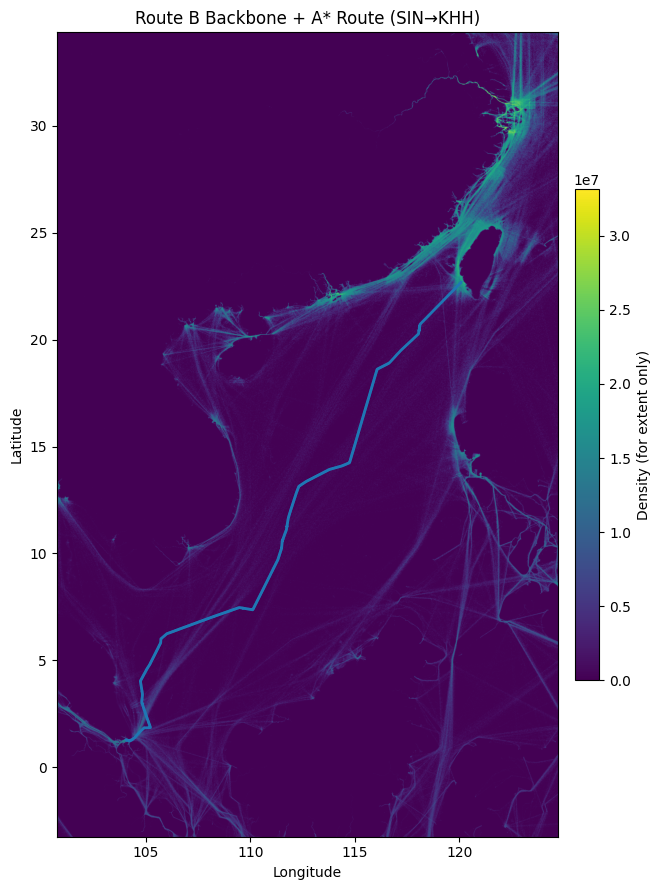

In [21]:
"""
航道骨幹 (Route B) 產生器 — 使用商船密度 TIF + 大陸陸地遮罩
-----------------------------------------------------------------
目標：
- 以 AIS 熱點密度圖 (GeoTIFF) 作為主依據，搭配陸地矢量圖 (shapefile) 做海陸遮罩，抽取主航道骨幹。
- 產出：
  1) GeoPackage：route_backbone_RouteB.gpkg 內含 skeleton_edges (LineString, WGS84)
  2) 圖檔預覽：route_backbone_RouteB_preview.png（底圖為密度熱圖，疊合骨幹）

依賴（若缺少可安裝）：
  pip install numpy pandas geopandas shapely scikit-image networkx pyproj matplotlib rasterio

使用方式：
  1) 調整 CONFIG 區塊的輸入路徑與參數（已填入你提供的兩個路徑）。
  2) 直接執行：python route_backbone_route_b.py
  3) 若骨幹斷裂或過多雜枝，調整：binarize_method/threshold、closing_radius_px、prune_leaf_shorter_than_m。

流程概要：
  (a) 讀取密度 TIF → (b) 讀取陸地 shapefile 並轉至 TIF CRS → (c) 陸地栅格化遮罩 →
  (d) 平滑與二值化（僅保留高密度水域）→ (e) skeletonize 細化 → (f) 圖化與去枝 → (g) 輸出。
"""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, List

import math
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString, box
from pyproj import CRS, Transformer, Geod
from skimage.morphology import binary_closing, medial_axis, disk
import networkx as nx
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from skimage.filters import gaussian

# ----------------------------
# CONFIG：請依需求修改
# ----------------------------
@dataclass
class Config:
    # 你提供的路徑（密度 TIF + 陸地圖層）
    tif_path: Path = Path(r"C:/Users/slab/Desktop/Slab Project/Stage1/data/ShipDensity_Commercial/ShipDensity_Commercial1.tif")
    land_shp: Path = Path(r"C:/Users/slab/Desktop/Slab Project/Stage1/data/Land/ne_10m_land.shp")

    # AOI（WGS84）與外擴距離（km）
    roi_bbox: Tuple[float, float, float, float] | None = (103.0, -1.0, 122.5, 32.5)
    aoi_expand_km: float = 250.0

    # 端點（WGS84）— 新加坡外海門點 / 高雄外海門點（略離岸，避免落在緩衝內）
    start_wgs84: Tuple[float, float] = (104.02, 1.25)   # (lon, lat)
    goal_wgs84: Tuple[float, float] = (120.18, 22.55)   # (lon, lat)

    # 形態平滑與去枝
    closing_radius_px: int = 3
    prune_leaf_shorter_than_m: float = 6000.0  # L_min
    dmin_to_land_m: float = 2500.0             # D_min（若<=0則停用）

    # 規劃權重（A*）
    alpha: float = 1.0  # 距離權重
    beta: float = 3.0   # 1/DistToLand 權重
    gamma: float = 0.0  # 轉角懲罰（暫不啟用）
    delta: float = 0.0  # 地區性懲罰（暫不啟用）

    # 預覽圖最大尺寸
    preview_downsample_max: int = 2200

    # 輸出
    out_gpkg: Path = Path("route_backbone_RouteB.gpkg")
    out_layer: str = "skeleton_edges"
    out_route_layer: str = "route_sin_to_ks"
    out_preview_png: Path = Path("route_backbone_RouteB_preview.png")

    # AIS parameters
    lambda_density: float = 2.5      # λ：AIS 偏好權重（起手 2.0，可在 1.5–2.5 之間微調）
    pref_sigma_km: float = 30.0      # 高斯模糊的空間尺度（km）
    pref_pmin: float = 80.0          # 百分位下界，用來做局部強度標準化
    pref_pmax: float = 99.0          # 百分位上界
    pref_tau: float = 0.55           # 偏好啟動門檻（>tau 才開始有明顯影響）
    pref_k: float = 8.0              # Sigmoid 陡度
    pref_nearshore_km: float = 3.0   # 近岸衰減半徑（km；<這個距離的偏好會被縮小）
    pref_nearshore_scale: float = 0.2 # 近岸縮放係數（0.2 = 僅保留 20% 偏好）

CFG = Config()

# ----------------------------
# 幾何/網路工具（A* 與距離）
# ----------------------------
import heapq

def great_circle_km(lonlat1, lonlat2):
    geod = Geod(ellps="WGS84")
    lon1, lat1 = lonlat1
    lon2, lat2 = lonlat2
    _, _, d = geod.inv(lon1, lat1, lon2, lat2)
    return d / 1000.0


def build_graph_with_dist(G: nx.Graph, transform, raster_crs: CRS, dist_img: np.ndarray, pixel_m: float) -> nx.Graph:
    """將距離到陸地資訊寫入節點/邊屬性，並加上地理長度（km）。"""
    tf_r2w = Transformer.from_crs(raster_crs, 4326, always_xy=True)

    def rc_to_xy(r: int, c: int) -> Tuple[float, float]:
        x = transform.c + transform.a * (c + 0.5) + transform.b * (r + 0.5)
        y = transform.f + transform.d * (c + 0.5) + transform.e * (r + 0.5)
        return float(x), float(y)

    for n in G.nodes:
        r, c = n
        d_m = float(dist_img[r, c] * pixel_m)
        x, y = rc_to_xy(r, c)
        lon, lat = tf_r2w.transform(x, y)
        G.nodes[n]["dist_to_land_m"] = d_m
        G.nodes[n]["lonlat"] = (lon, lat)

    for u, v, data in G.edges(data=True):
        lonlat_u = G.nodes[u]["lonlat"]
        lonlat_v = G.nodes[v]["lonlat"]
        data["length_km"] = great_circle_km(lonlat_u, lonlat_v)
        dmin = min(G.nodes[u]["dist_to_land_m"], G.nodes[v]["dist_to_land_m"]) / 1000.0
        data["dist_to_land_km"] = dmin
    return G


def snap_point_to_graph(G: nx.Graph, pt_lonlat: Tuple[float, float]) -> Tuple[Tuple[int,int], float]:
    """回傳距離最近的節點與距離（km）。"""
    min_d = float("inf")
    min_n = None
    for n in G.nodes:
        lon, lat = G.nodes[n]["lonlat"]
        d = great_circle_km(pt_lonlat, (lon, lat))
        if d < min_d:
            min_d = d
            min_n = n
    return min_n, min_d


def astar_route(G: nx.Graph, s_node, t_node, cfg: Config):
    
    alpha, beta, lam = cfg.alpha, cfg.beta, cfg.lambda_density
    tau = cfg.pref_tau

    def h(n):  # 啟發式：大圓距離 × α
        return alpha * great_circle_km(G.nodes[n]["lonlat"], G.nodes[t_node]["lonlat"])

    openq = []
    heapq.heappush(openq, (h(s_node), 0.0, s_node))  # (f, g, node)
    best_g = {s_node: 0.0}
    parent = {s_node: None}

    while openq:
        f, g, u = heapq.heappop(openq)
        if u == t_node:
            break
        if g > best_g.get(u, float("inf")):
            continue
        for v, data in G[u].items():
            base = alpha * data.get("length_km", 0.0)
            d2l = data.get("dist_to_land_km", 1e-3)
            inv_d = beta * (1.0 / max(d2l, 1e-3))
            # 偏好項：只有當 pref_edge >= tau 才啟用；偏好越高，額外代價越小
            p = float(data.get("pref_edge", 0.0))
            extra = lam * (1.0 - p) if p >= tau else 0.0

            g2 = g + base + inv_d + extra
            if g2 < best_g.get(v, float("inf")):
                best_g[v] = g2
                parent[v] = u
                heapq.heappush(openq, (g2 + h(v), g2, v))

    if t_node not in parent:
        return []
    # 回溯
    path, cur = [], t_node
    while cur is not None:
        path.append(cur)
        cur = parent.get(cur)
    return list(reversed(path))

# ----------------------------
# 影像/遮罩/骨架/圖論 相關工具
# ----------------------------

def read_density_and_meta(cfg: Config):
    ds = rasterio.open(cfg.tif_path)
    arr = ds.read(1).astype(float)
    transform = ds.transform
    crs = ds.crs
    aoi_raster_crs = None

    if cfg.roi_bbox is not None:
        # 原 AOI（WGS84）→ 3857 外擴 → 轉回 TIF CRS 做 window 讀圖
        minx, miny, maxx, maxy = cfg.roi_bbox
        tf_w2m = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
        x1, y1 = tf_w2m.transform(minx, miny)
        x2, y2 = tf_w2m.transform(maxx, maxy)
        aoi_m = box(x1, y1, x2, y2).buffer(cfg.aoi_expand_km * 1000.0)
        tf_m2r = Transformer.from_crs("EPSG:3857", crs, always_xy=True)
        ex1, ey1 = tf_m2r.transform(aoi_m.bounds[0], aoi_m.bounds[1])
        ex2, ey2 = tf_m2r.transform(aoi_m.bounds[2], aoi_m.bounds[3])
        window = rasterio.windows.from_bounds(min(ex1, ex2), min(ey1, ey2), max(ex1, ex2), max(ey1, ey2), transform=transform)
        arr = ds.read(1, window=window).astype(float)
        transform = ds.window_transform(window)
        # 也把原 AOI（未外擴）轉到 TIF CRS，稍後拿來裁回
        tf_w2r = Transformer.from_crs("EPSG:4326", crs, always_xy=True)
        ax1, ay1 = tf_w2r.transform(minx, miny)
        ax2, ay2 = tf_w2r.transform(maxx, maxy)
        aoi_raster_crs = box(ax1, ay1, ax2, ay2)

    return arr, transform, crs, aoi_raster_crs


def rasterize_land_mask(cfg: Config, shape, transform, raster_crs: CRS) -> np.ndarray:
    """以 *公尺* 緩衝後的陸地面轉成遮罩（True=陸地）。"""
    land = gpd.read_file(cfg.land_shp)
    if land.crs is None:
        land = land.set_crs(4326)
    land_m = land.to_crs(3857)
    land_m = gpd.GeoSeries(land_m.buffer(5000.0), crs=3857).to_frame("geometry")  # 5 km 近岸緩衝
    land_r = land_m.to_crs(raster_crs)
    shapes = [(geom, 1) for geom in land_r.geometry if geom is not None and not geom.is_empty]
    if not shapes:
        return np.zeros(shape, dtype=bool)
    return rasterize(shapes=shapes, out_shape=shape, transform=transform, fill=0, all_touched=True, dtype="uint8").astype(bool)


def estimate_pixel_size_m(transform, raster_crs: CRS, shape) -> float:
    ax = abs(transform.a); ay = abs(transform.e)
    if raster_crs.is_projected:
        return float((ax + ay) * 0.5)
    # 地理座標情況：用大地線估算
    rows, cols = shape
    cx = transform.c + ax * (cols / 2)
    cy = transform.f + ay * (rows / 2)
    geod = Geod(ellps="WGS84")
    # 經向
    lon1, lat1 = cx, cy; lon2, lat2 = cx + ax, cy
    _, _, dist_x = geod.inv(lon1, lat1, lon2, lat2)
    # 緯向
    lon3, lat3 = cx, cy; lon4, lat4 = cx, cy + ay
    _, _, dist_y = geod.inv(lon3, lat3, lon4, lat4)
    return float((abs(dist_x) + abs(dist_y)) * 0.5)


def close_and_binarize(arr: np.ndarray, land_mask: np.ndarray, cfg: Config):
    """完全忽略密度值；僅對海洋遮罩做骨架，並回傳距離場（像素）。"""
    M = ~land_mask  # True=海
    if cfg.closing_radius_px > 0:
        M = binary_closing(M.astype(bool), footprint=disk(cfg.closing_radius_px))
    Sk, dist_px = medial_axis(M.astype(bool), return_distance=True)
    return Sk, dist_px


def skeleton_to_graph(Sk: np.ndarray) -> nx.Graph:
    G = nx.Graph()
    rows, cols = Sk.shape
    dirs = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    for r in range(rows):
        for c in range(cols):
            if not Sk[r, c]:
                continue
            G.add_node((r, c))
            for dr, dc in dirs:
                rr, cc = r + dr, c + dc
                if 0 <= rr < rows and 0 <= cc < cols and Sk[rr, cc]:
                    w = math.sqrt(2) if (dr != 0 and dc != 0) else 1.0
                    G.add_edge((r, c), (rr, cc), weight=w)
    return G

def compute_preference_from_density(arr: np.ndarray,
                                    dist_px: np.ndarray,
                                    pixel_m: float,
                                    cfg: Config) -> np.ndarray:
    """
    將原始密度 arr 轉成偏好場 P ∈ [0,1]：
    log1p → 百分位標準化 → 高斯模糊(以 km → px) → 0-1 → sigmoid →
    近岸衰減（用 dist_px）→ 上限截斷
    """
    A = np.nan_to_num(arr, nan=0.0)
    # log 壓亮
    A1 = np.log1p(np.maximum(A, 0.0))

    # 取有效值（>0）做百分位標準化
    pos = A1[A1 > 0]
    if pos.size > 50:
        lo = np.percentile(pos, cfg.pref_pmin)
        hi = np.percentile(pos, cfg.pref_pmax)
        if hi <= lo:  # 退化保護
            lo, hi = np.percentile(pos, 70), np.percentile(pos, 99)
    else:
        lo, hi = A1.min(), A1.max()

    # 標準化到 [0,1]
    N = (A1 - lo) / (max(hi - lo, 1e-9))
    N = np.clip(N, 0.0, 1.0)

    # 高斯模糊（sigma：km → px）
    sigma_px = max((cfg.pref_sigma_km * 1000.0) / max(pixel_m, 1e-6), 1.0)
    N_blur = gaussian(N, sigma=sigma_px, preserve_range=True)

    # sigmoid 提升高值、抑制低值
    X = N_blur - cfg.pref_tau
    P = 1.0 / (1.0 + np.exp(-cfg.pref_k * X))  # >tau 才會快速上升

    # 近岸衰減：dist < r0 的像素把偏好縮小
    if dist_px is not None:
        dist_km = (dist_px * pixel_m) / 1000.0
        r0 = cfg.pref_nearshore_km
        scale = np.where(dist_km < r0, cfg.pref_nearshore_scale, 1.0)
        P = P * scale

    # 上限截斷，避免極端值支配
    P = np.clip(P, 0.0, 0.95)
    return P


def attach_preference_to_edges(G: nx.Graph,
                               P: np.ndarray) -> nx.Graph:
    """
    對每條邊取端點+中點的偏好平均，寫入 edge['pref_edge'] ∈ [0,1]
    """
    rows, cols = P.shape

    def clip_rc(r, c):
        r2 = int(min(max(r, 0), rows - 1))
        c2 = int(min(max(c, 0), cols - 1))
        return r2, c2

    for u, v, data in G.edges(data=True):
        (r1, c1), (r2, c2) = u, v
        rm, cm = int(round((r1 + r2) * 0.5)), int(round((c1 + c2) * 0.5))
        r1, c1 = clip_rc(r1, c1)
        r2, c2 = clip_rc(r2, c2)
        rm, cm = clip_rc(rm, cm)
        p_edge = float((P[r1, c1] + P[r2, c2] + P[rm, cm]) / 3.0)
        data["pref_edge"] = p_edge
    return G

def prune_leaves(G: nx.Graph, pixel_size_m: float, cfg: Config) -> nx.Graph:
    G = G.copy()
    if G.number_of_nodes() == 0:
        return G
    changed = True
    iters = 0
    while changed and iters < 200 and G.number_of_nodes() > 0:
        changed = False
        iters += 1
        leaves = [n for n in list(G.nodes) if n in G and G.degree[n] == 1]
        for leaf in leaves:
            if leaf not in G:
                continue
            path_len_px = 0.0
            curr = leaf
            prev = None
            while True:
                if curr not in G:
                    break
                nbrs = [v for v in G.neighbors(curr) if v != prev and v in G]
                if len(nbrs) != 1:
                    break
                nxt = nbrs[0]
                if not (curr in G and nxt in G and G.has_edge(curr, nxt)):
                    break
                path_len_px += G[curr][nxt]["weight"]
                prev, curr = curr, nxt
                if curr not in G or G.degree[curr] != 2:
                    break
            if path_len_px * pixel_size_m < cfg.prune_leaf_shorter_than_m:
                curr = leaf
                prev = None
                while True:
                    if curr not in G:
                        break
                    nbrs = [v for v in G.neighbors(curr) if v != prev and v in G]
                    if len(nbrs) == 0:
                        if curr in G:
                            G.remove_node(curr)
                            changed = True
                        break
                    if len(nbrs) > 1:
                        break
                    nxt = nbrs[0]
                    if curr in G and nxt in G and G.has_edge(curr, nxt):
                        G.remove_edge(curr, nxt)
                        changed = True
                    if curr in G and G.degree[curr] == 0:
                        G.remove_node(curr)
                    prev, curr = curr, nxt
    return G


def graph_to_lines(G: nx.Graph, transform, raster_crs: CRS) -> gpd.GeoDataFrame:
    def rc_to_xy(r: int, c: int):
        x = transform.c + transform.a * (c + 0.5) + transform.b * (r + 0.5)
        y = transform.f + transform.d * (c + 0.5) + transform.e * (r + 0.5)
        return float(x), float(y)

    lines = []
    endpoints = [n for n in G.nodes if G.degree[n] != 2]
    visited = set()
    for u in endpoints:
        for v in list(G.neighbors(u)):
            e = tuple(sorted((u, v)))
            if e in visited:
                continue
            path = [u, v]
            visited.add(e)
            prev, curr = u, v
            while curr in G and G.degree[curr] == 2:
                nbrs = [x for x in G.neighbors(curr) if x != prev]
                if not nbrs:
                    break
                nxt = nbrs[0]
                e2 = tuple(sorted((curr, nxt)))
                if e2 in visited:
                    break
                path.append(nxt)
                visited.add(e2)
                prev, curr = curr, nxt
            coords = [rc_to_xy(r, c) for (r, c) in path]
            if len(coords) >= 2:
                lines.append(LineString(coords))

    gdf = gpd.GeoDataFrame(geometry=lines, crs=raster_crs)
    gdf = gdf.to_crs(4326)
    return gdf



# ----------------------------
# 主流程
# ----------------------------

def main(cfg: Config = CFG):
    print("[1/8] 讀取影像（含 AOI 外擴）…")
    arr, transform, raster_crs, aoi_raster_crs = read_density_and_meta(cfg)
    print(f"  影像尺寸：{arr.shape}，CRS={raster_crs.to_string()}")

    print("[2/8] 生成陸地遮罩（5 km 緩衝）…")
    land_mask = rasterize_land_mask(cfg, arr.shape, transform, raster_crs)

    print("[3/8] 海洋遮罩 → 骨架 + 距離場（像素）…")
    Sk, dist_px = close_and_binarize(arr, land_mask, cfg)

    pixel_m = estimate_pixel_size_m(transform, raster_crs, arr.shape)  # 已在 4/8 會算，用這裡先算也可
    P = compute_preference_from_density(arr, dist_px, pixel_m, cfg)

    print("[4/8] 建立骨幹圖並去枝 …")
    G = skeleton_to_graph(Sk)
    pixel_m = estimate_pixel_size_m(transform, raster_crs, arr.shape)
    Gp = prune_leaves(G, pixel_m, cfg)

    print("[5/8] 寫入距離屬性，並以 D_min 過濾貼岸邊 …")
    G_attr = build_graph_with_dist(Gp, transform, raster_crs, dist_px, pixel_m)
    G_attr = attach_preference_to_edges(G_attr, P)
    if cfg.dmin_to_land_m > 0:
        to_remove = [(u, v) for u, v, d in G_attr.edges(data=True)
                     if d.get("dist_to_land_km", 0.0) < (cfg.dmin_to_land_m / 1000.0)]
        G_attr.remove_edges_from(to_remove)
        G_attr.remove_nodes_from([n for n in list(G_attr.nodes) if G_attr.degree[n] == 0])

    print("[6/8] 圖 → 線段（骨幹）並裁回原 AOI …")
    lines = graph_to_lines(G_attr, transform, raster_crs)
    if aoi_raster_crs is not None and not lines.empty:
        aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_raster_crs], crs=raster_crs).to_crs(4326)
        try:
            lines = lines.clip(aoi_gdf)
        except Exception:
            lines = gpd.overlay(lines, aoi_gdf, how="intersection")

    print("[7/8] A* 規劃：新加坡 → 高雄 …")
    s_node, s_d = snap_point_to_graph(G_attr, cfg.start_wgs84)
    t_node, t_d = snap_point_to_graph(G_attr, cfg.goal_wgs84)
    path_nodes = astar_route(G_attr, s_node, t_node, cfg)

    if path_nodes:
        coords = [G_attr.nodes[n]["lonlat"] for n in path_nodes]
        # 路徑指標
        lens, d2l = [], []
        for a, b in zip(path_nodes[:-1], path_nodes[1:]):
            ed = G_attr[a][b]
            lens.append(ed.get("length_km", 0.0))
            d2l.append(ed.get("dist_to_land_km", 0.0))
        length_km = float(np.sum(lens)) if lens else 0.0
        min_d2l_km = float(np.min(d2l)) if d2l else 0.0
        avg_d2l_km = float(np.mean(d2l)) if d2l else 0.0

        route_gdf = gpd.GeoDataFrame(
            {"name": ["SIN→KHH"], "length_km": [length_km],
             "min_d2land_km": [min_d2l_km], "avg_d2land_km": [avg_d2l_km]},
            geometry=[LineString(coords)], crs=4326
        )
        if aoi_raster_crs is not None:
            aoi_gdf = gpd.GeoDataFrame(geometry=[aoi_raster_crs], crs=raster_crs).to_crs(4326)
            try:
                route_gdf = route_gdf.clip(aoi_gdf)
            except Exception:
                route_gdf = gpd.overlay(route_gdf, aoi_gdf, how="intersection")
    else:
        route_gdf = gpd.GeoDataFrame(geometry=[], crs=4326)
        print("  [注意] A* 未找到路徑。可嘗試：降低 dmin_to_land_m、提高 closing_radius_px、或把門點往外海移一點。")

    print("[8/8] 寫入 GeoPackage 並輸出預覽 …")
    if not lines.empty:
        lines.to_file(cfg.out_gpkg, layer=cfg.out_layer, driver="GPKG")
        print(f"   骨幹輸出：{cfg.out_gpkg} (layer={cfg.out_layer})")
    else:
        print("  [注意] 無骨幹線段輸出（可調 L_min / D_min / closing）")

    if route_gdf is not None and not route_gdf.empty:
        route_gdf.to_file(cfg.out_gpkg, layer=cfg.out_route_layer, driver="GPKG")
        print(f"   路徑輸出：{cfg.out_gpkg} (layer={cfg.out_route_layer})")
        print(f"  路徑總長：{route_gdf.loc[0,'length_km']:.1f} km | 離岸距離：min {route_gdf.loc[0,'min_d2land_km']:.1f} / avg {route_gdf.loc[0,'avg_d2land_km']:.1f} km")
        print(f"  起點距骨幹：{s_d:.2f} km | 終點距骨幹：{t_d:.2f} km")
    else:
        print("  [注意] 無路徑輸出（A* 未找到連通路）")

    # 預覽：用密度底圖顏色 + 骨幹線 + 路徑粗線
    A = np.nan_to_num(arr, nan=0.0)
    r, c = A.shape
    scale = 1.0
    if max(r, c) > cfg.preview_downsample_max:
        scale = cfg.preview_downsample_max / max(r, c)
        from skimage.transform import resize
        A_disp = resize(A, (int(r * scale), int(c * scale)), anti_aliasing=True, preserve_range=True)
        Sk_disp = resize(Sk.astype(float), (int(r * scale), int(c * scale)), order=0, preserve_range=True) > 0.5
        tx = rasterio.Affine(transform.a/scale, transform.b, transform.c, transform.d, transform.e/scale, transform.f)
        extent = [tx.c, tx.c + tx.a * A_disp.shape[1], tx.f + tx.e * A_disp.shape[0], tx.f]
    else:
        A_disp, Sk_disp = A, Sk
        extent = [transform.c, transform.c + transform.a * c, transform.f + transform.e * r, transform.f]

    fig, ax = plt.subplots(figsize=(9, 9))
    im = ax.imshow(A_disp, origin="upper", extent=extent)
    ax.imshow(np.where(Sk_disp, np.nanmax(A_disp), np.nan), origin="upper", extent=extent, alpha=0.5)

    # 疊 route（若有）
    try:
        if route_gdf is not None and not route_gdf.empty:
            route_gdf.plot(ax=ax, linewidth=2.0)
    except Exception:
        pass

    ax.set_title("Route B Backbone + A* Route (SIN→KHH)")
    ax.set_xlabel(raster_crs.axis_info[0].name if raster_crs.is_projected else "Longitude")
    ax.set_ylabel(raster_crs.axis_info[1].name if raster_crs.is_projected else "Latitude")
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Density (for extent only)")
    plt.tight_layout()
    fig.savefig(cfg.out_preview_png, dpi=180)
    print(f"   預覽圖：{cfg.out_preview_png}")


if __name__ == "__main__":
    main()


In [22]:
# === Smooth current route_sin_to_ks and write route_sin_to_ks_smooth ===
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, Point
from shapely.ops import split
from pyproj import Geod, CRS, Transformer

# 參數（可微調）
DENSIFY_EVERY_KM = 10.0    # 大地線加密間距
CHAIKIN_ITERS = 2          # Chaikin 次數（2 次很順，1 次較保守）
DP_TOL_KM = 1.0            # DP 簡化容差（km）
NEARSHORE_BUFFER_KM = 0.5  # 與陸地最小安全距離（視情況調）

geod = Geod(ellps="WGS84")

def geodesic_densify(ls: LineString, every_km=DENSIFY_EVERY_KM) -> LineString:
    coords = list(ls.coords)
    out = [coords[0]]
    for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):
        # 段長（m）
        _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
        n = int(max(dist / (every_km * 1000.0), 1))
        # 內插 n-1 個點
        if n > 1:
            pts = geod.npts(lon1, lat1, lon2, lat2, n - 1)
            out.extend(pts)
        out.append((lon2, lat2))
    return LineString(out)

def chaikin(ls: LineString) -> LineString:
    P = np.array(ls.coords, dtype=float)
    if len(P) < 3:
        return ls
    Q = [P[0]]
    for i in range(len(P)-1):
        p, r = P[i], P[i+1]
        q = 0.75*p + 0.25*r
        s = 0.25*p + 0.75*r
        Q.extend([q, s])
    Q.append(P[-1])
    return LineString(Q)

def douglas_peucker_km(ls: LineString, tol_km=DP_TOL_KM) -> LineString:
    # 在近似等距投影下簡化，避免經緯度尺度差異
    # 用當地等距投影（方位等距）以路徑中心點為投影中心
    lonc, latc = np.mean([p[0] for p in ls.coords]), np.mean([p[1] for p in ls.coords])
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={latc} +lon_0={lonc} +datum=WGS84 +units=m +no_defs")
    tf_w2m = Transformer.from_crs(4326, aeqd, always_xy=True)
    tf_m2w = Transformer.from_crs(aeqd, 4326, always_xy=True)
    xy = [tf_w2m.transform(lon, lat) for lon, lat in ls.coords]
    ls_m = LineString(xy).simplify(tol_km*1000.0, preserve_topology=False)
    w = [tf_m2w.transform(x, y) for x, y in ls_m.coords]
    return LineString(w)

def land_union_from_shp(shp_path):
    land = gpd.read_file(shp_path)
    if land.crs is None:
        land = land.set_crs(4326)
    land = land.to_crs(4326)
    return land.unary_union

def crosses_land(ls: LineString, land_union) -> bool:
    # 判斷是否與陸地相交（含接觸）
    return ls.buffer(1e-9).intersects(land_union)

def min_distance_to_land_km(ls: LineString, land_union) -> float:
    d = ls.distance(land_union)  # 度量在 WGS84 不嚴格；改用局部等距投影
    lonc, latc = np.mean([p[0] for p in ls.coords]), np.mean([p[1] for p in ls.coords])
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={latc} +lon_0={lonc} +datum=WGS84 +units=m +no_defs")
    tf_w2m = Transformer.from_crs(4326, aeqd, always_xy=True)
    # 把線與陸地都投影後量測
    ls_m = LineString([tf_w2m.transform(lon, lat) for lon, lat in ls.coords])
    # 對 union 也做投影
    land_gdf = gpd.GeoDataFrame(geometry=[land_union], crs=4326).to_crs(aeqd)
    d_m = ls_m.distance(land_gdf.geometry.iloc[0])
    return float(d_m/1000.0)

# 讀既有路徑
gpkg = CFG.out_gpkg if "CFG" in globals() else "route_backbone_RouteB.gpkg"
route_layer = "route_sin_to_ks"
gdf = gpd.read_file(gpkg, layer=route_layer)
if gdf.empty:
    raise RuntimeError("route_sin_to_ks 不存在或為空，請先跑求徑。")

route = gdf.geometry.iloc[0]
land_u = land_union_from_shp(CFG.land_shp if "CFG" in globals() else r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")

# 1) densify（大地線）
r1 = geodesic_densify(route, DENSIFY_EVERY_KM)

# 2) Chaikin（逐步提升，若撞陸就降級）
r2 = r1
ok = False
for iters in [CHAIKIN_ITERS, max(CHAIKIN_ITERS-1, 0), 0]:
    rtmp = r1
    for _ in range(iters):
        rtmp = chaikin(rtmp)
    # 3) DP 簡化
    rtmp = douglas_peucker_km(rtmp, DP_TOL_KM)
    # 安全檢查
    if not crosses_land(rtmp, land_u) and min_distance_to_land_km(rtmp, land_u) >= NEARSHORE_BUFFER_KM:
        r2 = rtmp
        ok = True
        break

if not ok:
    # 最保守：只 densify + 小容差簡化
    r2 = douglas_peucker_km(r1, DP_TOL_KM*0.5)

out = gpd.GeoDataFrame(
    gdf.drop(columns="geometry"),
    geometry=[r2],
    crs=4326
)
out_layer = route_layer + "_smooth"
out.to_file(gpkg, layer=out_layer, driver="GPKG")
print(f"✅ 已輸出平滑路徑：{gpkg} (layer={out_layer})")


C:\Users\slab\AppData\Local\Temp\ipykernel_30628\1721705144.py:60: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return land.unary_union


✅ 已輸出平滑路徑：route_backbone_RouteB.gpkg (layer=route_sin_to_ks_smooth)


C:\Users\slab\AppData\Local\Temp\ipykernel_8880\4041215257.py:61: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return land.unary_union, land  # 回傳 union + 原邊界圖層（供畫圖）


✅ 已輸出平滑路徑：route_backbone_RouteB.gpkg (layer=route_sin_to_ks_smooth)


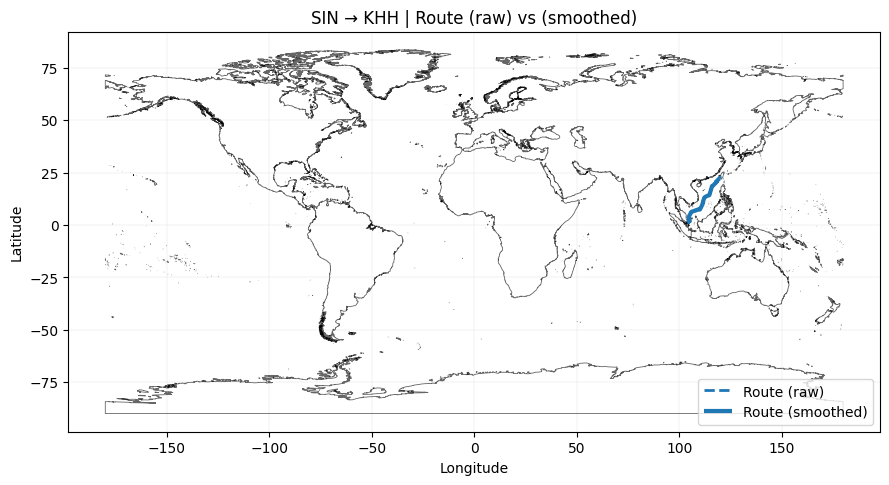

In [3]:
# === Smooth current route_sin_to_ks and write route_sin_to_ks_smooth + inline plot ===
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
from shapely.ops import split
from pyproj import Geod, CRS, Transformer

# 參數（可微調）
DENSIFY_EVERY_KM = 10.0    # 大地線加密間距
CHAIKIN_ITERS = 2          # Chaikin 次數（2 次很順，1 次較保守）
DP_TOL_KM = 1.0            # DP 簡化容差（km）
NEARSHORE_BUFFER_KM = 0.5  # 與陸地最小安全距離（視情況調）

geod = Geod(ellps="WGS84")

def geodesic_densify(ls: LineString, every_km=DENSIFY_EVERY_KM) -> LineString:
    coords = list(ls.coords)
    out = [coords[0]]
    for (lon1, lat1), (lon2, lat2) in zip(coords[:-1], coords[1:]):
        # 段長（m）
        _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
        n = int(max(dist / (every_km * 1000.0), 1))
        # 內插 n-1 個點
        if n > 1:
            pts = geod.npts(lon1, lat1, lon2, lat2, n - 1)
            out.extend(pts)
        out.append((lon2, lat2))
    return LineString(out)

def chaikin(ls: LineString) -> LineString:
    P = np.array(ls.coords, dtype=float)
    if len(P) < 3:
        return ls
    Q = [P[0]]
    for i in range(len(P)-1):
        p, r = P[i], P[i+1]
        q = 0.75*p + 0.25*r
        s = 0.25*p + 0.75*r
        Q.extend([q, s])
    Q.append(P[-1])
    return LineString(Q)

def douglas_peucker_km(ls: LineString, tol_km=DP_TOL_KM) -> LineString:
    # 在近似等距投影下簡化，避免經緯度尺度差異
    # 用當地等距投影（方位等距）以路徑中心點為投影中心
    lonc, latc = np.mean([p[0] for p in ls.coords]), np.mean([p[1] for p in ls.coords])
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={latc} +lon_0={lonc} +datum=WGS84 +units=m +no_defs")
    tf_w2m = Transformer.from_crs(4326, aeqd, always_xy=True)
    tf_m2w = Transformer.from_crs(aeqd, 4326, always_xy=True)
    xy = [tf_w2m.transform(lon, lat) for lon, lat in ls.coords]
    ls_m = LineString(xy).simplify(tol_km*1000.0, preserve_topology=False)
    w = [tf_m2w.transform(x, y) for x, y in ls_m.coords]
    return LineString(w)

def land_union_from_shp(shp_path):
    land = gpd.read_file(shp_path)
    if land.crs is None:
        land = land.set_crs(4326)
    land = land.to_crs(4326)
    return land.unary_union, land  # 回傳 union + 原邊界圖層（供畫圖）

def crosses_land(ls: LineString, land_union) -> bool:
    # 判斷是否與陸地相交（含接觸）
    return ls.buffer(1e-9).intersects(land_union)

def min_distance_to_land_km(ls: LineString, land_union) -> float:
    lonc, latc = np.mean([p[0] for p in ls.coords]), np.mean([p[1] for p in ls.coords])
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={latc} +lon_0={lonc} +datum=WGS84 +units=m +no_defs")
    tf_w2m = Transformer.from_crs(4326, aeqd, always_xy=True)
    # 把線與陸地都投影後量測
    ls_m = LineString([tf_w2m.transform(lon, lat) for lon, lat in ls.coords])
    land_gdf = gpd.GeoDataFrame(geometry=[land_union], crs=4326).to_crs(aeqd)
    d_m = ls_m.distance(land_gdf.geometry.iloc[0])
    return float(d_m/1000.0)

# 讀既有路徑
gpkg = CFG.out_gpkg if "CFG" in globals() else "route_backbone_RouteB.gpkg"
route_layer = "route_sin_to_ks"
gdf = gpd.read_file(gpkg, layer=route_layer)
if gdf.empty:
    raise RuntimeError("route_sin_to_ks 不存在或為空，請先跑求徑。")

route = gdf.geometry.iloc[0]
land_u, land_g = land_union_from_shp(CFG.land_shp if "CFG" in globals() else r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")

# 1) densify（大地線）
r1 = geodesic_densify(route, DENSIFY_EVERY_KM)

# 2) Chaikin（逐步提升，若撞陸就降級）
r2 = r1
ok = False
for iters in [CHAIKIN_ITERS, max(CHAIKIN_ITERS-1, 0), 0]:
    rtmp = r1
    for _ in range(iters):
        rtmp = chaikin(rtmp)
    # 3) DP 簡化
    rtmp = douglas_peucker_km(rtmp, DP_TOL_KM)
    # 安全檢查
    if not crosses_land(rtmp, land_u) and min_distance_to_land_km(rtmp, land_u) >= NEARSHORE_BUFFER_KM:
        r2 = rtmp
        ok = True
        break

if not ok:
    # 最保守：只 densify + 小容差簡化
    r2 = douglas_peucker_km(r1, DP_TOL_KM*0.5)

out = gpd.GeoDataFrame(
    gdf.drop(columns="geometry"),
    geometry=[r2],
    crs=4326
)
out_layer = route_layer + "_smooth"
out.to_file(gpkg, layer=out_layer, driver="GPKG")
print(f"✅ 已輸出平滑路徑：{gpkg} (layer={out_layer})")

# === 立即在 cell 內畫圖（不另存檔） ===
fig, ax = plt.subplots(figsize=(9, 9))

# 海岸線邊界
if not land_g.empty:
    land_g.boundary.plot(ax=ax, linewidth=0.6, color="black", alpha=0.6)

# 原始路徑（虛線）
gdf.plot(ax=ax, linewidth=2.0, linestyle="--", label="Route (raw)")

# 平滑路徑（實線、加粗）
out.plot(ax=ax, linewidth=3.0, label="Route (smoothed)")

# 若有 AOI，縮放到 AOI
if "CFG" in globals() and getattr(CFG, "roi_bbox", None):
    xmin, ymin, xmax, ymax = CFG.roi_bbox
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

ax.set_title("SIN → KHH | Route (raw) vs (smoothed)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right")
ax.grid(True, linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()


### Searoute pakage

In [217]:
import searoute as sr
import folium
import webbrowser

# 起訖點（(lon, lat)）----

origin = (139.8268, 35.61168)   
dest   = (-118.265, 33.74021)  

# 規劃路線 ----
route = sr.searoute(origin, dest, units="naut", speed_knot=18)

dist  = route.properties["length"]
units = route.properties["units"]
eta_h = route.properties.get("duration_hours")

coords_lonlat = route["geometry"]["coordinates"]
coords_latlon = [(lat, lon) for lon, lat in coords_lonlat]

# Folium 地圖與圖層 ----
mid_lat = (origin[1] + dest[1]) / 2
mid_lon = (origin[0] + dest[0]) / 2
m = folium.Map(location=[mid_lat, mid_lon], zoom_start=5, tiles="OpenStreetMap")

# 路徑線（也可以把 popup 掛在這條線上）
folium.PolyLine(coords_latlon, weight=4, opacity=0.9,
                popup=f"Distance: {dist:.2f} {units}"
                      + (f"<br>ETA: {eta_h:.2f} h" if eta_h else "")
               ).add_to(m)

# 起訖點
folium.Marker([origin[1], origin[0]], tooltip="Origin").add_to(m)
folium.Marker([dest[1],   dest[0]],   tooltip="Destination").add_to(m)

# 中點標記 + 摘要彈窗（可選）
mid_pt = coords_latlon[len(coords_latlon)//2]
folium.Marker(
    location=mid_pt,
    tooltip="Route summary",
    popup=folium.Popup(
        f"Distance: {dist:.2f} {units}"
        + (f"<br>ETA: {eta_h:.2f} h" if eta_h else ""),
        max_width=250
    ),
).add_to(m)

m.save("searoute_demo.html")
print("Saved: searoute_demo.html")

webbrowser.open("searoute_demo.html")

Saved: searoute_demo.html


True

In [5]:
import searoute as sr
import folium
import webbrowser

# ---- 1) 起訖點（(lon, lat)）----

origin = (117.21448, -20.4519)
dest   = (126.85998, 33.61352)

# ---- 2) 規劃路線 ----
route = sr.searoute(origin, dest, units="naut", speed_knot=18)

dist  = route.properties["length"]
units = route.properties["units"]
eta_h = route.properties.get("duration_hours")

coords_lonlat = route["geometry"]["coordinates"]
coords_latlon = [(lat, lon) for lon, lat in coords_lonlat]

# ---- 3) Folium 地圖與圖層 ----
mid_lat = (origin[1] + dest[1]) / 2
mid_lon = (origin[0] + dest[0]) / 2
m = folium.Map(location=[mid_lat, mid_lon], zoom_start=5, tiles="OpenStreetMap")

# 路徑線（也可以把 popup 掛在這條線上）
folium.PolyLine(coords_latlon, weight=4, opacity=0.9,
                popup=f"Distance: {dist:.2f} {units}"
                      + (f"<br>ETA: {eta_h:.2f} h" if eta_h else "")
               ).add_to(m)

# 起訖點
folium.Marker([origin[1], origin[0]], tooltip="Origin").add_to(m)
folium.Marker([dest[1],   dest[0]],   tooltip="Destination").add_to(m)

# 中點標記 + 摘要彈窗（可選）
mid_pt = coords_latlon[len(coords_latlon)//2]
folium.Marker(
    location=mid_pt,
    tooltip="Route summary",
    popup=folium.Popup(
        f"Distance: {dist:.2f} {units}"
        + (f"<br>ETA: {eta_h:.2f} h" if eta_h else ""),
        max_width=250
    ),
).add_to(m)

m.save("searoute_demo.html")
print("Saved: searoute_demo.html")

webbrowser.open("searoute_demo.html")

Saved: searoute_demo.html


True

In [6]:
#角度 + 段長過濾：只保留「方向變化 ≥ deg_threshold」且兩側段長都 ≥ min_seg_nm 的點
#B-spline 近似（用 Chaikin corner-cutting 實作，無需安裝 scipy）：產生平滑曲線


import searoute as sr
import folium
import webbrowser
import math

# -------------------- 幫手函式 --------------------
EARTH_RADIUS_NM = 3440.065  # nautical miles

def haversine_nm(p1, p2):
    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))
    return EARTH_RADIUS_NM * c

def bearing_deg(p1, p2):
    lon1, lat1 = map(math.radians, p1)
    lon2, lat2 = map(math.radians, p2)
    dlon = lon2 - lon1
    y = math.sin(dlon) * math.cos(lat2)
    x = math.cos(lat1)*math.cos(lat2) - math.sin(lat1)*math.sin(lat2)*math.cos(dlon)
    brng = math.degrees(math.atan2(y, x))
    return (brng + 360) % 360

def angle_segment_filter(coords_lonlat, deg_threshold=10.0, min_seg_nm=5.0):
    """ 保留「方向變化大於門檻且相鄰段長夠長」的轉折點；起訖一定保留 """
    n = len(coords_lonlat)
    if n <= 2:
        return coords_lonlat[:]

    keep = [coords_lonlat[0]]
    # 預先算每段長與方位
    seg_len = [haversine_nm(coords_lonlat[i], coords_lonlat[i+1]) for i in range(n-1)]
    seg_brg = [bearing_deg(coords_lonlat[i], coords_lonlat[i+1]) for i in range(n-1)]

    for i in range(1, n-1):
        # 角度變化（考慮 0/360）
        db = abs(seg_brg[i] - seg_brg[i-1])
        db = min(db, 360 - db)
        if db >= deg_threshold and seg_len[i-1] >= min_seg_nm and seg_len[i] >= min_seg_nm:
            keep.append(coords_lonlat[i])

    keep.append(coords_lonlat[-1])
    return keep

def chaikin_corner_cutting(coords_lonlat, iterations=3, ratio=0.25):
    """
    Chaikin 角切演算法（相當於二次 B-spline 近似），不需外部套件。
    保留端點，其餘用 Q/R 點替換：Q = (1-r)Pi + r*P_{i+1}, R = r*Pi + (1-r)P_{i+1}
    iterations 次數越多越平滑（建議 2~4）
    """
    if len(coords_lonlat) < 3 or iterations <= 0:
        return coords_lonlat[:]

    pts = coords_lonlat[:]
    for _ in range(iterations):
        new_pts = [pts[0]]
        for i in range(len(pts) - 1):
            x0, y0 = pts[i]
            x1, y1 = pts[i+1]
            qx = (1 - ratio) * x0 + ratio * x1
            qy = (1 - ratio) * y0 + ratio * y1
            rx = ratio * x0 + (1 - ratio) * x1
            ry = ratio * y0 + (1 - ratio) * y1
            new_pts.extend([(qx, qy), (rx, ry)])
        new_pts.append(pts[-1])
        pts = new_pts
    return pts

# -------------------- 1) 起訖點（(lon, lat)）--------------------
origin = (117.21448, -20.4519)
dest   = (126.85998, 33.61352)

# -------------------- 2) 路徑規劃（searoute） --------------------
feature = sr.searoute(origin, dest, units="naut", speed_knot=18)
dist  = feature.properties["length"]
units = feature.properties["units"]
eta_h = feature.properties.get("duration_hours")

coords_lonlat = feature["geometry"]["coordinates"]  # [(lon,lat), ...]
# 原始座標轉 (lat,lon) 給 Folium 畫
coords_latlon_raw = [(lat, lon) for lon, lat in coords_lonlat]

# -------------------- 3) 角度+段長過濾 → 取關鍵轉折點 --------------------
filtered_lonlat = angle_segment_filter(
    coords_lonlat,
    deg_threshold=12.0,   # 你可微調：10~20°
    min_seg_nm=8.0        # 你可微調：1~10nm，越大越“少碎點”
)

# -------------------- 4) 用 Chaikin 生成平滑曲線（B-spline 近似） --------------------
smoothed_lonlat = chaikin_corner_cutting(
    filtered_lonlat,
    iterations=3,  # 2~4 次通常就很順
    ratio=0.25
)
coords_latlon_smooth = [(lat, lon) for lon, lat in smoothed_lonlat]

# -------------------- 5) Folium 畫圖（原始 vs 平滑） --------------------
mid_lat = (origin[1] + dest[1]) / 2
mid_lon = (origin[0] + dest[0]) / 2
m = folium.Map(location=[mid_lat, mid_lon], zoom_start=4, tiles="OpenStreetMap")

# 圖層：原始路徑
fg_raw = folium.FeatureGroup(name="Original (searoute)")
folium.PolyLine(coords_latlon_raw, weight=3, opacity=0.6, color="blue",
                popup=f"Original: {dist:.2f} {units}"
                      + (f"<br>ETA: {eta_h:.2f} h" if eta_h else "")
               ).add_to(fg_raw)
fg_raw.add_to(m)

# 圖層：過濾後關鍵點（可視化）
fg_key = folium.FeatureGroup(name="Key turns (filtered)")
for lat, lon in [(lat, lon) for lon, lat in filtered_lonlat]:
    folium.CircleMarker(location=(lat, lon), radius=3, color="orange", fill=True).add_to(fg_key)
fg_key.add_to(m)

# 圖層：平滑曲線
fg_smooth = folium.FeatureGroup(name="Smoothed (Chaikin ~ B-spline)")
folium.PolyLine(coords_latlon_smooth, weight=4, opacity=0.9, color="red",
                popup="Smoothed path (Chaikin)").add_to(fg_smooth)
fg_smooth.add_to(m)

# 起訖點
folium.Marker([origin[1], origin[0]], tooltip="Origin").add_to(m)
folium.Marker([dest[1],   dest[0]],   tooltip="Destination").add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

m.save("searoute_demo.html")
print("Saved: searoute_demo.html")
webbrowser.open("searoute_demo.html")


Saved: searoute_demo.html


True

### SCgraph pakage

In [189]:
from scgraph.geographs.marnet import marnet_geograph

out = marnet_geograph.get_shortest_path(
    origin_node={"latitude": 25.0, "longitude": 121.5},
    destination_node={"latitude": 23.0, "longitude": 120.3},
    output_units="km",
    cache=True,                          # 要用 cache → 接點策略用 kdclosest / closest
    node_addition_type="kdclosest",
    destination_node_addition_type="kdclosest",
    node_addition_lat_lon_bound=3,
    output_coordinate_path="list_of_lists"   # ← 關鍵：改成字串而非 True
)

path = out["coordinate_path"]
dist_km = out["length"]
print(dist_km, len(path))

# 如果還沒裝：
# pip install folium

import folium
from typing import Sequence

def _to_latlon(pt):
    """
    將 scgraph 的單一座標點統一成 (lat, lon)
    - 支援 dict: {"latitude":..., "longitude":...}
    - 支援 list/tuple: [lat, lon] 或 [lon, lat]（會自動判斷）
    """
    if isinstance(pt, dict):
        return (pt["latitude"], pt["longitude"])
    if isinstance(pt, (list, tuple)) and len(pt) >= 2:
        a, b = pt[0], pt[1]
        # 若第一個值超過緯度範圍（>90），就視為 (lon, lat) 反轉
        if abs(a) > 90 and abs(b) <= 90:
            return (b, a)
        # 否則就當作 (lat, lon)
        return (a, b)
    raise ValueError(f"Unrecognized point format: {pt}")

def _flatten_coordinate_path(coord_path):
    """
    不管是:
      - list_of_dicts: [ {latitude, longitude}, ... ]
      - list_of_lists: [ [lat, lon], ... ] 或 [[lon, lat], ...]
      - list_of_lists_long_first: [ [lat,lon], [lat,lon], ... ]（順序可能依 segment 長度分組）
    都轉成 [(lat, lon), ...]
    """
    # 如果是「長段優先」的格式，可能是巢狀的 list，要攤平成單層
    # 判斷：若最外層元素還是序列且其內第一個元素又是序列/字典，視為需要攤平一層
    flattened = []
    if coord_path and isinstance(coord_path[0], Sequence) and len(coord_path[0]) > 0 and isinstance(coord_path[0][0], (list, tuple, dict)):
        # e.g., [[ [lat,lon], [lat,lon] ], [ ... ], ...]
        for seg in coord_path:
            for pt in seg:
                flattened.append(_to_latlon(pt))
    else:
        for pt in coord_path:
            flattened.append(_to_latlon(pt))
    return flattened

# === 這裡放你前面得到的 out ===
# 例如：
# out = marnet_geograph.get_shortest_path(
#     origin_node={"latitude": 25.0, "longitude": 121.5},
#     destination_node={"latitude": 23.0, "longitude": 120.3},
#     output_units="km",
#     cache=True,
#     node_addition_type="kdclosest",
#     destination_node_addition_type="kdclosest",
#     node_addition_lat_lon_bound=3,
#     output_coordinate_path="list_of_lists",  # 或 "list_of_dicts" / "list_of_lists_long_first"
# )

coords_latlon = _flatten_coordinate_path(out["coordinate_path"])
dist_km = out["length"]

# 建立地圖（以路徑中點當中心）
mid_idx = len(coords_latlon) // 2
m = folium.Map(location=coords_latlon[mid_idx], zoom_start=5, tiles="OpenStreetMap")

# 畫路徑
folium.PolyLine(
    locations=coords_latlon,
    weight=4,
    opacity=0.9,
    tooltip=f"Shortest sea route • {dist_km:.1f} km"
).add_to(m)

# 起訖標記
folium.Marker(
    location=coords_latlon[0],
    icon=folium.Icon(color="green"),
    tooltip="Origin"
).add_to(m)

folium.Marker(
    location=coords_latlon[-1],
    icon=folium.Icon(color="red"),
    tooltip="Destination"
).add_to(m)

# 顯示或存檔
out_path = r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA\srcgraph_testing.html"
m.save(out_path)
webbrowser.open("srcgraph_testing.html")
# m.save("scgraph_route.html")  # 若你在 .py 檔執行，可解註存成 HTML


674.6525335259114 4


True

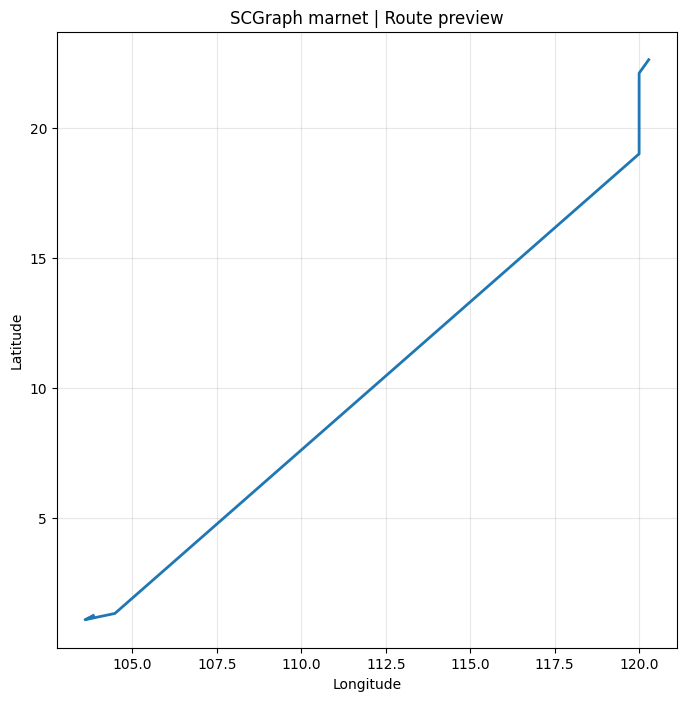

Route length (km): 3135.11
First 3 points: [(103.842, 1.264), (103.6, 1.1), (104.4823, 1.3413)]


In [10]:
# --- Robust extraction + inline plot for scgraph output ---

import math
import matplotlib.pyplot as plt

def _to_lonlat_list(coord_path):
    """Accepts scgraph's coordinate_path as list of dicts or list/tuples.
       Returns list of (lon, lat) pairs."""
    out = []
    for p in coord_path:
        lon = lat = None
        if isinstance(p, dict):
            lon = p.get("longitude") or p.get("lon") or p.get("x")
            lat = p.get("latitude")  or p.get("lat")  or p.get("y")
        elif isinstance(p, (list, tuple)) and len(p) >= 2:
            a, b = p[0], p[1]
            # 嘗試判斷順序：經度範圍[-180,180]、緯度[-90,90]
            if -180 <= a <= 180 and -90 <= b <= 90:
                lon, lat = a, b
            elif -90 <= a <= 90 and -180 <= b <= 180:
                lon, lat = b, a
            else:
                # 無法判斷就當作 (lon, lat)
                lon, lat = a, b
        if lon is None or lat is None or not (math.isfinite(lon) and math.isfinite(lat)):
            continue
        out.append((float(lon), float(lat)))
    return out

# --- 使用你前一個 cell 得到的 out 物件 ---
# out = marnet_geograph.get_shortest_path(...)

coords = _to_lonlat_list(out["coordinate_path"])
if not coords:
    raise RuntimeError("coordinate_path 無法解析，請打印 out 看其結構。")

# 畫圖
xs, ys = zip(*coords)
plt.figure(figsize=(8, 8))
plt.plot(xs, ys, lw=2)
plt.title("SCGraph marnet | Route preview")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(alpha=0.3)
plt.show()

print("Route length (km):", round(out.get("length", float('nan')), 2))
print("First 3 points:", coords[:3])


⚠️ 找不到直接的邊資料，改用『路徑抽樣疊加』產生視覺化…


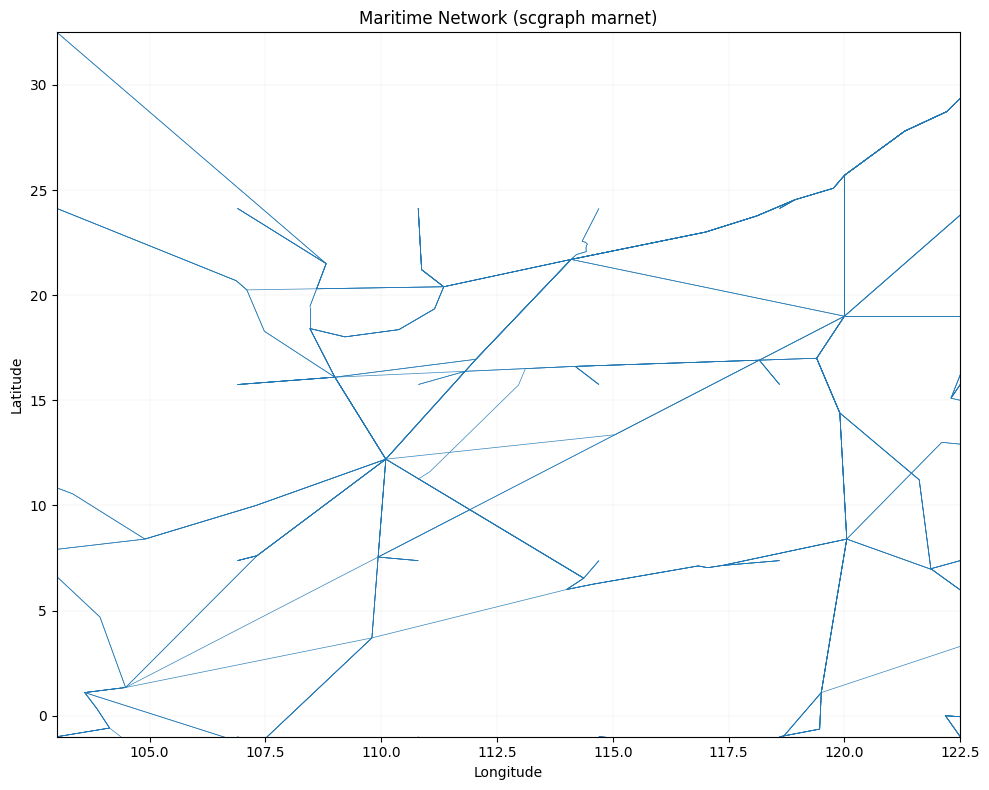

In [12]:
# === Draw maritime network from scgraph.marnet (robust, with fallbacks) ===
import math, random
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# 可選 AOI（lon/lat bbox）；若你有 CFG.roi_bbox 會自動沿用
if 'CFG' in globals() and getattr(CFG, 'roi_bbox', None):
    AOI = tuple(CFG.roi_bbox)
else:
    # 你之前常用的 AOI：南海～台灣海峽
    AOI = (103.0, -1.0, 122.5, 32.5)  # 設 None 代表畫全球

EDGE_SAMPLE_RATIO = 1.0  # 如果太密可調成 0.3~0.5 抽稀
MAX_SAMPLE_ROUTES = 60   # fallback 時抽樣的路徑條數（AOI 太大可減少）

from scgraph.geographs.marnet import marnet_geograph as MNET

def _collect_segments_from_geodataframe(gdf):
    try:
        import geopandas as gpd
        from shapely.geometry import LineString, MultiLineString
    except Exception:
        return None
    if gdf is None:
        return None
    try:
        # 嘗試把任何像 GeoDataFrame 的東西轉成 list of segments
        segs = []
        geoms = getattr(gdf, "geometry", None)
        if geoms is None: 
            return None
        for geom in geoms:
            if geom is None: 
                continue
            gtype = getattr(geom, "geom_type", "")
            if gtype == "LineString":
                coords = np.asarray(geom.coords, dtype=float)
                segs.extend([coords[i:i+2] for i in range(len(coords)-1)])
            elif gtype == "MultiLineString":
                for ls in geom.geoms:
                    coords = np.asarray(ls.coords, dtype=float)
                    segs.extend([coords[i:i+2] for i in range(len(coords)-1)])
        return segs if segs else None
    except Exception:
        return None

def _try_extract_geodataframe_from_mnet():
    # 嘗試從 marnet_geograph 物件上找到任何 GeoDataFrame-like 的屬性
    cand = []
    for name in dir(MNET):
        if any(k in name.lower() for k in ["edge", "line", "gdf", "geodata", "network"]):
            try:
                obj = getattr(MNET, name)
                # 懶判斷：有 .geometry 屬性就試試
                if hasattr(obj, "geometry"):
                    segs = _collect_segments_from_geodataframe(obj)
                    if segs:
                        cand.append((name, segs))
            except Exception:
                pass
    # 回傳第一個成功者
    return cand[0][1] if cand else None

def _segments_from_edges_list(edges, nodes_lookup=None):
    # edges 可能是 list of dict 或 list of tuples；嘗試從中還原座標
    segs = []
    for e in edges:
        try:
            if isinstance(e, (list, tuple)) and len(e) >= 2:
                u, v = e[0], e[1]
                if nodes_lookup and u in nodes_lookup and v in nodes_lookup:
                    pu, pv = nodes_lookup[u], nodes_lookup[v]
                    segs.append(np.asarray([pu, pv], dtype=float))
            elif isinstance(e, dict):
                # 可能帶 geometry 或 coordinates
                if "geometry" in e and hasattr(e["geometry"], "coords"):
                    coords = np.asarray(e["geometry"].coords, dtype=float)
                    segs.extend([coords[i:i+2] for i in range(len(coords)-1)])
                elif "coordinates" in e and isinstance(e["coordinates"], (list, tuple)):
                    coords = np.asarray(e["coordinates"], dtype=float)
                    if coords.ndim == 2 and coords.shape[1] == 2:
                        segs.extend([coords[i:i+2] for i in range(len(coords)-1)])
        except Exception:
            continue
    return segs if segs else None

def _try_graph_like_and_build_segments():
    # 嘗試抓 nodes/edges 結構（不一定是 networkx，但有 nodes/edges 就用）
    for attr in ("graph", "_graph", "geograph", "network", "G", "_G"):
        G = getattr(MNET, attr, None)
        if G is None: 
            continue
        # 嘗試取得 nodes
        nodes = None
        for nattr in ("nodes", "node", "vertices", "_nodes"):
            try:
                obj = getattr(G, nattr)
            except Exception:
                obj = None
            if obj is None:
                continue
            # obj 可能是可迭代 (n, data)
            try:
                tmp = {}
                it = obj(data=True) if callable(obj) else obj
                for item in it:
                    if isinstance(item, tuple) and len(item) == 2:
                        nid, data = item
                        lon = data.get("longitude") or data.get("lon") or data.get("x")
                        lat = data.get("latitude") or data.get("lat") or data.get("y")
                        if lon is not None and lat is not None:
                            tmp[nid] = (float(lon), float(lat))
                if tmp:
                    nodes = tmp
                    break
            except Exception:
                # 也可能是一個 dict-like
                try:
                    tmp = {}
                    for nid, data in obj.items():
                        if isinstance(data, dict):
                            lon = data.get("longitude") or data.get("lon") or data.get("x")
                            lat = data.get("latitude") or data.get("lat") or data.get("y")
                            if lon is not None and lat is not None:
                                tmp[nid] = (float(lon), float(lat))
                    if tmp:
                        nodes = tmp
                        break
                except Exception:
                    pass
        # 嘗試 edges
        for eattr in ("edges", "_edges", "links"):
            edges = getattr(G, eattr, None)
            if edges is None:
                continue
            # 如果是 callable，例如 edges()，先呼叫
            try:
                edges = edges() if callable(edges) else edges
            except Exception:
                pass
            segs = _segments_from_edges_list(edges, nodes_lookup=nodes)
            if segs:
                return segs
    return None

def _in_aoi(pt, aoi):
    if aoi is None:
        return True
    x, y = pt
    x0, y0, x1, y1 = aoi
    return (x0 <= x <= x1) and (y0 <= y <= y1)

def _draw_segments(segs, aoi):
    # AOI 篩選與抽稀
    segs2 = []
    for s in segs:
        if s is None or len(s) != 2:
            continue
        if aoi is None or (_in_aoi(s[0], aoi) or _in_aoi(s[1], aoi)):
            if EDGE_SAMPLE_RATIO >= 1.0 or random.random() <= EDGE_SAMPLE_RATIO:
                segs2.append(s)
    if not segs2:
        raise RuntimeError("在目前 AOI/抽稀條件下沒有可畫邊，請放寬 AOI 或提高 EDGE_SAMPLE_RATIO。")

    fig, ax = plt.subplots(figsize=(10, 8))
    lc = LineCollection(segs2, linewidths=0.5, alpha=0.9)
    ax.add_collection(lc)
    if aoi:
        x0, y0, x1, y1 = aoi
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
    else:
        ax.set_xlim(-180, 180); ax.set_ylim(-70, 85)
    ax.set_title("Maritime Network (scgraph marnet)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3, linewidth=0.3)
    plt.tight_layout()
    plt.show()

# --- 嘗試 1：直接找 GeoDataFrame 層（最快） ---
segs = _try_extract_geodataframe_from_mnet()

# --- 嘗試 2：找 graph-like 結構的 nodes/edges ---
if not segs:
    segs = _try_graph_like_and_build_segments()

# --- Fallback：用多條路徑疊加（保底一定可畫） ---
if not segs:
    print("⚠️ 找不到直接的邊資料，改用『路徑抽樣疊加』產生視覺化…")
    from scgraph.utils import get_line_path
    from scgraph.geographs.marnet import marnet_geograph
    segs = []
    # 在 AOI 內建一個粗格點集合
    if AOI is None:
        AOI = (60, -20, 150, 40)  # 給個示例（印度洋～東亞），避免全球抽樣太慢；你可改成全球
    x0, y0, x1, y1 = AOI
    nx, ny = 6, 5
    xs = np.linspace(x0, x1, nx)
    ys = np.linspace(y0, y1, ny)
    points = [(float(x), float(y)) for x in xs for y in ys]
    # 抽幾對點跑最短路
    pairs = []
    for _ in range(MAX_SAMPLE_ROUTES):
        a, b = random.sample(points, 2)
        pairs.append((a, b))
    for (lon1, lat1), (lon2, lat2) in pairs:
        try:
            out = marnet_geograph.get_shortest_path(
                origin_node={"longitude": lon1, "latitude": lat1},
                destination_node={"longitude": lon2, "latitude": lat2},
                output_units="km",
            )
            path = out.get("coordinate_path", [])
            # 轉成 segments
            coords = []
            for p in path:
                if isinstance(p, dict):
                    lon = p.get("longitude") or p.get("lon") or p.get("x")
                    lat = p.get("latitude")  or p.get("lat")  or p.get("y")
                    if lon is not None and lat is not None:
                        coords.append((float(lon), float(lat)))
                elif isinstance(p, (list, tuple)) and len(p) >= 2:
                    a, b = p[0], p[1]
                    # 盡量判斷 (lon,lat)
                    if -180 <= a <= 180 and -90 <= b <= 90:
                        coords.append((float(a), float(b)))
                    elif -90 <= a <= 90 and -180 <= b <= 180:
                        coords.append((float(b), float(a)))
            if len(coords) >= 2:
                for i in range(len(coords)-1):
                    segs.append(np.asarray([coords[i], coords[i+1]], dtype=float))
        except Exception:
            continue

# 繪圖
_draw_segments(segs, AOI)


⚠️ 直接邊資料取得失敗，改用『路徑抽樣疊加』作為底圖感覺…


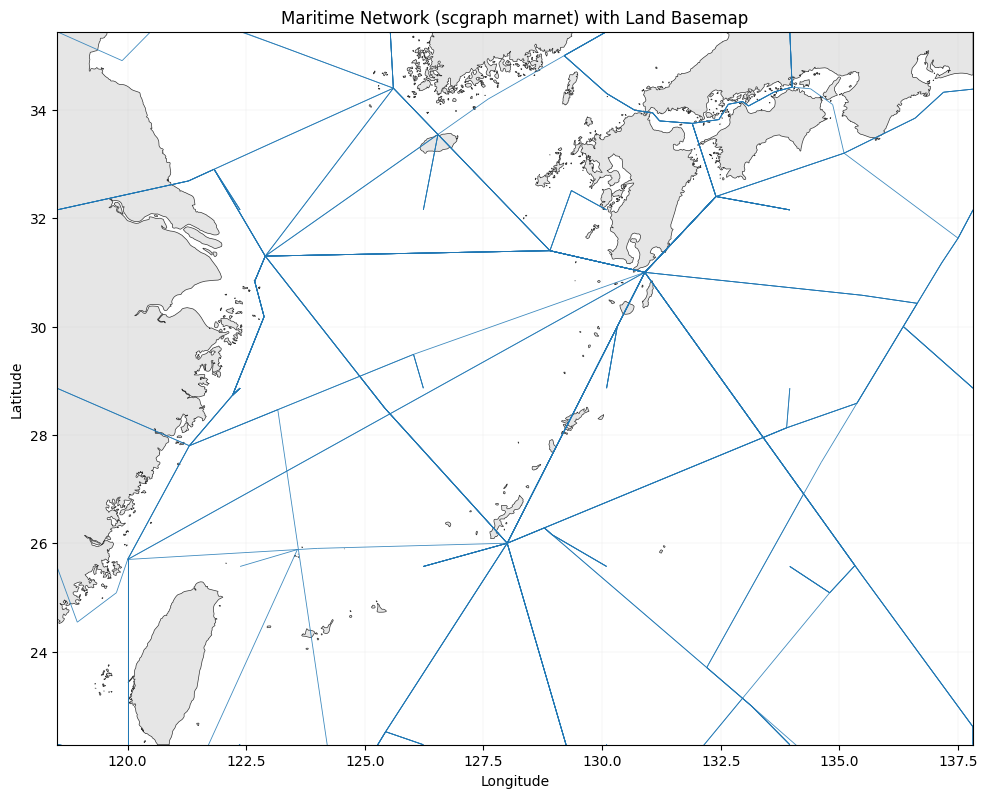

In [24]:
# === Maritime network with LAND basemap (offline, fast) ===
import math, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


# -------- 配置區 --------
# 你的陸地底圖（Natural Earth 10m）
land_shp = CFG.land_shp if 'CFG' in globals() else r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp"

# AOI（lon/lat bbox）；若你有 CFG.roi_bbox 就用它，否則用你之前的南海～台灣海峽
if 'CFG' in globals() and getattr(CFG, 'roi_bbox', None):
    AOI = tuple(CFG.roi_bbox)
else:
    AOI = (118.508333, 22.28, 137.81879, 35.44369)   # 設 None 代表畫全球

EDGE_SAMPLE_RATIO = 1.0   # 線網太密可降到 0.3~0.5 抽稀
MAX_SAMPLE_ROUTES = 60    # 抽樣路徑保底時最多跑幾條（AOI 很大可降低）

# -------- 取 marnet 線網（跟前面邏輯相同，內含多重 fallback） --------
from scgraph.geographs.marnet import marnet_geograph as MNET

def _segments_from_edges_list(edges, nodes_lookup=None):
    segs = []
    for e in edges:
        try:
            if isinstance(e, (list, tuple)) and len(e) >= 2:
                u, v = e[0], e[1]
                if nodes_lookup and u in nodes_lookup and v in nodes_lookup:
                    pu, pv = nodes_lookup[u], nodes_lookup[v]
                    segs.append(np.asarray([pu, pv], dtype=float))
            elif isinstance(e, dict):
                if "geometry" in e and hasattr(e["geometry"], "coords"):
                    coords = np.asarray(e["geometry"].coords, dtype=float)
                    segs.extend([coords[i:i+2] for i in range(len(coords)-1)])
                elif "coordinates" in e and isinstance(e["coordinates"], (list, tuple)):
                    coords = np.asarray(e["coordinates"], dtype=float)
                    if coords.ndim == 2 and coords.shape[1] == 2:
                        segs.extend([coords[i:i+2] for i in range(len(coords)-1)])
        except Exception:
            continue
    return segs if segs else None

def _try_graph_like_and_build_segments():
    for attr in ("graph", "_graph", "geograph", "network", "G", "_G"):
        G = getattr(MNET, attr, None)
        if G is None: 
            continue
        # nodes
        nodes = None
        for nattr in ("nodes", "node", "vertices", "_nodes"):
            try:
                obj = getattr(G, nattr)
            except Exception:
                obj = None
            if obj is None:
                continue
            try:
                tmp = {}
                it = obj(data=True) if callable(obj) else obj
                for item in it:
                    if isinstance(item, tuple) and len(item) == 2:
                        nid, data = item
                        lon = data.get("longitude") or data.get("lon") or data.get("x")
                        lat = data.get("latitude")  or data.get("lat")  or data.get("y")
                        if lon is not None and lat is not None:
                            tmp[nid] = (float(lon), float(lat))
                if tmp:
                    nodes = tmp
                    break
            except Exception:
                try:
                    tmp = {}
                    for nid, data in obj.items():
                        if isinstance(data, dict):
                            lon = data.get("longitude") or data.get("lon") or data.get("x")
                            lat = data.get("latitude")  or data.get("lat")  or data.get("y")
                            if lon is not None and lat is not None:
                                tmp[nid] = (float(lon), float(lat))
                    if tmp:
                        nodes = tmp
                        break
                except Exception:
                    pass
        # edges
        for eattr in ("edges", "_edges", "links"):
            edges = getattr(G, eattr, None)
            if edges is None:
                continue
            try:
                edges = edges() if callable(edges) else edges
            except Exception:
                pass
            segs = _segments_from_edges_list(edges, nodes_lookup=nodes)
            if segs:
                return segs
    return None

# 直接抓不到就用抽樣路徑堆疊
def _fallback_segments_by_sampling(aoi, n_paths=MAX_SAMPLE_ROUTES):
    from scgraph.geographs.marnet import marnet_geograph
    segs = []
    if aoi is None:
        aoi = (60, -20, 150, 40)  # 避免抽整個地球太慢；可改
    x0, y0, x1, y1 = aoi
    nx, ny = 6, 5
    xs = np.linspace(x0, x1, nx)
    ys = np.linspace(y0, y1, ny)
    pts = [(float(x), float(y)) for x in xs for y in ys]
    for _ in range(n_paths):
        (lon1, lat1), (lon2, lat2) = random.sample(pts, 2)
        try:
            out = marnet_geograph.get_shortest_path(
                origin_node={"longitude": lon1, "latitude": lat1},
                destination_node={"longitude": lon2, "latitude": lat2},
                output_units="km",
            )
            path = out.get("coordinate_path", [])
            coords = []
            for p in path:
                if isinstance(p, dict):
                    lon = p.get("longitude") or p.get("lon") or p.get("x")
                    lat = p.get("latitude")  or p.get("lat")  or p.get("y")
                    if lon is not None and lat is not None:
                        coords.append((float(lon), float(lat)))
                elif isinstance(p, (list, tuple)) and len(p) >= 2:
                    a, b = p[0], p[1]
                    if -180 <= a <= 180 and -90 <= b <= 90:
                        coords.append((float(a), float(b)))
                    elif -90 <= a <= 90 and -180 <= b <= 180:
                        coords.append((float(b), float(a)))
            if len(coords) >= 2:
                for i in range(len(coords)-1):
                    segs.append(np.asarray([coords[i], coords[i+1]], dtype=float))
        except Exception:
            continue
    return segs

# 取得線段
segs = _try_graph_like_and_build_segments()
if not segs:
    print("⚠️ 直接邊資料取得失敗，改用『路徑抽樣疊加』作為底圖感覺…")
    segs = _fallback_segments_by_sampling(AOI)

# -------- 讀取陸地底圖並畫圖 --------
import geopandas as gpd

try:
    land = gpd.read_file(land_shp)
    if land.crs is None:
        land = land.set_crs(4326)
    land = land.to_crs(4326)
    # 若有 AOI，先裁一遍加速顯示
    if AOI is not None:
        from shapely.geometry import box
        aoi_poly = gpd.GeoDataFrame(geometry=[box(*AOI)], crs=4326)
        try:
            land = land.clip(aoi_poly)
        except Exception:
            land = gpd.overlay(land, aoi_poly, how="intersection")
except Exception as e:
    print(f"⚠️ 讀取 land_shp 失敗：{e}")
    land = gpd.GeoDataFrame(geometry=[], crs=4326)

def _in_aoi(pt, aoi):
    if aoi is None: return True
    x, y = pt
    x0, y0, x1, y1 = aoi
    return (x0 <= x <= x1) and (y0 <= y <= y1)

# AOI 篩選 + 抽稀
segs2 = []
for s in segs:
    if s is None or len(s) != 2:
        continue
    if AOI is None or (_in_aoi(s[0], AOI) or _in_aoi(s[1], AOI)):
        if EDGE_SAMPLE_RATIO >= 1.0 or random.random() <= EDGE_SAMPLE_RATIO:
            segs2.append(s)

if not segs2:
    raise RuntimeError("在目前 AOI/抽稀條件下沒有可畫邊，請放寬 AOI 或提高 EDGE_SAMPLE_RATIO。")

# 繪圖
fig, ax = plt.subplots(figsize=(10, 8))

# 底圖：陸地填色 + 海岸線
if not land.empty:
    land.plot(ax=ax, facecolor="#e6e6e6", edgecolor="#333333", linewidth=0.5, alpha=1.0)
else:
    print("⚠️ 無法顯示陸地底圖，僅繪製線網。")

# 海上線網
lc = LineCollection(segs2, linewidths=0.6, alpha=0.85)
ax.add_collection(lc)

# 視窗
if AOI:
    x0, y0, x1, y1 = AOI
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
else:
    ax.set_xlim(-180, 180); ax.set_ylim(-70, 85)

ax.set_title("Maritime Network (scgraph marnet) with Land Basemap")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(alpha=0.25, linewidth=0.3)
plt.tight_layout()
plt.show()


### 嘗試起迄點閃躲辦法

In [ ]:
# --- PATCH 1: 參數調整 ---
STEP_KM = 5.0               # 大圓抽點相交檢查：固定 5 km 取樣
MAX_LINE_SEARCH_KM = 800.0  # 清障沿切線最大前進距離（海域大塊用 600~1000km 更穩）
TANGENT_SIDE_PENALTY = 0.6  # 轉角罰維持小即可

from shapely.geometry import Point, LineString
from shapely.ops import unary_union
from pyproj import Geod, CRS, Transformer
import numpy as np, math, geopandas as gpd, matplotlib.pyplot as plt
geod = Geod(ellps="WGS84")

# --- PATCH 2: 大圓取樣 & 相交檢查（固定 5km） ---
def densify_geodesic(lon1, lat1, lon2, lat2, every_km=STEP_KM):
    _, _, dist_m = geod.inv(lon1, lat1, lon2, lat2)
    n = max(2, int(max(dist_m/1000.0 / max(every_km,1e-3), 2)))
    if n <= 2:
        return LineString([(lon1, lat1), (lon2, lat2)])
    pts = geod.npts(lon1, lat1, lon2, lat2, n-2)
    return LineString([(lon1, lat1)] + pts + [(lon2, lat2)])

def geodesic_intersects_land(lon1, lat1, lon2, lat2, land_union, step_km=STEP_KM):
    ls = densify_geodesic(lon1, lat1, lon2, lat2, every_km=step_km)
    return ls.intersects(land_union)

# --- PATCH 3: 允許在切點「接觸」但不可穿越的可視性檢查 ---
def visible_allow_touch_at(B, A, T, land_union):
    """
    線段 A->T 若只在 T 與陸地接觸，視為可視。
    作法：把 land_union 減去一個小小的 T 鄰域再檢查相交。
    """
    seg = densify_geodesic(A[0], A[1], T[0], T[1], every_km=2.0)
    # 一個極小的 T 鄰域（約數十公尺）
    T_eps = Point(T[0], T[1]).buffer(1e-5)  # WGS84 度量下 ~1m 等級，足夠只排除接觸
    land_minus_T = land_union.difference(T_eps)
    # 若仍相交（穿越）則不可視；若只在 T 接觸則 OK
    return not seg.intersects(land_minus_T)

# --- PATCH 4: 第一阻擋體（沿大圓順序找最早那塊） ---
def first_blocker_union(S, G, land_union, step_km=STEP_KM):
    if land_union.is_empty:
        return None
    geoms = list(land_union.geoms) if hasattr(land_union, "geoms") else [land_union]
    ls = densify_geodesic(S[0], S[1], G[0], G[1], every_km=step_km)
    coords = list(ls.coords)
    best_i, best_poly = None, None
    for pi, poly in enumerate(geoms):
        hit_i = None
        for i in range(len(coords)-1):
            seg = LineString([coords[i], coords[i+1]])
            if seg.intersects(poly):
                hit_i = i
                break
        if hit_i is not None and (best_i is None or hit_i < best_i):
            best_i, best_poly = hit_i, poly
    return best_poly

# ---（保留你原本的）凸包近似、切點近似、清障搜尋 ---
def aeqd_transformers(center_lon, center_lat):
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={center_lat} +lon_0={center_lon} +datum=WGS84 +units=m +no_defs")
    return Transformer.from_crs(4326, aeqd, always_xy=True), Transformer.from_crs(aeqd, 4326, always_xy=True)

def convex_visible_hull_from_point(poly, S):
    return poly.convex_hull

DELTA_TANGENT_M = 800.0
def tangent_candidates_from_point_to_polygon(S, poly):
    tf_w2m, tf_m2w = aeqd_transformers(S[0], S[1])
    coords = list(poly.exterior.coords)
    if not coords:
        return None, None
    XY = [tf_w2m.transform(x, y) for (x, y) in coords]
    angs = [math.atan2(Y, X) for (X, Y) in XY]
    i_left  = int(np.argmax(angs))
    i_right = int(np.argmin(angs))
    def back_to_lonlat(i):
        X, Y = XY[i]
        lon, lat = tf_m2w.transform(X, Y)
        azi,_,dist = geod.inv(S[0], S[1], lon, lat)
        lon2, lat2, _ = geod.fwd(S[0], S[1], azi, dist + DELTA_TANGENT_M)
        return (lon2, lat2)
    return back_to_lonlat(i_left), back_to_lonlat(i_right)

def earliest_clear_point_along_ray(S, G, T, blocker, step_km=2.0, max_ahead_km=MAX_LINE_SEARCH_KM):
    azi, _, _ = geod.inv(S[0], S[1], T[0], T[1])
    n = max(2, int(max_ahead_km/step_km))
    for i in range(1, n+1):
        d = i * step_km * 1000.0
        lonE, latE, _ = geod.fwd(S[0], S[1], azi, d)
        seg = densify_geodesic(lonE, latE, G[0], G[1], every_km=step_km)
        if not seg.intersects(blocker):
            return (lonE, latE)
    # 若沒找到，回傳最遠點（理論上很少發生）
    return geod.fwd(S[0], S[1], azi, max_ahead_km*1000.0)[:2]

def heading(lon1, lat1, lon2, lat2):
    azi12, _, _ = geod.inv(lon1, lat1, lon2, lat2)
    return azi12

def segment_cost_km(A, B):
    _, _, dist_m = geod.inv(A[0], A[1], B[0], B[1])
    return dist_m/1000.0

# --- PATCH 5: 重跑主流程（會覆寫 route_iterative_tangents 的核心片段） ---
def reroute_and_plot(
    gpkg="route_iter_tangent.gpkg",
    route_layer="iter_tangent_route",
    wpts_layer="waypoints",
    land_shp=r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp",
    dmin_km=3.0,
    figsize=(16,12),
):
    land_gdf = gpd.read_file(land_shp)
    if land_gdf.crs is None: land_gdf = land_gdf.set_crs(4326)
    # 緩衝 & union
    L = land_gdf.to_crs(3857).buffer(dmin_km*1000.0)
    land_u = gpd.GeoSeries([unary_union(L)], crs=3857).to_crs(4326).iloc[0]

    # 讀舊 GPKG 的起終點（從 waypoints 的首尾）
    w = gpd.read_file(gpkg, layer=wpts_layer).to_crs(4326)
    S = (w.geometry.iloc[0].x, w.geometry.iloc[0].y)
    G = (w.geometry.iloc[-1].x, w.geometry.iloc[-1].y)

    # 端點若在陸上，微推
    def ensure_offshore(p):
        if Point(p).buffer(1e-9).within(land_u):
            for az in np.linspace(0,360,16,endpoint=False):
                for step in [500, 1000, 2000]:
                    lon2, lat2, _ = geod.fwd(p[0], p[1], az, step)
                    if not Point(lon2, lat2).buffer(1e-9).within(land_u):
                        return (lon2, lat2)
        return p
    S, G = ensure_offshore(S), ensure_offshore(G)

    path = [S]
    curr = S
    for _ in range(8):  # 最多迭代 8 次
        if not geodesic_intersects_land(curr[0], curr[1], G[0], G[1], land_u, step_km=STEP_KM):
            path.append(G); break
        B = first_blocker_union(curr, G, land_u, step_km=STEP_KM)
        if B is None or B.is_empty: path.append(G); break
        Bhull = convex_visible_hull_from_point(B, curr)
        TL, TR = tangent_candidates_from_point_to_polygon(curr, Bhull)
        sides = []
        for tag, T in [("L", TL), ("R", TR)]:
            if T is None: 
                continue
            if visible_allow_touch_at(B, curr, T, land_u):
                cost = segment_cost_km(curr, T) + segment_cost_km(T, G)
                if len(path) >= 2:
                    prev = path[-2]
                    dtheta = abs((heading(prev[0], prev[1], curr[0], curr[1]) - heading(curr[0], curr[1], T[0], T[1]) + 180)%360 - 180)
                    cost += TANGENT_SIDE_PENALTY*(dtheta/90.0)
                sides.append((cost, tag, T))
        if not sides:
            # 若兩側皆不可視，沿「遠離 B 的方位」小推 5km 再試（非常少見）
            # 用 curr->Bhull 最近點的反向方位
            nearest = np.array(Bhull.exterior.coords)[np.argmin([Point(*curr).distance(Point(x,y)) for x,y in Bhull.exterior.coords])]
            az,_,_ = geod.inv(nearest[0], nearest[1], curr[0], curr[1])
            curr = geod.fwd(curr[0], curr[1], az, 5000)[:2]
            path.append(curr)
            continue
        sides.sort(key=lambda x:x[0])
        Tbest = sides[0][2]
        E = earliest_clear_point_along_ray(curr, G, Tbest, B, step_km=2.0, max_ahead_km=MAX_LINE_SEARCH_KM)
        path.append(E); curr = E

    # 拼接成折線
    segs = [densify_geodesic(a[0],a[1],b[0],b[1],every_km=5.0) for a,b in zip(path[:-1], path[1:])]
    route = LineString([xy for ls in segs for xy in ls.coords])

    # 回寫 GPKG
    gpd.GeoDataFrame({"order":list(range(len(path))), "role":["S"]+["mid"]*(len(path)-2)+["G"]},
                     geometry=[Point(p) for p in path], crs=4326).to_file(gpkg, layer="waypoints", driver="GPKG")
    gpd.GeoDataFrame({"name":["iter_tangent"]}, geometry=[route], crs=4326).to_file(gpkg, layer="iter_tangent_route", driver="GPKG")
    print("✅ route updated in", gpkg)

    # 畫圖（自動 zoom 到航程 + 大 padding）
    minx, miny, maxx, maxy = gpd.GeoSeries([route], crs=4326).total_bounds
    dx, dy = maxx-minx, maxy-miny
    pad = max(dx, dy)*0.5
    pad = max(pad, 4.0)  # 至少 4 度 padding
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    land_gdf.to_crs(4326).plot(ax=ax, color="#e9ecef", edgecolor="#555", linewidth=0.6, zorder=0)
    gpd.GeoSeries([route], crs=4326).plot(ax=ax, color="#0b74de", linewidth=3.0, zorder=3)
    gpd.GeoSeries([Point(xy) for xy in path], crs=4326).plot(ax=ax, color="#ff6a00", markersize=50, zorder=4)
    for i,p in enumerate(path):
        ax.text(p[0], p[1], f"{i}", fontsize=12, ha="left", va="bottom", color="#cc5500", weight="bold")
    ax.set_xlim(minx-pad, maxx+pad); ax.set_ylim(miny-pad, maxy+pad)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
    ax.set_title("Iterative Tangent Route — Patched")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.tight_layout(); plt.show()

# 執行
reroute_and_plot()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


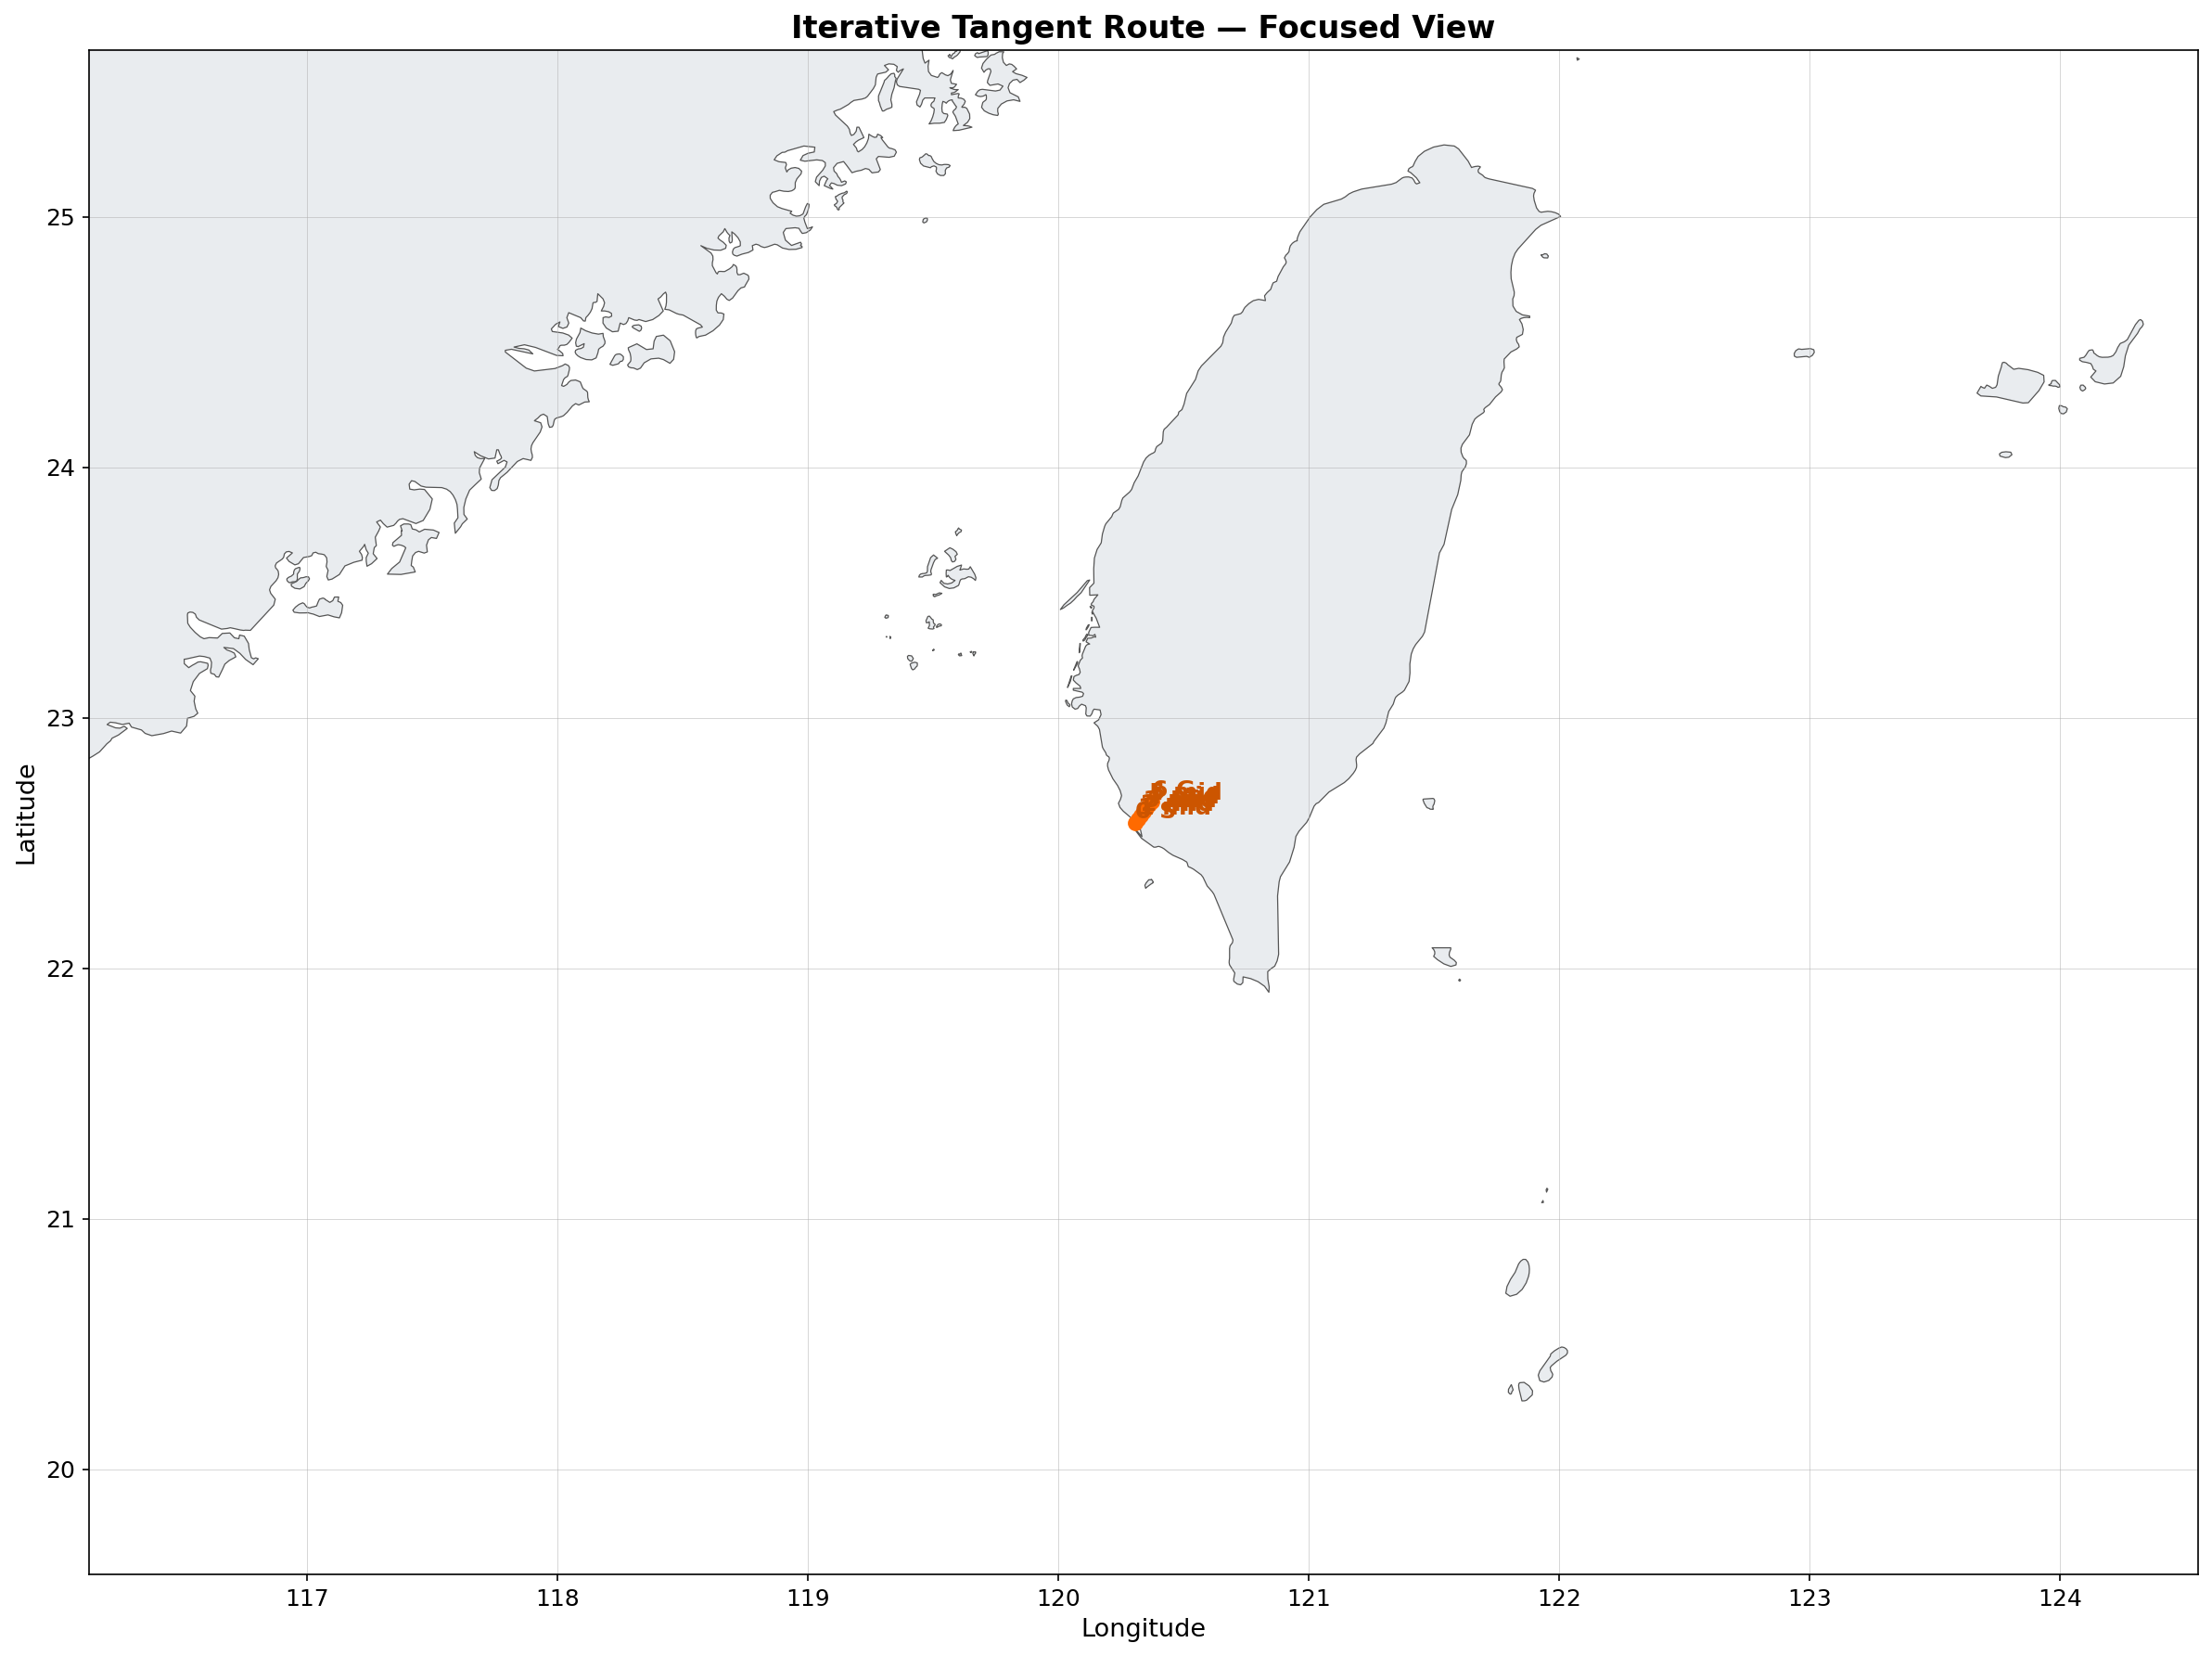

In [33]:
# 放大視窗、加大邊距、強化標示（高可讀版本）
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

gpkg = Path("route_iter_tangent.gpkg")
route_layer = "iter_tangent_route"
wpts_layer  = "waypoints"
land_shp = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")  # 有就畫，沒有也OK

# 讀資料
route = gpd.read_file(gpkg, layer=route_layer).to_crs(4326)
wpts  = gpd.read_file(gpkg, layer=wpts_layer).to_crs(4326)

# 取得路線外接盒並加上「較大」邊距；同時保證最小邊距（度）
minx, miny, maxx, maxy = route.total_bounds
dx, dy = maxx - minx, maxy - miny
pad = max(dx, dy) * 0.40  # 比之前更大
min_pad_deg = 3.0         # 至少給 3 度的邊距，避免太貼邊
pad = max(pad, min_pad_deg)

# 圖面更大、解析度更高
fig, ax = plt.subplots(figsize=(16, 12), dpi=150)

# 底圖（若有）
if land_shp.exists():
    land = gpd.read_file(land_shp)
    if land.crs is None: 
        land = land.set_crs(4326)
    land = land.to_crs(4326)
    land.plot(ax=ax, color="#e9ecef", edgecolor="#555", linewidth=0.6, zorder=0)

# 路徑與節點（加粗）
route.plot(ax=ax, color="#0b74de", linewidth=3.2, zorder=3)
wpts.plot(ax=ax, color="#ff6a00", markersize=50, zorder=4)

# 節點標號與 S/G 標籤
for i, row in wpts.iterrows():
    x, y = row.geometry.x, row.geometry.y
    role = row.get("role", "")
    label = f"{i} {role}".strip()
    ax.text(x, y, label, fontsize=12, weight="bold", ha="left", va="bottom", color="#cc5500", zorder=5)

# 強制視窗專注在航程附近
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

# 軸面樣式
ax.set_aspect('equal', adjustable='datalim')
ax.set_xlabel("Longitude", fontsize=13)
ax.set_ylabel("Latitude", fontsize=13)
ax.set_title("Iterative Tangent Route — Focused View", fontsize=16, weight="bold")
ax.grid(True, linewidth=0.4, alpha=0.6)

# 刻度字體更大
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# ==== Fix: robust first-blocker detection & grouping, then reroute & plot ====
import math, numpy as np, geopandas as gpd, matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
from shapely.ops import unary_union
from pyproj import Geod, CRS, Transformer

# --- 常數（可調） ---
STEP_KM = 5.0                  # 大圓抽點間距
GROUP_NEAR_KM = 20.0           # 將「距第一阻擋體 < 20km」的陸地一起併入
D_MIN_KM = 3.0                 # 安全離岸
DELTA_TANGENT_M = 800.0        # 切點外推
MAX_AHEAD_KM = 800.0           # 清障最大前進
TURN_PENALTY = 0.6             # 轉角罰

geod = Geod(ellps="WGS84")

def densify_gc(a, b, every_km=STEP_KM):
    lon1, lat1 = a; lon2, lat2 = b
    _,_,dist_m = geod.inv(lon1, lat1, lon2, lat2)
    n = max(2, int(max(dist_m/1000.0/every_km, 2)))
    if n <= 2:
        return LineString([a,b])
    pts = geod.npts(lon1, lat1, lon2, lat2, n-2)
    return LineString([a]+pts+[b])

def gc_intersects(a, b, poly):
    return densify_gc(a,b).intersects(poly)

def first_blocker_group(S, G, land_u):
    """
    沿大圓的順序，找『最早相交』的多邊形 first_poly；
    再把距離 first_poly < GROUP_NEAR_KM 的其它多邊形 union 成一塊。
    回傳 blocker (Polygon/MultiPolygon) 或 None
    """
    if land_u.is_empty:
        return None
    geoms = list(land_u.geoms) if hasattr(land_u, "geoms") else [land_u]
    ls = densify_gc(S, G)
    coords = list(ls.coords)

    # 找最早相交
    best_i, first_poly = None, None
    for poly in geoms:
        hit_i = None
        for i in range(len(coords)-1):
            seg = LineString([coords[i], coords[i+1]])
            if seg.intersects(poly):
                hit_i = i
                break
        if hit_i is not None and (best_i is None or hit_i < best_i):
            best_i, first_poly = hit_i, poly
    if first_poly is None:
        return None

    # 以 first_poly 為核心，把鄰近（< GROUP_NEAR_KM）的也 union 起來
    # 用等距投影估距：AEQD 以 first_poly 質心為中心
    cx, cy = first_poly.representative_point().x, first_poly.representative_point().y
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={cy} +lon_0={cx} +datum=WGS84 +units=m +no_defs")
    tf = Transformer.from_crs(4326, aeqd, always_xy=True)
    fp_m = gpd.GeoSeries([first_poly], crs=4326).to_crs(aeqd).iloc[0]
    union_list = [first_poly]
    for poly in geoms:
        pm = gpd.GeoSeries([poly], crs=4326).to_crs(aeqd).iloc[0]
        if pm.distance(fp_m) <= GROUP_NEAR_KM*1000.0:
            union_list.append(poly)

    return unary_union(union_list)

def aeqd_tf(lon, lat):
    aeqd = CRS.from_proj4(f"+proj=aeqd +lat_0={lat} +lon_0={lon} +datum=WGS84 +units=m +no_defs")
    return Transformer.from_crs(4326, aeqd, always_xy=True), Transformer.from_crs(aeqd, 4326, always_xy=True)

def convex_visible_hull(poly):
    return poly.convex_hull

def tangent_candidates(S, hull):
    # 在 S 的 AEQD 下，從邊界取角度極值當左右切點近似
    tf_w2m, tf_m2w = aeqd_tf(S[0], S[1])
    XY = [tf_w2m.transform(x,y) for x,y in hull.exterior.coords]
    if not XY:
        return None, None
    ang = [math.atan2(Y,X) for X,Y in XY]
    iL, iR = int(np.argmax(ang)), int(np.argmin(ang))
    def back(i):
        X,Y = XY[i]
        lon,lat = tf_m2w.transform(X,Y)
        az,_,d = geod.inv(S[0], S[1], lon, lat)
        lon2,lat2,_ = geod.fwd(S[0], S[1], az, d+DELTA_TANGENT_M)
        return (lon2,lat2)
    return back(iL), back(iR)

def visible_allow_touch(A, T, land_u):
    seg = densify_gc(A, T, every_km=2.0)
    tiny = Point(T).buffer(1e-5)
    return not seg.intersects(land_u.difference(tiny))

def earliest_clear_on_ray(S, G, T, blocker):
    az,_,_ = geod.inv(S[0], S[1], T[0], T[1])
    steps = int(MAX_AHEAD_KM/2.0)
    for i in range(1, steps+1):
        d = i*2000.0  # 2 km 一步
        lon,lat,_ = geod.fwd(S[0], S[1], az, d)
        if not densify_gc((lon,lat), G, every_km=2.0).intersects(blocker):
            return (lon,lat)
    # 應該很少到這
    return geod.fwd(S[0], S[1], az, MAX_AHEAD_KM*1000.0)[:2]

def seg_len_km(a,b):
    return geod.inv(a[0],a[1],b[0],b[1])[2]/1000.0

def heading(a,b):
    return geod.inv(a[0],a[1],b[0],b[1])[0]

def ensure_offshore(p, land_u):
    if Point(p).buffer(1e-9).within(land_u):
        for az in np.linspace(0,360,16,endpoint=False):
            for step in [500,1000,2000]:
                lon,lat,_ = geod.fwd(p[0],p[1],az,step)
                if not Point(lon,lat).buffer(1e-9).within(land_u):
                    return (lon,lat)
    return p

# === 重新路由並放大畫圖 ===
def reroute_iter_tangent_and_plot(
    gpkg="route_iter_tangent.gpkg",
    land_shp=r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp",
):
    land = gpd.read_file(land_shp)
    if land.crs is None: land = land.set_crs(4326)
    L = land.to_crs(3857).buffer(D_MIN_KM*1000.0)
    #land_u = gpd.GeoSeries([unary_union(L)], crs=3857).to_crs(4326).iloc[0]
    land_gdf, land_u = rebuild_land_union_with_fix(
    r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp",
    dmin_km=3.0
)

    # 讀你之前 GPKG 的 S/G（waypoints 的首尾）
    wpts = gpd.read_file(gpkg, layer="waypoints").to_crs(4326)
    S = (wpts.geometry.iloc[0].x, wpts.geometry.iloc[0].y)
    G = (wpts.geometry.iloc[-1].x, wpts.geometry.iloc[-1].y)
    S, G = ensure_offshore(S, land_u), ensure_offshore(G, land_u)

    path = [S]
    curr = S
    for _ in range(10):
        if not gc_intersects(curr, G, land_u):
            path.append(G); break
        B = first_blocker_group(curr, G, land_u)
        if B is None or B.is_empty:
            path.append(G); break
        hull = convex_visible_hull(B)
        TL, TR = tangent_candidates(curr, hull)
        sides=[]
        for T in [TL, TR]:
            if T is None: continue
            if visible_allow_touch(curr, T, land_u):
                cost = seg_len_km(curr,T) + seg_len_km(T,G)
                if len(path)>=2:
                    prev = path[-2]
                    dtheta = abs((heading(prev,curr)-heading(curr,T)+180)%360-180)
                    cost += TURN_PENALTY*(dtheta/90.0)
                sides.append((cost,T))
        if not sides:
            # 沿著遠離 B 的方向推 5km 再試（幾乎不會用到）
            nearest = max(list(hull.exterior.coords),
                          key=lambda xy: Point(xy).distance(Point(curr)))  # 粗近似
            az,_,_ = geod.inv(nearest[0], nearest[1], curr[0], curr[1])
            curr = geod.fwd(curr[0], curr[1], az, 5000)[:2]
            path.append(curr); continue

        Tbest = sorted(sides, key=lambda x:x[0])[0][1]
        E = earliest_clear_on_ray(curr, G, Tbest, B)
        path.append(E); curr = E

    # 組裝大圓折線
    segs = [densify_gc(a,b, every_km=5.0) for a,b in zip(path[:-1], path[1:])]
    route = LineString([xy for ls in segs for xy in ls.coords])

    # 寫回 GPKG
    gpd.GeoDataFrame({"order":list(range(len(path))),"role":["S"]+["mid"]*(len(path)-2)+["G"]},
                     geometry=[Point(p) for p in path], crs=4326).to_file(gpkg, layer="waypoints", driver="GPKG")
    gpd.GeoDataFrame({"name":["iter_tangent"]}, geometry=[route], crs=4326).to_file(gpkg, layer="iter_tangent_route", driver="GPKG")
    print("✅ route fixed & saved:", gpkg)

    # 畫圖（視窗聚焦在整段 + 大 padding）
    fig, ax = plt.subplots(figsize=(16,12), dpi=150)
    land.to_crs(4326).plot(ax=ax, color="#e9ecef", edgecolor="#555", linewidth=0.6, zorder=0)
    gpd.GeoSeries([route], crs=4326).plot(ax=ax, color="#0b74de", linewidth=3.0, zorder=3)
    gpd.GeoSeries([Point(p) for p in path], crs=4326).plot(ax=ax, color="#ff6a00", markersize=50, zorder=4)
    for i,p in enumerate(path):
        ax.text(p[0], p[1], f"{i}", fontsize=12, ha="left", va="bottom", color="#cc5500", weight="bold")
    minx,miny,maxx,maxy = gpd.GeoSeries([route], crs=4326).total_bounds
    pad = max(maxx-minx, maxy-miny)*0.45
    pad = max(pad, 4.0)
    ax.set_xlim(minx-pad, maxx+pad); ax.set_ylim(miny-pad, maxy+pad)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
    ax.set_title("Iterative Tangent Route — Fixed blocker logic", fontsize=16)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    plt.tight_layout(); plt.show()

# 執行修正版
reroute_iter_tangent_and_plot()


GEOSException: TopologyException: side location conflict at 71.91834276727549 71.54493166900464. This can occur if the input geometry is invalid.

: 

In [38]:
# ---- 修補：幾何修復 + 可視性檢查重寫（避免 difference） ----
import shapely
from shapely.geometry import Point, LineString
from shapely.ops import unary_union
from pyproj import Geod, CRS, Transformer
import numpy as np, math, geopandas as gpd, matplotlib.pyplot as plt

geod = Geod(ellps="WGS84")

# 固定 5km 取樣
def densify_gc(a, b, every_km=5.0):
    lon1, lat1 = a; lon2, lat2 = b
    _,_,dist_m = geod.inv(lon1, lat1, lon2, lat2)
    n = max(2, int(max(dist_m/1000.0/every_km, 2)))
    if n <= 2: return LineString([a,b])
    pts = geod.npts(lon1, lat1, lon2, lat2, n-2)
    return LineString([a]+pts+[b])

# A) 幾何修復：對 union 後的陸地做 make_valid（若無此函式就用 buffer(0)）
def make_valid_geom(g):
    try:
        return shapely.make_valid(g)   # shapely 2.x
    except Exception:
        return g.buffer(0)             # fallback

# B) 可視性檢查：允許「只在切點接觸」
def visible_allow_touch(A, T, land_u, eps_km=0.05):
    """
    True = 線段 A->T 與陸地不相交，或只在 T 附近接觸（容忍 eps_km）。
    不做 difference，改檢查 intersection 幾何是否僅限於 T。
    """
    seg = densify_gc(A, T, every_km=2.0)
    inter = seg.intersection(land_u)
    if inter.is_empty:
        return True

    # 允許只在 T 附近（~eps_km）接觸
    ptT = Point(T)
    tol_deg = eps_km / 111.32  # 約換算成度
    def only_t_contact(g):
        gt = g.geom_type
        if gt == "Point":
            return g.distance(ptT) <= tol_deg
        if gt == "MultiPoint":
            return all(p.distance(ptT) <= tol_deg for p in g.geoms)
        if gt in ("LineString","LinearRing"):
            # 線若只在 T 接觸，T 附近的 buffer 會覆蓋交集
            return g.buffer(tol_deg).covers(ptT)
        if gt == "GeometryCollection":
            return all(only_t_contact(x) for x in g.geoms)
        # 面狀相交就不行
        return False

    return only_t_contact(inter)

# C) 重新計算 land_u（修復幾何），然後重跑一次你的繪圖 cell（不改其他流程）
def rebuild_land_union_with_fix(land_shp, dmin_km=3.0):
    land = gpd.read_file(land_shp)
    if land.crs is None: land = land.set_crs(4326)
    L = land.to_crs(3857).buffer(dmin_km*1000.0)
    land_u = unary_union(L)
    # 修復幾何
    land_u = make_valid_geom(land_u)
    # 回到 WGS84 供後續使用
    land_u = gpd.GeoSeries([land_u], crs=3857).to_crs(4326).iloc[0]
    return land, land_u

print("✅ 補丁已載入：make_valid + 可視性檢查改為 intersection-only-touch")


✅ 補丁已載入：make_valid + 可視性檢查改為 intersection-only-touch


### 陸地包覆polygon

In [9]:
from pathlib import Path
import math
import os
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.ops import unary_union
from pyproj import Transformer
import shapely
import folium

# ========= 你的檔案與參數 =========
LAND_FILE = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")
OUT_DIR   = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")  # 會自動建立
BUFFER_KM = 20.0  # 外擴距離（公里）

# 台灣本島的保守經緯度範圍（嚴格限縮，避免抓到中國海岸或外島）
TAIWAN_BBOX = (120.0, 21.5, 122.5, 25.6)  # (min_lon, min_lat, max_lon, max_lat)
TAIWAN_REF  = (121.0, 23.7)               # 重心對齊用的參考點（台灣中部附近）

OUT_DIR.mkdir(parents=True, exist_ok=True)

# ========= 載入陸地資料（只處理台灣） =========
land = gpd.read_file(LAND_FILE).to_crs(epsg=4326)

minx, miny, maxx, maxy = TAIWAN_BBOX
bbox_poly = Polygon([(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)])

# 嚴格限縮到台灣 bbox 內相交的幾何
cand = land[land.intersects(bbox_poly)].copy()
if cand.empty:
    raise RuntimeError("在台灣 BBOX 內未找到陸地幾何，請確認 LAND_FILE 與 BBOX 設定。")

# 只用 bbox 交集的部分，避免帶入 bbox 外的碎片
cand["geom_clip"] = cand.geometry.apply(lambda g: g.intersection(bbox_poly))
cand = cand.set_geometry("geom_clip").explode(index_parts=False, ignore_index=True)
cand = cand[~cand.geometry.is_empty]

# 以重心距離 + 面積挑出「台灣本島」
to_m = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
def centroid_dist_km(geom, ref_lonlat):
    cx, cy = geom.centroid.x, geom.centroid.y
    x1, y1 = to_m.transform(cx, cy)
    x0, y0 = to_m.transform(ref_lonlat[0], ref_lonlat[1])
    return math.hypot(x1 - x0, y1 - y0) / 1000.0

cand["dist_ref_km"] = cand.geometry.apply(lambda g: centroid_dist_km(g, TAIWAN_REF))
top = cand.sort_values(["dist_ref_km"], ascending=[True]).head(10).copy()
# 用面積再排序一次，取最大者當作「台灣本島」
top["area"] = top.area
taiwan_geom = top.sort_values("area", ascending=False).iloc[0].geometry

# ========= 外擴 20 km（公尺投影） =========
to_deg = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

tw_m      = shapely.ops.transform(lambda x,y,z=None: to_m.transform(x,y), taiwan_geom)
tw_buf_m  = tw_m.buffer(BUFFER_KM * 1000.0)           # 外擴
tw_buf    = shapely.ops.transform(lambda x,y,z=None: to_deg.transform(x,y), tw_buf_m)

# ========= 緩衝後取凸包（外包多邊形） =========
tw_hull = tw_buf.convex_hull

# ========= Folium 地圖 =========
cy, cx = tw_hull.centroid.y, tw_hull.centroid.x
m = folium.Map(location=[cy, cx], zoom_start=6, tiles="OpenStreetMap")

folium.GeoJson(
    taiwan_geom, name="Taiwan (original)",
    style_function=lambda x: {"fillOpacity":0.1, "color":"#1f77b4", "weight":2}
).add_to(m)

folium.GeoJson(
    tw_buf, name=f"Buffered (+{BUFFER_KM} km)",
    style_function=lambda x: {"fillOpacity":0.05, "color":"#2ca02c", "weight":2, "dashArray":"5,5"}
).add_to(m)

folium.GeoJson(
    tw_hull, name="Convex Hull (of buffered)",
    style_function=lambda x: {"fillOpacity":0.0, "color":"#ff7f0e", "weight":3}
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_html = OUT_DIR / f"taiwan_convex_{int(BUFFER_KM)}km.html"
m.save(str(out_html))
print(f"Saved map to: {out_html}")


C:\Users\slab\AppData\Local\Temp\ipykernel_8224\3188255094.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  top["area"] = top.area


Saved map to: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\taiwan_convex_20km.html


In [13]:
from pathlib import Path
import math
import geopandas as gpd
from shapely.geometry import Polygon
from pyproj import Transformer
import shapely
import folium

# ---------- 參數 ----------
LAND_FILE = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")
OUT_DIR   = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
BUFFER_KM = 20.0

# 稍微放寬一點的 BBOX（仍只鎖台灣本島範圍）
TAIWAN_BBOX = (119.5, 21.0, 122.7, 25.9)  # (min_lon, min_lat, max_lon, max_lat)
TAIWAN_REF  = (121.0, 23.7)

OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 載入 & 嚴格在 BBOX 內處理 ----------
land = gpd.read_file(LAND_FILE).to_crs(epsg=4326)

minx, miny, maxx, maxy = TAIWAN_BBOX
bbox_poly = Polygon([(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)])

cand = land[land.intersects(bbox_poly)].copy()
if cand.empty:
    raise RuntimeError("台灣 BBOX 內找不到陸地幾何，請檢查 LAND_FILE / BBOX。")

# 剪裁到 BBOX、explode 成單獨 polygon
cand["geom_clip"] = cand.geometry.apply(lambda g: g.intersection(bbox_poly))
cand = cand.set_geometry("geom_clip").explode(index_parts=False, ignore_index=True)
cand = cand[~cand.geometry.is_empty].copy()

# 用公尺投影過濾掉很小的碎片（例如 < 10 km^2）
to_m  = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
to_deg = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

def area_m2(geom):
    gm = shapely.ops.transform(lambda x,y,z=None: to_m.transform(x,y), geom)
    return gm.area

cand["area_m2"] = cand.geometry.apply(area_m2)
cand = cand[cand["area_m2"] > 10_000_000].copy()  # 10 km^2
if cand.empty:
    raise RuntimeError("BBOX 內只有極小碎片，請放寬 BBOX 或調整面積門檻。")

# 以「重心距離 + 面積」挑出台灣本島
def centroid_dist_km(geom, ref_lonlat):
    cx, cy = geom.centroid.x, geom.centroid.y
    x1, y1 = to_m.transform(cx, cy)
    x0, y0 = to_m.transform(ref_lonlat[0], ref_lonlat[1])
    return ((x1-x0)**2 + (y1-y0)**2) ** 0.5 / 1000.0

cand["dist_ref_km"] = cand.geometry.apply(lambda g: centroid_dist_km(g, TAIWAN_REF))
top = cand.sort_values(["dist_ref_km"]).head(10).copy()
taiwan_geom = top.sort_values("area_m2", ascending=False).iloc[0].geometry

# ---------- 外擴 20 km（公尺投影）、取凸包 ----------
tw_m     = shapely.ops.transform(lambda x,y,z=None: to_m.transform(x,y), taiwan_geom)
tw_buf_m = tw_m.buffer(BUFFER_KM * 1000.0)
tw_buf   = shapely.ops.transform(lambda x,y,z=None: to_deg.transform(x,y), tw_buf_m)

tw_hull  = tw_buf.convex_hull

# 打印一下 hull 範圍，方便你快速 sanity check
hb = tw_hull.bounds  # (minx, miny, maxx, maxy)
print("Hull bounds (lon/lat):", hb)

# ---------- Folium 視覺化 ----------
cy, cx = tw_hull.centroid.y, tw_hull.centroid.x
m = folium.Map(location=[cy, cx], zoom_start=6, tiles="OpenStreetMap")

folium.GeoJson(
    taiwan_geom, name="Taiwan (original)",
    style_function=lambda x: {"fillOpacity":0.1, "color":"#1f77b4", "weight":2}
).add_to(m)

folium.GeoJson(
    tw_buf, name=f"Buffered (+{int(BUFFER_KM)} km)",
    style_function=lambda x: {"fillOpacity":0.05, "color":"#2ca02c", "weight":2, "dashArray":"5,5"}
).add_to(m)

folium.GeoJson(
    tw_hull, name="Convex Hull (of buffered)",
    style_function=lambda x: {"fillOpacity":0.0, "color":"#ff7f0e", "weight":3}
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_html = OUT_DIR / f"taiwan_convex_{int(BUFFER_KM)}km.html"
m.save(str(out_html))
print(f"Saved to: {out_html}")


Hull bounds (lon/lat): (-179.9894715613414, -80.98856126786663, 179.99735671879225, 80.96176103805733)
Saved to: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\taiwan_convex_20km.html


In [17]:
from pathlib import Path
import math
import geopandas as gpd
from shapely.geometry import Polygon
import shapely
from shapely.ops import unary_union
from pyproj import Transformer
import folium

# ---------- 參數 ----------
LAND_FILE = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")
OUT_DIR   = Path(r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA")
BUFFER_KM = 20.0

# 台灣嚴格 BBOX（只鎖本島區域）
TAIWAN_BBOX = (120.0, 21.5, 122.5, 25.6)  # (min_lon, min_lat, max_lon, max_lat)
TAIWAN_REF  = (121.0, 23.7)               # 台灣中部附近

OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- 載入 & 只在 BBOX 內處理 ----------
land = gpd.read_file(LAND_FILE).to_crs(epsg=4326)
minx, miny, maxx, maxy = TAIWAN_BBOX
bbox = Polygon([(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)])

# 先剪裁到 BBOX（避免整塊歐亞跟來）
cand = land[land.intersects(bbox)].copy()
cand["geom_clip"] = cand.geometry.apply(lambda g: g.intersection(bbox))
cand = cand.set_geometry("geom_clip")
cand = cand[~cand.geometry.is_empty]

# 將 MultiPolygon 拆成單一 Polygon（Shapely 2: get_parts；舊版用 .geoms）
parts = []
for geom in cand.geometry.values:
    try:
        # Shapely 2.x
        subparts = list(shapely.get_parts(geom))
    except Exception:
        # Shapely 1.x fallback
        subparts = list(geom.geoms) if geom.geom_type == "MultiPolygon" else [geom]
    for p in subparts:
        if not p.is_empty:
            parts.append(p)

if not parts:
    raise RuntimeError("BBOX 內未找到可用的多邊形片段，請檢查 LAND_FILE/BBOX。")

# 用公尺投影來算面積與距離（UTM 51N 對台灣較準）
to_m   = Transformer.from_crs("EPSG:4326", "EPSG:32651", always_xy=True)
to_deg = Transformer.from_crs("EPSG:32651", "EPSG:4326", always_xy=True)

def to_metric(geom):
    return shapely.ops.transform(lambda x,y,z=None: to_m.transform(x,y), geom)

def area_m2(geom):
    return to_metric(geom).area

def centroid_dist_km(geom, ref):
    cx, cy = geom.centroid.x, geom.centroid.y
    x1, y1 = to_m.transform(cx, cy)
    x0, y0 = to_m.transform(ref[0], ref[1])
    return ((x1-x0)**2 + (y1-y0)**2) ** 0.5 / 1000.0

# 丟掉很小碎片（<10 km²）
parts = [p for p in parts if area_m2(p) >= 10_000_000]

# 以「重心距離」排序取前幾，再以「面積」挑最大者當台灣本島
parts_sorted = sorted(parts, key=lambda g: centroid_dist_km(g, TAIWAN_REF))
candidates   = parts_sorted[:12]  # 前 12 個就很穩
taiwan_geom  = max(candidates, key=lambda g: area_m2(g))

# ---------- 外擴 20 km（只對本島） & 凸包 ----------
tw_m     = to_metric(taiwan_geom)
tw_buf_m = tw_m.buffer(BUFFER_KM * 1000.0)
tw_buf   = shapely.ops.transform(lambda x,y,z=None: to_deg.transform(x,y), tw_buf_m)

tw_hull  = tw_buf.convex_hull

# ---------- Folium 視覺化 ----------
cy, cx = tw_hull.centroid.y, tw_hull.centroid.x
m = folium.Map(location=[cy, cx], zoom_start=6, tiles="OpenStreetMap")

folium.GeoJson(
    taiwan_geom, name="Taiwan (original)",
    style_function=lambda x: {"fillOpacity":0.1, "color":"#1f77b4", "weight":2}
).add_to(m)

folium.GeoJson(
    tw_buf, name=f"Buffered (+{int(BUFFER_KM)} km)",
    style_function=lambda x: {"fillOpacity":0.05, "color":"#2ca02c", "weight":2, "dashArray":"5,5"}
).add_to(m)

folium.GeoJson(
    tw_hull, name="Convex Hull (of buffered)",
    style_function=lambda x: {"fillOpacity":0.0, "color":"#ff7f0e", "weight":3}
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_html = OUT_DIR / f"taiwan_convex_{int(BUFFER_KM)}km.html"
m.save(str(out_html))
print(f"Saved to: {out_html}")


Saved to: C:\Users\slab\Desktop\Slab Project\Stage2 ETA\taiwan_convex_20km.html


#### 加上演算法(外切演算)

In [49]:
# Retry with Fiona to avoid GeoPandas + shapely array_interface issue.
import fiona
from shapely.geometry import shape, Polygon, Point, LineString
import shapely
from shapely.ops import unary_union
from pyproj import Transformer, Geod
import folium
import math

BUFFER_KM = 20.0
SAFETY_KM = 3.0
MAX_WAYPOINTS = 12
TAIWAN_BBOX = (120.0, 21.5, 122.5, 25.6)
TAIWAN_REF  = (121.0, 23.7)

# Load Natural Earth lowres via Fiona path
import geopandas as gpd
path = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")

geoms = []
with fiona.open(path) as src:
    for feat in src:
        geom = shape(feat["geometry"])
        # Clip to bbox first
        minx, miny, maxx, maxy = TAIWAN_BBOX
        bbox = Polygon([(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)])
        if geom.intersects(bbox):
            geoms.append(geom.intersection(bbox))

# Split into parts
parts = []
for g in geoms:
    try:
        sub = list(shapely.get_parts(g))
    except Exception:
        sub = list(g.geoms) if g.geom_type == "MultiPolygon" else [g]
    for p in sub:
        if not p.is_empty:
            parts.append(p)

to_m = Transformer.from_crs("EPSG:4326","EPSG:32651", always_xy=True).transform
to_deg = Transformer.from_crs("EPSG:32651","EPSG:4326", always_xy=True).transform
def to_metric(geom): return shapely.ops.transform(to_m, geom)
def to_wgs(geom):    return shapely.ops.transform(to_deg, geom)
def area_m2(geom):   return to_metric(geom).area

# Filter tiny pieces
parts = [p for p in parts if area_m2(p) >= 10_000_000]

def centroid_dist_km(geom, ref):
    gm = to_metric(geom)
    cx, cy = gm.centroid.x, gm.centroid.y
    rx, ry = to_m(ref[0], ref[1])
    return ((cx-rx)**2 + (cy-ry)**2)**0.5/1000.0

parts_sorted = sorted(parts, key=lambda g: centroid_dist_km(g, TAIWAN_REF))
candidates = parts_sorted[:12] if len(parts_sorted)>=12 else parts_sorted
taiwan = max(candidates, key=lambda g: area_m2(g))

taiwan_m = to_metric(taiwan)
mask_m = taiwan_m.buffer(BUFFER_KM*1000.0)
mask = to_wgs(mask_m)
hull_m = mask_m.convex_hull
hull = to_wgs(hull_m)

# 8 cutpoints
mrr = hull_m.minimum_rotated_rectangle
mrrc = list(mrr.exterior.coords)[:-1]
edges = [(mrrc[i], mrrc[(i+1)%4]) for i in range(4)]
def seglen(e): (x1,y1),(x2,y2)=e; return math.hypot(x2-x1,y2-y1)
major = max(edges, key=seglen)
(x1,y1),(x2,y2)=major
base_theta = math.degrees(math.atan2(y2-y1, x2-x1))
bearings = [(base_theta + k*45.0)%360.0 for k in range(8)]

c_m = hull_m.centroid
RAY = 600_000.0
cut_m = []
for ang in bearings:
    rad=math.radians(ang); dx,dy=math.cos(rad), math.sin(rad)
    ray = LineString([(c_m.x, c_m.y),(c_m.x+RAY*dx, c_m.y+RAY*dy)])
    inter = ray.intersection(hull_m.exterior)
    pt=None
    if inter.is_empty:
        inter = ray.intersection(hull_m)
    if inter.geom_type=="Point":
        pt=inter
    elif inter.geom_type in ("MultiPoint","GeometryCollection"):
        pts=[g for g in inter.geoms if g.geom_type=="Point"]
        if pts: pt=max(pts, key=lambda p: math.hypot(p.x-c_m.x,p.y-c_m.y))
    elif inter.geom_type=="LineString":
        xs,ys=list(inter.coords)[-1]
        pt=Point(xs,ys)
    if pt is None:
        pt = hull_m.exterior.interpolate(hull_m.exterior.project(Point(c_m.x+dx, c_m.y+dy)))
    cut_m.append(pt)

cut_deg = [to_wgs(p) for p in cut_m]
cut_lonlat = [(p.x,p.y) for p in cut_deg]

GEOD = Geod(ellps="WGS84")
def geodesic_sample(a,b,step_km=3.0):
    lon1,lat1=a; lon2,lat2=b
    _,_,dist_m = GEOD.inv(lon1,lat1,lon2,lat2)
    n = max(1,int(dist_m/(step_km*1000)))
    pts = GEOD.npts(lon1,lat1,lon2,lat2,n)
    return [(lon1,lat1)] + pts + [(lon2,lat2)]

def visible(a,b, mask_poly, safety_km=SAFETY_KM):
    mask_s = to_wgs(to_metric(mask_poly).buffer(safety_km*1000.0)) if safety_km>0 else mask_poly
    pts = geodesic_sample(a,b, step_km=3.0)
    line = LineString(pts)
    return not line.intersects(mask_s)

def bearing_xy(p,q):
    px,py = to_m(p[0],p[1]); qx,qy = to_m(q[0],q[1])
    ang = math.degrees(math.atan2(qy-py, qx-px)) % 360.0
    return ang

def angle_diff(a,b):
    d = (a-b+540)%360 - 180
    return d

def tangent_pair(X, cut_pts, hull_centroid, mask_poly):
    ang_c = bearing_xy(X, hull_centroid)
    vis = []
    for i,P in enumerate(cut_pts):
        if visible(X,P,mask_poly):
            ang_p = bearing_xy(X,P)
            delta = angle_diff(ang_p, ang_c)
            vis.append((i,P,delta,ang_p))
    if not vis:
        return None, None
    left_candidates = [t for t in vis if t[2]>0]
    right_candidates = [t for t in vis if t[2]<0]
    left = max(left_candidates, key=lambda t:t[2]) if left_candidates else max(vis, key=lambda t:t[2])
    right = min(right_candidates, key=lambda t:t[2]) if right_candidates else min(vis, key=lambda t:t[2])
    return left[0], right[0]

def arc_indices(i,j,n,dirsign):
    idx=[]; k=i
    while True:
        idx.append(k)
        if k==j: break
        k=(k+dirsign)%n
        if len(idx)>n+2: break
    return idx

def total_length_km(seq):
    s=0.0
    for a,b in zip(seq[:-1], seq[1:]):
        _,_,d=GEOD.inv(a[0],a[1],b[0],b[1])
        s+=d/1000.0
    return s

def best_route_step(O,D, cut_pts, mask_poly, hull_centroid):
    n = len(cut_pts)
    if visible(O,D,mask_poly):
        return {"status":"direct","next_wp":D,"path":[O,D],"used_arc":None}
    li, ri = tangent_pair(O, cut_pts, hull_centroid, mask_poly)
    lj, rj = tangent_pair(D, cut_pts, hull_centroid, mask_poly)
    if li is None or lj is None or ri is None or rj is None:
        vis_idx = [i for i,P in enumerate(cut_pts) if visible(O,P,mask_poly)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O],"used_arc":None}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(cut_pts[i][0],cut_pts[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":cut_pts[best_i],"path":[O,cut_pts[best_i]],"used_arc":None}
    combos = [(li, rj, +1), (ri, lj, -1)]
    candidates=[]
    for i_start, j_end, dirsign in combos:
        idxs = arc_indices(i_start, j_end, n, dirsign)
        seq = [O] + [cut_pts[k] for k in idxs] + [D]
        ok=True
        for a,b in zip(seq[:-1], seq[1:]):
            if not visible(a,b,mask_poly):
                ok=False; break
        if ok:
            length = total_length_km(seq)
            rot=0.0
            def ang(p,q): return bearing_xy(p,q)
            for a,b,c in zip(seq[:-2], seq[1:-1], seq[2:]):
                h1 = ang(a,b); h2 = ang(b,c)
                rot += abs(((h2-h1+540)%360)-180)
            score = length + 0.001*rot
            candidates.append((score, seq, (i_start,j_end,dirsign)))
    if not candidates:
        vis_idx = [i for i,P in enumerate(cut_pts) if visible(O,P,mask_poly)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O],"used_arc":None}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(cut_pts[i][0],cut_pts[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":cut_pts[best_i],"path":[O,cut_pts[best_i]],"used_arc":None}
    candidates.sort(key=lambda x:x[0])
    best = candidates[0]
    next_wp = best[1][1]
    return {"status":"arc","next_wp": next_wp, "path": best[1], "used_arc": best[2]}

# Example OD (editable)
origin = (120.75, 21.0)
dest   = (122.9, 25.3)

cut_pts = cut_lonlat
centroid_deg = (hull.centroid.x, hull.centroid.y)

current = origin
waypoints=[origin]
steps=0
status_log=[]
full_draw_segments=[]

while steps < MAX_WAYPOINTS:
    step = best_route_step(current, dest, cut_pts, mask, centroid_deg)
    status_log.append(step["status"])
    if step["status"] in ("direct","arc"):
        if step["status"]=="direct":
            waypoints.append(dest)
            full_draw_segments.append((current,dest))
            break
        else:
            wp = step["next_wp"]
            waypoints.append(wp)
            full_draw_segments.append((current, wp))
            current = wp
    elif step["status"]=="fallback":
        wp = step["next_wp"]
        waypoints.append(wp)
        full_draw_segments.append((current, wp))
        current = wp
    else:
        break
    steps+=1

if waypoints[-1] != dest and visible(waypoints[-1], dest, mask):
    waypoints.append(dest)
    full_draw_segments.append((waypoints[-2], dest))

m = folium.Map(location=[(origin[1]+dest[1])/2, (origin[0]+dest[0])/2], zoom_start=6, tiles="OpenStreetMap")
folium.GeoJson(mask, name=f"Land mask +{int(BUFFER_KM)}km",
               style_function=lambda x: {"fillOpacity":0.05,"color":"#2ca02c","weight":2,"dashArray":"5,5"}).add_to(m)
folium.GeoJson(hull, name="Hull (buffered)",
               style_function=lambda x: {"fillOpacity":0.0,"color":"#ff7f0e","weight":2}).add_to(m)
oct = Polygon(cut_lonlat)
folium.GeoJson(oct, name="Octagon (8 cuts)",
               style_function=lambda x: {"fillOpacity":0.0,"color":"#d62728","weight":2}).add_to(m)
fg = folium.FeatureGroup(name="Cutpoints (8)")
for i,(lon,lat) in enumerate(cut_lonlat,1):
    folium.CircleMarker(location=(lat,lon), radius=4, tooltip=f"cut {i}").add_to(fg)
fg.add_to(m)

folium.Marker((origin[1],origin[0]), tooltip="Origin").add_to(m)
folium.Marker((dest[1],dest[0]), tooltip="Destination").add_to(m)
folium.PolyLine([(origin[1],origin[0]),(dest[1],dest[0])], weight=2, opacity=0.5).add_to(m)

for a,b in full_draw_segments:
    folium.PolyLine([(a[1],a[0]),(b[1],b[0])], weight=5, opacity=0.9).add_to(m)

if steps>=MAX_WAYPOINTS or waypoints[-1]!=dest:
    folium.map.Popup(f"Stopped. steps={steps}, status={status_log}").add_to(
        folium.Marker((waypoints[-1][1], waypoints[-1][0]), tooltip="Last WP")
    )

out_path = "C:\\Users\\slab\\Desktop\\Slab Project\\Stage2 ETA\\route_taiwan_demo.html"
m.save(out_path)
out_path


'C:\\Users\\slab\\Desktop\\Slab Project\\Stage2 ETA\\route_taiwan_demo.html'

In [66]:
# Retry with Fiona to avoid GeoPandas + shapely array_interface issue.
from pathlib import Path  # <-- 補上
import fiona
from shapely.geometry import shape, Polygon, Point, LineString
import shapely
from shapely.ops import unary_union
from pyproj import Transformer, Geod
import folium
import math
from shapely.prepared import prep

BUFFER_KM = 20.0
SAFETY_KM = 0.2   # <-- 改成用原始陸地判定時，安全距縮小（要 0 也行）
MAX_WAYPOINTS = None
TAIWAN_BBOX = (120.0, 21.5, 122.5, 25.6)
TAIWAN_REF  = (121.0, 23.7)

# 你的 land 檔案路徑
path = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")

# 先從 shapefile 取出台灣本島（嚴格 BBOX、explode、多邊形面積過濾）
geoms = []
with fiona.open(path) as src:
    for feat in src:
        geom = shape(feat["geometry"])
        minx, miny, maxx, maxy = TAIWAN_BBOX
        bbox = Polygon([(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)])
        if geom.intersects(bbox):
            geoms.append(geom.intersection(bbox))

# Split into parts
parts = []
for g in geoms:
    try:
        sub = list(shapely.get_parts(g))
    except Exception:
        sub = list(g.geoms) if g.geom_type == "MultiPolygon" else [g]
    for p in sub:
        if not p.is_empty:
            parts.append(p)

# 投影與工具
to_m = Transformer.from_crs("EPSG:4326","EPSG:32651", always_xy=True).transform
to_deg = Transformer.from_crs("EPSG:32651","EPSG:4326", always_xy=True).transform
def to_metric(geom): return shapely.ops.transform(to_m, geom)
def to_wgs(geom):    return shapely.ops.transform(to_deg, geom)
def area_m2(geom):   return to_metric(geom).area

# Filter tiny pieces
parts = [p for p in parts if area_m2(p) >= 10_000_000]

def centroid_dist_km(geom, ref):
    gm = to_metric(geom)
    cx, cy = gm.centroid.x, gm.centroid.y
    rx, ry = to_m(ref[0], ref[1])
    return ((cx-rx)**2 + (cy-ry)**2)**0.5/1000.0

parts_sorted = sorted(parts, key=lambda g: centroid_dist_km(g, TAIWAN_REF))
candidates = parts_sorted[:12] if len(parts_sorted)>=12 else parts_sorted
taiwan = max(candidates, key=lambda g: area_m2(g))

# ---- 關鍵：原始陸地幾何（不外擴），用它判斷穿陸 ----
land0 = taiwan   # <-- 之後可視/相交判定都用這個

# 預掃地圖，安全緩衝並prep
if SAFETY_KM > 0:
    LAND_TEST = to_wgs(to_metric(land0).buffer(SAFETY_KM * 1000.0))
else:
    LAND_TEST = land0

LAND_PREP = prep(LAND_TEST)

# 以下仍保留 20km 遮罩與 hull（只用來取切點與顯示）
taiwan_m = to_metric(taiwan)
mask_m = taiwan_m.buffer(BUFFER_KM*1000.0)
mask = to_wgs(mask_m)
hull_m = mask_m.convex_hull
hull = to_wgs(hull_m)

# --- 用外輪廓的所有頂點當切點（這裡先用凸包；要更貼可以換 mask_m.exterior）---
ring = hull_m.exterior  # 或改成 mask_m.exterior.simplify(2000)  # 2000 公尺公差舉例
coords_m = list(ring.coords)[:-1]  # 去掉重複的收尾點
cut_m = [shapely.Point(x, y) for (x, y) in coords_m]

# 轉回經緯度做成 cut_lonlat（照外輪廓順序）
cut_deg   = [to_wgs(p) for p in cut_m]
cut_lonlat = [(p.x, p.y) for p in cut_deg]


# ---- 路由工具 ----
GEOD = Geod(ellps="WGS84")
def geodesic_sample(a,b,step_km=3.0):
    lon1,lat1=a; lon2,lat2=b
    _,_,dist_m = GEOD.inv(lon1,lat1,lon2,lat2)
    n = max(1,int(dist_m/(step_km*1000)))
    pts = GEOD.npts(lon1,lat1,lon2,lat2,n)
    return [(lon1,lat1)] + pts + [(lon2,lat2)]

STEP_KM_GEODESIC = 3.0  # 你原來是 3km，先保持不變；之後要再提速可調大

def visible(a, b, _ignored=None):
    pts  = geodesic_sample(a, b, step_km=STEP_KM_GEODESIC)
    line = LineString(pts)
    return not LAND_PREP.intersects(line)

def bearing_xy(p,q):
    px,py = to_m(p[0],p[1]); qx,qy = to_m(q[0],q[1])
    ang = math.degrees(math.atan2(qy-py, qx-px)) % 360.0
    return ang

def angle_diff(a,b):
    d = (a-b+540)%360 - 180
    return d

def tangent_pair(X, cut_pts, hull_centroid, geom_poly):
    ang_c = bearing_xy(X, hull_centroid)
    vis = []
    for i,P in enumerate(cut_pts):
        if visible(X,P,geom_poly):
            ang_p = bearing_xy(X,P)
            delta = angle_diff(ang_p, ang_c)
            vis.append((i,P,delta,ang_p))
    if not vis:
        return None, None
    left_candidates = [t for t in vis if t[2]>0]
    right_candidates = [t for t in vis if t[2]<0]
    left = max(left_candidates, key=lambda t:t[2]) if left_candidates else max(vis, key=lambda t:t[2])
    right = min(right_candidates, key=lambda t:t[2]) if right_candidates else min(vis, key=lambda t:t[2])
    return left[0], right[0]

def arc_indices(i,j,n,dirsign):
    idx=[]; k=i
    while True:
        idx.append(k)
        if k==j: break
        k=(k+dirsign)%n
        if len(idx)>n+2: break
    return idx

def total_length_km(seq):
    s=0.0
    for a,b in zip(seq[:-1], seq[1:]):
        _,_,d=GEOD.inv(a[0],a[1],b[0],b[1]); s+=d/1000.0
    return s

def get_arc_points(idxs, ring_coords_lonlat, step_km=3.0):
    pts = [ring_coords_lonlat[i] for i in idxs]  # 這些點就在外輪廓上，安全
    # 可選：再做一層沿段抽稀，讓段落更均勻
    out = [pts[0]]
    for a,b in zip(pts[:-1], pts[1:]):
        seg = geodesic_sample(a,b, step_km=step_km)  # 你已有這個函式
        out.extend(seg[1:])  # 拼接，去重首點
    return out

def best_route_step(O,D, cut_pts, geom_poly, hull_centroid):
    n = len(cut_pts)
    if visible(O,D,geom_poly):
        return {"status":"direct","next_wp":D,"path":[O,D],"used_arc":None}
    li, ri = tangent_pair(O, cut_pts, hull_centroid, geom_poly)
    lj, rj = tangent_pair(D, cut_pts, hull_centroid, geom_poly)
    if li is None or lj is None or ri is None or rj is None:
        vis_idx = [i for i,P in enumerate(cut_pts) if visible(O,P,geom_poly)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O],"used_arc":None}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(cut_pts[i][0],cut_pts[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":cut_pts[best_i],"path":[O,cut_pts[best_i]],"used_arc":None}
    combos = [(li, rj, +1), (ri, lj, -1)]
    candidates=[]
    for i_start, j_end, dirsign in combos:
        idxs = arc_indices(i_start, j_end, n, dirsign)
        #seq = [O] + [cut_pts[k] for k in idxs] + [D]  # 目前仍用切點之間直線；之後可換成沿邊走
        seq = [O] + get_arc_points(idxs, ring_coords_lonlat=cut_lonlat) + [D]
        ok=True
        for a,b in zip(seq[:-1], seq[1:]):  # 每段都用 land0 做可視檢查
            if not visible(a,b,geom_poly):
                ok=False; break
        if ok:
            length = total_length_km(seq)
            rot=0.0
            for a,b,c in zip(seq[:-2], seq[1:-1], seq[2:]):
                h1 = bearing_xy(a,b); h2 = bearing_xy(b,c)
                rot += abs(((h2-h1+540)%360)-180)
            score = length + 0.001*rot
            candidates.append((score, seq, (i_start,j_end,dirsign)))
    if not candidates:
        vis_idx = [i for i,P in enumerate(cut_pts) if visible(O,P,geom_poly)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O],"used_arc":None}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(cut_pts[i][0],cut_pts[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":cut_pts[best_i],"path":[O,cut_pts[best_i]],"used_arc":None}
    candidates.sort(key=lambda x:x[0])
    best = candidates[0]
    next_wp = best[1][1]
    return {"status":"arc","next_wp": next_wp, "path": best[1], "used_arc": best[2]}

# ==== 測試起訖點（自行更改）====
#origin = (119.0, 21.0)
#dest   = (122.9, 25.3)
origin = (120.75, 21.0)
dest   = (122.9, 25.3)
cut_pts = cut_lonlat
centroid_deg = (hull.centroid.x, hull.centroid.y)

current = origin
waypoints=[origin]
steps=0
status_log=[]
full_draw_segments=[]

# 先確保這些有初始化
# steps = 0
# status_log = []
# full_draw_segments = []
# current = origin

while True:
    # 用原始陸地 land0 做碰撞幾何
    step_info = best_route_step(current, dest, cut_pts, land0, centroid_deg)
    status_log.append(step_info["status"])

    if step_info["status"] == "direct":
        # 直接可達：加最後一段並結束
        waypoints.append(dest)
        full_draw_segments.append((current, dest))
        break

    elif step_info["status"] in ("arc", "fallback"):
        # 取得下一個中繼點
        wp = step_info["next_wp"]
        if wp is None:
            # 理論上不會，但保險
            break
        waypoints.append(wp)
        full_draw_segments.append((current, wp))
        current = wp

    else:  # "fail" 或其他狀態：停止，保留目前已畫出的段當 debug
        break

    # 本次處理完成後才遞增步數
    steps += 1

    # 若有設定上限，這裡才檢查
    if MAX_WAYPOINTS is not None and steps >= MAX_WAYPOINTS:
        break


# 最後一段也用 land0 判斷
if waypoints[-1] != dest and visible(waypoints[-1], dest, land0):
    waypoints.append(dest)
    full_draw_segments.append((waypoints[-2], dest))

# ---- 畫圖 ----
m = folium.Map(location=[(origin[1]+dest[1])/2, (origin[0]+dest[0])/2], zoom_start=6, tiles="OpenStreetMap")

# 顯示 20km 遮罩與 hull（供檢視用）
folium.GeoJson(mask, name=f"Land mask +{int(BUFFER_KM)}km",
               style_function=lambda x: {"fillOpacity":0.05,"color":"#2ca02c","weight":2,"dashArray":"5,5"}).add_to(m)
folium.GeoJson(hull, name="Hull (buffered)",
               style_function=lambda x: {"fillOpacity":0.0,"color":"#ff7f0e","weight":2}).add_to(m)

# 8切點與八角形
oct = Polygon(cut_lonlat)
folium.GeoJson(oct, name="Octagon (8 cuts)",
               style_function=lambda x: {"fillOpacity":0.0,"color":"#d62728","weight":2}).add_to(m)
fg = folium.FeatureGroup(name="Cutpoints (8)")
for i,(lon,lat) in enumerate(cut_lonlat,1):
    folium.CircleMarker(location=(lat,lon), radius=4, tooltip=f"cut {i}").add_to(fg)
fg.add_to(m)

# 起訖點＋對照直線
folium.Marker((origin[1],origin[0]), tooltip="Origin").add_to(m)
folium.Marker((dest[1],dest[0]), tooltip="Destination").add_to(m)
folium.PolyLine([(origin[1],origin[0]),(dest[1],dest[0])], weight=2, opacity=0.5).add_to(m)

# 畫出實際採用的段
for a,b in full_draw_segments:
    folium.PolyLine([(a[1],a[0]),(b[1],b[0])], weight=5, opacity=0.9).add_to(m)

# 觸頂或未達終點就標記一下（方便 debug）
reached_limit = (MAX_WAYPOINTS is not None and steps >= MAX_WAYPOINTS)
unfinished    = (waypoints[-1] != dest)

if reached_limit or unfinished:
    folium.Popup(
        f"Stopped. steps={steps}, limit={MAX_WAYPOINTS}, status={status_log}"
    ).add_to(
        folium.Marker((waypoints[-1][1], waypoints[-1][0]), tooltip="Last WP")
    )

out_path = r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA\route_taiwan_demo.html"
m.save(out_path)
print(out_path)


C:\Users\slab\Desktop\Slab Project\Stage2 ETA\route_taiwan_demo.html


In [58]:
webbrowser.open("route_taiwan_demo.html")

True

#### 動態視窗+多個島嶼穿陸測試

In [ ]:
# Multi-obstacle sea routing:
# - Dynamic bbox from O/D
# - All islands kept (no area filter)
# - Visibility against union land (PreparedGeometry)
# - Per step: pick first blocking polygon, route along its 15km offset ring

from pathlib import Path
import fiona
from shapely.geometry import shape, Polygon, Point, LineString
import shapely
from shapely.ops import unary_union
from shapely.prepared import prep
from pyproj import Transformer, Geod
import folium
import math

# ---------------- Params ----------------
LAND_PATH   = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")
BUFFER_KM   = 15.0        # 外推距離（用來取切點環，不是碰撞幾何）
SAFETY_KM   = 0.2         # 可視檢查的小緩衝
MAX_STEPS   = None        # None = 不設上限（仍建議保留最小進展護欄）
PAD_DEG     = 6.0         # 動態 bbox 外擴（度）

STEP_KM_GEODESIC = 3.0    # 折線取點間距（保留你原值）

# ---------- CRS & geodesy ----------
to_m  = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True).transform
to_ll = Transformer.from_crs("EPSG:3857","EPSG:4326",  always_xy=True).transform
def to_metric(g): return shapely.ops.transform(to_m, g)
def to_wgs(g):    return shapely.ops.transform(to_ll, g)


GEOD = Geod(ellps="WGS84")
def geodesic_sample(a,b,step_km=STEP_KM_GEODESIC):
    lon1,lat1=a; lon2,lat2=b
    _,_,dist_m = GEOD.inv(lon1,lat1,lon2,lat2)
    n = max(1,int(dist_m/(step_km*1000)))
    pts = GEOD.npts(lon1,lat1,lon2,lat2,n)
    return [(lon1,lat1)] + pts + [(lon2,lat2)]

def bearing_xy(p,q):
    px,py = to_m(p[0],p[1]); qx,qy = to_m(q[0],q[1])
    return math.degrees(math.atan2(qy-py, qx-px)) % 360.0

def angle_diff(a,b):               # (-180,180]
    return (a-b+540)%360 - 180

# ---------- Dynamic BBOX & load islands ----------
def dynamic_bbox(origin, dest, pad_deg=PAD_DEG):
    xs = [origin[0], dest[0]]; ys=[origin[1], dest[1]]
    minx, maxx = min(xs)-pad_deg, max(xs)+pad_deg
    miny, maxy = min(ys)-pad_deg, max(ys)+pad_deg
    return Polygon([(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)])

def load_polys_in_bbox(shp_path: Path, bbox_poly: Polygon):
    polys=[]
    with fiona.open(shp_path) as src:
        for feat in src:
            g = shape(feat["geometry"])
            if g.intersects(bbox_poly):
                gi = g.intersection(bbox_poly)
                # explode MultiPolygon，**不忽略小島**
                try:
                    parts = list(shapely.get_parts(gi))
                except Exception:
                    parts = list(gi.geoms) if gi.geom_type=="MultiPolygon" else [gi]
                for p in parts:
                    if not p.is_empty:
                        polys.append(p)
    return polys

# ---------- Visibility against union land (prep) ----------

NAV_CLEARANCE_KM = 15.0   # 最小離岸距

def build_land_union(polys, clearance_km=NAV_CLEARANCE_KM, safety_km=SAFETY_KM):
    # 先把每個多邊形轉到公尺座標並做 buffer(0) 修復，再 union
    parts_m = [to_metric(p).buffer(0) for p in polys]
    union_m = unary_union(parts_m)

    # 15km 外推 + 小 safety
    land_m  = union_m.buffer(clearance_km*1000.0)
    if safety_km > 0:
        land_m = land_m.buffer(safety_km*1000.0)

    land_test = to_wgs(land_m)          # 給 visible 用（Prepared）
    land_raw  = to_wgs(union_m)         # 原始聯集（純顯示/除錯）
    return land_raw, prep(land_test), land_test

# visible() 使用預先準備好的 LAND_PREP（不再重複 buffer/CRS）


# ---------- Pick first blocking polygon ----------
def first_blocking_polygon(O, D, polys, clearance_km=NAV_CLEARANCE_KM):
    """
    先以「聯集 15km 緩衝」（LAND_TEST_M, EPSG:3857）找出 O->D 的第一個相交點，
    再反查：哪一個原始多邊形 P 的 15km 緩衝覆蓋了該點（或距該點最近）。
    這樣即使個別 P 的 buffer( ) 有修復需求，仍可穩定鎖定阻擋者。
    """
    # 1) O->D 的測地折線（先在 WGS 算樣點，再丟到 3857）
    line_ll = LineString(geodesic_sample(O, D))
    line_m  = to_metric(line_ll)

    # 2) 和「聯集 15km 緩衝」求交
    inter = line_m.intersection(LAND_TEST_M)
    if inter.is_empty:
        return None  # 理論上不會到這裡，因為 DEBUG 已顯示有相交

    # 3) 從交集幾何取出候選點，挑「沿線距離最小」者（即第一個被撞的位置）
    def _candidate_points(g):
        if g.geom_type == "Point":
            return [g]
        if g.geom_type in ("MultiPoint", "GeometryCollection"):
            return [x for x in g.geoms if x.geom_type == "Point"]
        if g.geom_type in ("LineString", "LinearRing"):
            cs = list(g.coords)
            return [Point(cs[0]), Point(cs[-1])]
        if g.geom_type == "MultiLineString":
            pts=[]
            for ls in g.geoms:
                cs=list(ls.coords); pts += [Point(cs[0]), Point(cs[-1])]
            return pts
        # 多邊形或複雜情況，用代表點近似
        try:
            return [g.representative_point()]
        except Exception:
            return []

    cand_pts = _candidate_points(inter)
    if not cand_pts:
        # 萬一空，退一步用代表點
        cand_pts = [inter.representative_point()]

    # 取沿線最前面的一點
    hit_pt_m = min(cand_pts, key=lambda p: line_m.project(p))

    # 4) 反查：哪個 P 的 15km 緩衝覆蓋這個點；若無，取最近者
    best_P = None
    best_d = None
    for P in polys:
        # 先修復，再緩衝（很重要）
        Pm = to_metric(P).buffer(0)
        P_buf_m = Pm.buffer(clearance_km * 1000.0)
        if P_buf_m.contains(hit_pt_m) or P_buf_m.intersects(hit_pt_m):
            return P  # 命中：這就是擋路的 P
        d = P_buf_m.distance(hit_pt_m)
        if (best_d is None) or (d < best_d):
            best_d, best_P = d, P

    return best_P  # 沒直接命中就回最近的那個（極少見）



# ---------- Build 15km offset ring & cutpoints ----------
def polygon_offset_ring_lonlat(P, offset_km=BUFFER_KM):
    Pm   = to_metric(P)
    ring = Pm.buffer(offset_km*1000.0).exterior   # 直接用外推外輪廓
    ring_ll = to_wgs(ring)
    coords = list(ring_ll.coords)[:-1]  # drop duplicate last
    return coords, to_wgs(Pm.buffer(offset_km*1000.0))  # (coords on ring, mask polygon WGS)

def tangent_pair(X, cut_pts, ref_point, visible_fn):
    ang_c = bearing_xy(X, ref_point)
    vis=[]
    for i,P in enumerate(cut_pts):
        if visible_fn(X,P):
            ang_p = bearing_xy(X,P)
            vis.append((i,P, angle_diff(ang_p, ang_c)))
    if not vis: return None, None
    left  = max(vis, key=lambda t:t[2])              # 最大正偏角
    right = min(vis, key=lambda t:t[2])              # 最小負偏角
    return left[0], right[0]

def arc_indices(i,j,n,dirsign):
    idx=[]; k=i
    while True:
        idx.append(k)
        if k==j: break
        k=(k+dirsign)%n
        if len(idx)>n+2: break
    return idx

def get_arc_points(idxs, ring_coords, step_km=STEP_KM_GEODESIC):
    # ring_coords: [(lon,lat), ...] 順/逆向序列
    pts = [ring_coords[i] for i in idxs]
    out=[pts[0]]
    for a,b in zip(pts[:-1], pts[1:]):
        seg = geodesic_sample(a,b, step_km=step_km)
        out += seg[1:]
    return out

def total_length_km(seq):
    s=0.0
    for a,b in zip(seq[:-1], seq[1:]):
        _,_,d = GEOD.inv(a[0],a[1],b[0],b[1]); s+=d/1000.0
    return s

# ---------- One step around a given polygon ----------
def best_step_for_polygon(O, D, P, visible_fn):
    ring_coords, mask_poly = polygon_offset_ring_lonlat(P, BUFFER_KM)
    n = len(ring_coords)
    ref = Polygon(ring_coords).centroid.xy   # 只是拿個參考點
    ref_point = (float(ref[0][0]), float(ref[1][0]))

    # 找 O/D 的左右外切
    li, ri = tangent_pair(O, ring_coords, ref_point, visible)
    lj, rj = tangent_pair(D, ring_coords, ref_point, visible)
    if None in (li,ri,lj,rj):
        # fallback: 從 O 可視切點挑與 D 最近的
        vis_idx = [i for i,p in enumerate(ring_coords) if visible_fn(O,p)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O]}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(ring_coords[i][0], ring_coords[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":ring_coords[best_i],"path":[O, ring_coords[best_i]]}

    # 兩條候選：逆時針 (li -> rj)，順時針 (ri -> lj)
    combos = [(li, rj, +1), (ri, lj, -1)]
    cand=[]
    for i_start, j_end, dirsign in combos:
        idxs = arc_indices(i_start, j_end, n, dirsign)
        arc_pts = get_arc_points(idxs, ring_coords)
        # 檢 O->入口 & 出口->D（中段在外輪廓上可略檢）
        if not (visible_fn(O, arc_pts[0]) and visible_fn(arc_pts[-1], D)):
            continue
        seq = [O] + arc_pts + [D]
        # 長度 + 小轉向懲罰
        length = total_length_km(seq)
        rot=0.0
        for a,b,c in zip(seq[:-2], seq[1:-1], seq[2:]):
            h1 = bearing_xy(a,b); h2=bearing_xy(b,c)
            rot += abs(angle_diff(h2,h1))
        score = length + 0.001*rot
        cand.append((score, seq))
    if not cand:
        # fallback 同上
        vis_idx = [i for i,p in enumerate(ring_coords) if visible_fn(O,p)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O]}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(ring_coords[i][0], ring_coords[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":ring_coords[best_i],"path":[O, ring_coords[best_i]]}

    cand.sort(key=lambda x:x[0])
    best_seq = cand[0][1]
    next_wp  = best_seq[1]      # 只前進到第一個切點
    return {"status":"arc","next_wp":next_wp,"path":best_seq}

# ============= DEMO OD（改這裡） =============
#origin = (119.105, 23.3631)
#dest   = (122.9, 25.3) 
origin = (119.75, 21.0)
dest   = (122.9, 25.3)

# ---------- Build obstacles from dynamic bbox ----------
bbox = dynamic_bbox(origin, dest, PAD_DEG)
polys = load_polys_in_bbox(LAND_PATH, bbox)
assert len(polys)>0, "No land polygons found in bbox — increase PAD_DEG."


# 建立可視檢查幾何（15km 外推 + 小 safety）
land_raw_wgs, LAND_PREP_WGS, LAND_TEST_WGS = build_land_union(polys)  # 你現有函式（已改成 15km）
# 另外準備一份「公尺座標」給幾何運算
LAND_TEST_M  = to_metric(LAND_TEST_WGS)
LAND_PREP_M  = prep(LAND_TEST_M)

STEP_KM_GEODESIC = 3.0  # 先維持你的取樣密度

def visible(a, b):
    # 取大圓折線 (lon,lat) -> 轉到 3857 -> 與 15km 外推幾何(3857) 做交會
    line_ll = LineString(geodesic_sample(a, b, step_km=STEP_KM_GEODESIC))
    line_m  = to_metric(line_ll)
    return not LAND_PREP_M.intersects(line_m)

# ---------- Iterative routing over multiple obstacles ----------
current = origin
waypoints=[origin]
full_draw_segments=[]
steps=0
status_log=[]

# --- DEBUG: 直接檢查 O->D 是否與 15km 外推幾何相交 ---
dbg_line = LineString(geodesic_sample(origin, dest, step_km=STEP_KM_GEODESIC))
dbg_line_m = to_metric(dbg_line)
dbg_hit = dbg_line_m.intersection(LAND_TEST_M)
print("DEBUG visible(origin→dest)?", not LAND_PREP_M.intersects(dbg_line_m),
      "| intersection is_empty:", dbg_hit.is_empty, "| type:", dbg_hit.geom_type)
# 硬檢查：這裡的 visible 就是我們要用的那個
v0 = visible(origin, dest)
print("CHECK: visible(origin→dest) =", v0)
assert isinstance(v0, bool), "visible() 被變數遮蔽了，請檢查是否仍有 'visible = ...' 的指派"

while True:
    # 直達？
    if visible(current, dest):
        waypoints.append(dest)
        full_draw_segments.append((current, dest))
        status_log.append("direct")
        break

    # 找到第一個擋路的多邊形
    P = first_blocking_polygon(current, dest, polys)
    if P is None:
        # 理論上不會；保守處理：直接加終點
        waypoints.append(dest)
        full_draw_segments.append((current, dest))
        status_log.append("direct-fallback")
        break

    step = best_step_for_polygon(current, dest, P, visible)
    status_log.append(step["status"])
    if step["status"] in ("arc","fallback"):
        wp = step["next_wp"]
        if wp is None: break
        waypoints.append(wp)
        full_draw_segments.append((current, wp))
        current = wp
    else:  # fail
        break

    steps += 1
    if MAX_STEPS is not None and steps >= MAX_STEPS:
        break

# 最後保險：若尚未接終點、且現在可直達，就補上
if waypoints[-1] != dest and visible(waypoints[-1], dest):
    full_draw_segments.append((waypoints[-1], dest))
    waypoints.append(dest)

# ---------- Map ----------
m = folium.Map(location=[(origin[1]+dest[1])/2, (origin[0]+dest[0])/2], zoom_start=5, tiles="OpenStreetMap")

# 畫出 bbox（可選）
folium.GeoJson(bbox, name="Dynamic BBOX", style_function=lambda x: {"color":"#888","weight":1,"dashArray":"4,4"}).add_to(m)

# 画出所有島陸（原始，不外推）
for P in polys:
    folium.GeoJson(P, style_function=lambda x: {"color":"#2ca02c","weight":1,"fillOpacity":0.1}).add_to(m)

# 原始陸地聯集（不外推，綠色）
folium.GeoJson(land_raw, name="Land union (raw)",
               style_function=lambda x: {"color":"#2ca02c","weight":1,"fillOpacity":0.1}).add_to(m)

# 15km 外推區（紫色）
folium.GeoJson(LAND_TEST_GEO, name="Clearance 15km",
               style_function=lambda x: {"color":"#6a5acd","weight":2,"fillOpacity":0.05,"dashArray":"4,6"}).add_to(m)


# 起訖與對照直線
folium.Marker((origin[1],origin[0]), tooltip="Origin").add_to(m)
folium.Marker((dest[1],dest[0]), tooltip="Destination").add_to(m)
folium.PolyLine([(origin[1],origin[0]), (dest[1],dest[0])], weight=2, opacity=0.4).add_to(m)

# 路徑段
for a,b in full_draw_segments:
    folium.PolyLine([(a[1],a[0]), (b[1],b[0])], weight=5, opacity=0.9, color=None).add_to(m)

# 停止原因
if (MAX_STEPS is not None and steps>=MAX_STEPS) or waypoints[-1]!=dest:
    folium.Popup(f"Stopped. steps={steps}, status={status_log}").add_to(
        folium.Marker((waypoints[-1][1], waypoints[-1][0]), tooltip="Last WP")
    )

out_path = r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA\route_multi_demo.html"
m.save(out_path)
print(out_path)


DEBUG visible(origin→dest)? False | intersection is_empty: False | type: LineString
CHECK: visible(origin→dest) = False
C:\Users\slab\Desktop\Slab Project\Stage2 ETA\route_multi_demo.html


#### 最終版本

In [235]:
origin = (120.3181,22.58425)   
dest   = (-118.265,33.74021)  

#| KAOHSIUNG  | TWKHH     | (22.58425,120.3181)  | (120.3181,22.58425)            |
#| TAICHUNG   | TWTXG     | (24.255,120.5075)    | (120.5075,24.255)              |
#| KEELUNG    | TWKEL     | (25.14515,121.7532)  | (121.7532,25.14515)            |

#| SHANGHAI  | CNSHG     | (31.36636,121.6147) | (121.6147,31.36636)            |
#| NINGBO    | CNNBG     | (29.92654,121.8525) | (121.8525,29.92654)            |
#| ZHOUSHAN  | CNZOS     | (29.92161,122.2104) | (122.2104,29.92161)            |
#| SHENZHEN  | CNSZX     | (22.5045,113.8535)  | (113.8535,22.5045)             |

#| LOS ANGELES | USLAX     | (33.74021,-118.265) | (-118.265,33.74021)            |
#| SEATTLE     | USSEA     | (47.6212,-122.3643) | (-122.3643,47.6212)            |

#| TOKYO     | JPTYO     | (35.61168,139.8268) | (139.8268,35.61168)            |
#| KOBE      | JPUKB     | (34.6867,135.2671)  | (135.2671,34.6867)             |
#| WAKAYAMA  | JPUKW     | (33.468056,135.828056) | (135.828056,33.468056)       |

In [236]:
# === 跨國際換日線的連續航線繪製（太平洋中心投影）===
# 關鍵：使用 center_lon = 180，讓航線在視覺上完全連續

from pathlib import Path
import fiona
from shapely.geometry import shape, Polygon, Point, LineString
import shapely
from shapely.ops import unary_union
from shapely.prepared import prep
from shapely.ops import nearest_points
from pyproj import Transformer, Geod
import folium
import math

# ---------------- Params ----------------
LAND_PATH   = Path(r"C:\Users\slab\Desktop\Slab Project\Stage1\data\Land\ne_10m_land.shp")
BUFFER_KM   = 5.0
COLLISION_SAFETY_KM = 0.25
PAD_DEG     = 6.0
STEP_KM_GEODESIC = 3.0
DRAW_STEP_KM = 20.0
MAX_STEPS   = None
AVOID_KM    = 15.0      # 繞障外圈（沿著它走）



# ---------- CRS & geodesy ----------
to_m  = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True).transform
to_ll = Transformer.from_crs("EPSG:3857","EPSG:4326",  always_xy=True).transform
def to_metric(g): return shapely.ops.transform(to_m, g)
def to_wgs(g):    return shapely.ops.transform(to_ll, g)
GEOD = Geod(ellps="WGS84")

# ---------- Great-circle helpers ----------
def geodesic_sample(a,b,step_km=STEP_KM_GEODESIC):
    lon1,lat1=a; lon2,lat2=b
    _,_,dist_m = GEOD.inv(lon1,lat1,lon2,lat2)
    n = max(1,int(dist_m/(step_km*1000)))
    pts = GEOD.npts(lon1,lat1,lon2,lat2,n)
    return [(lon1,lat1)] + pts + [(lon2,lat2)]

def great_circle_midpoint(a,b):
    pts = geodesic_sample(a,b,step_km=500.0)
    return pts[len(pts)//2]

def normalize_lon_to_pacific_view(lon):
    """
    將經度轉換到太平洋中心視角 [0, 360)
    - 日本 141° → 141°
    - 加州 -132° → 228°
    這樣它們之間就是連續的了
    """
    return lon if lon >= 0 else lon + 360

def draw_gc_polyline_continuous(m, a, b, step_km=DRAW_STEP_KM, **style):
    """
    繪製連續的大圓航線（太平洋視角，無斷裂）
    """
    pts = geodesic_sample(a, b, step_km=step_km)
    
    # 轉換為太平洋視角 [0, 360)
    folium_coords = []
    for lon, lat in pts:
        lon_pacific = normalize_lon_to_pacific_view(lon)
        # Folium 需要 [lat, lon] 格式
        folium_coords.append([lat, lon_pacific])
    
    # 一次性繪製整條線（不斷開）
    folium.PolyLine(folium_coords, **style).add_to(m)

def bearing_xy(p,q):
    px,py = to_m(p[0],p[1]); qx,qy = to_m(q[0],q[1])
    return math.degrees(math.atan2(qy-py, qx-px)) % 360.0

def angle_diff(a,b):
    return (a-b+540)%360 - 180

# ---------- IDL-aware dynamic bboxes ----------
def dynamic_bboxes_idl(origin, dest, pad_deg):
    """
    為太平洋視角創建 BBOX（使用 [0, 360) 經度範圍）
    """
    o_lon = normalize_lon_to_pacific_view(origin[0])
    d_lon = normalize_lon_to_pacific_view(dest[0])
    
    min_lon = min(o_lon, d_lon) - pad_deg
    max_lon = max(o_lon, d_lon) + pad_deg
    min_lat = min(origin[1], dest[1]) - pad_deg
    max_lat = max(origin[1], dest[1]) + pad_deg
    
    bboxes = []
    
    # 如果 BBOX 跨越 360°/0° 邊界
    if min_lon < 0:
        # 左側部分（轉回負數給 shapefile）
        bboxes.append(Polygon([
            (min_lon, min_lat), (0, min_lat), 
            (0, max_lat), (min_lon, max_lat)
        ]))
        min_lon = 0
    
    if max_lon > 360:
        # 右側部分
        bboxes.append(Polygon([
            (0, min_lat), (max_lon - 360, min_lat),
            (max_lon - 360, max_lat), (0, max_lat)
        ]))
        max_lon = 360
    
    # 主要部分（轉回 [-180, 180] 給 shapefile）
    lon_min_std = min_lon if min_lon <= 180 else min_lon - 360
    lon_max_std = max_lon if max_lon <= 180 else max_lon - 360
    
    if lon_min_std <= lon_max_std:
        bboxes.append(Polygon([
            (lon_min_std, min_lat), (lon_max_std, min_lat),
            (lon_max_std, max_lat), (lon_min_std, max_lat)
        ]))
    else:
        # 跨越 180° 的情況
        bboxes.append(Polygon([
            (lon_min_std, min_lat), (180, min_lat),
            (180, max_lat), (lon_min_std, max_lat)
        ]))
        bboxes.append(Polygon([
            (-180, min_lat), (lon_max_std, min_lat),
            (lon_max_std, max_lat), (-180, max_lat)
        ]))
    
    return bboxes

def load_polys_in_bboxes(shp_path: Path, bbox_polys):
    polys=[]
    with fiona.open(shp_path) as src:
        for feat in src:
            g = shape(feat["geometry"])
            for box in bbox_polys:
                if g.intersects(box):
                    gi = g.intersection(box)
                    try:
                        parts = list(shapely.get_parts(gi))
                    except Exception:
                        parts = list(gi.geoms) if gi.geom_type=="MultiPolygon" else [gi]
                    for p in parts:
                        if not p.is_empty:
                            polys.append(p)
                    break
    return polys

# ---------- Land layers ----------
def build_land_layers(polys):
    parts_m = [to_metric(p).buffer(0) for p in polys]
    union_m = unary_union(parts_m)
    collision_m = union_m.buffer(COLLISION_SAFETY_KM * 1000.0)
    ring_m      = union_m.buffer(BUFFER_KM * 1000.0)
    return {
        "UNION_M":          union_m,
        "COLLISION_PREP_M": prep(collision_m),
        "COLLISION_WGS":    to_wgs(collision_m),
        "RING_M":           ring_m,
        "RING_WGS":         to_wgs(ring_m),
        "LAND_RAW_WGS":     to_wgs(union_m),
    }

# ---------- First blocking polygon ----------
def first_blocking_polygon(O, D, polys, COLLISION_PREP_M):
    line_ll = LineString(geodesic_sample(O, D))
    line_m  = to_metric(line_ll)
    inter = line_m.intersection(COLLISION_PREP_M.context)
    if inter.is_empty:
        return None

    def _candidate_points(g):
        if g.geom_type == "Point":
            return [g]
        if g.geom_type in ("MultiPoint", "GeometryCollection"):
            return [x for x in g.geoms if x.geom_type == "Point"]
        if g.geom_type in ("LineString", "LinearRing"):
            cs = list(g.coords); return [Point(cs[0]), Point(cs[-1])]
        if g.geom_type == "MultiLineString":
            pts=[]
            for ls in g.geoms:
                cs=list(ls.coords); pts += [Point(cs[0]), Point(cs[-1])]
            return pts
        try:
            return [g.representative_point()]
        except Exception:
            return []

    cand_pts = _candidate_points(inter) or [inter.representative_point()]
    hit_pt_m = min(cand_pts, key=lambda p: line_m.project(p))

    best_P, best_d = None, None
    for P in polys:
        Pm = to_metric(P).buffer(0)
        P_buf_m = Pm.buffer(COLLISION_SAFETY_KM * 1000.0)
        if P_buf_m.contains(hit_pt_m) or P_buf_m.intersects(hit_pt_m):
            return P
        d = P_buf_m.distance(hit_pt_m)
        if (best_d is None) or (d < best_d):
            best_d, best_P = d, P
    return best_P

# ---------- Offset ring + routing ----------
def polygon_offset_ring_lonlat(P, offset_km=BUFFER_KM):
    Pm   = to_metric(P)
    ring = Pm.buffer(offset_km*1000.0).exterior
    ring_ll = to_wgs(ring)
    coords = list(ring_ll.coords)[:-1]
    return coords

def tangent_pair(X, cut_pts, ref_point, visible_fn):
    ang_c = bearing_xy(X, ref_point)
    vis=[]
    for i,P in enumerate(cut_pts):
        if visible_fn(X,P):
            ang_p = bearing_xy(X,P)
            vis.append((i,P, angle_diff(ang_p, ang_c)))
    if not vis: return None, None
    left  = max(vis, key=lambda t:t[2])
    right = min(vis, key=lambda t:t[2])
    return left[0], right[0]

def arc_indices(i,j,n,dirsign):
    idx=[]; k=i
    while True:
        idx.append(k)
        if k==j: break
        k=(k+dirsign)%n
        if len(idx)>n+2: break
    return idx

def get_arc_points(idxs, ring_coords, step_km=STEP_KM_GEODESIC):
    pts = [ring_coords[i] for i in idxs]
    out=[pts[0]]
    for a,b in zip(pts[:-1], pts[1:]):
        out += geodesic_sample(a,b, step_km=step_km)[1:]
    return out

def total_length_km(seq):
    s=0.0
    for a,b in zip(seq[:-1], seq[1:]):
        _,_,d = GEOD.inv(a[0],a[1],b[0],b[1]); s+=d/1000.0
    return s

def best_step_for_polygon(O, D, P, visible_fn):
    ring_coords = polygon_offset_ring_lonlat(P, AVOID_KM)
    n = len(ring_coords)
    ref = Polygon(ring_coords).centroid
    ref_point = (ref.x, ref.y)

    li, ri = tangent_pair(O, ring_coords, ref_point, visible_fn)
    lj, rj = tangent_pair(D, ring_coords, ref_point, visible_fn)
    if None in (li,ri,lj,rj):
        vis_idx = [i for i,p in enumerate(ring_coords) if visible_fn(O,p)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O]}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(ring_coords[i][0], ring_coords[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":ring_coords[best_i],"path":[O, ring_coords[best_i]]}

    combos = [(li, rj, +1), (ri, lj, -1)]
    cand=[]
    for i_start, j_end, dirsign in combos:
        idxs = arc_indices(i_start, j_end, n, dirsign)
        arc_pts = get_arc_points(idxs, ring_coords)
        if not (visible_fn(O, arc_pts[0]) and visible_fn(arc_pts[-1], D)):
            continue
        seq = [O] + arc_pts + [D]
        length = total_length_km(seq)
        rot=0.0
        for a,b,c in zip(seq[:-2], seq[1:-1], seq[2:]):
            h1 = bearing_xy(a,b); h2=bearing_xy(b,c)
            rot += abs(angle_diff(h2,h1))
        score = length + 0.001*rot
        cand.append((score, seq))
    if not cand:
        vis_idx = [i for i,p in enumerate(ring_coords) if visible_fn(O,p)]
        if not vis_idx:
            return {"status":"fail","next_wp":None,"path":[O]}
        best_i = min(vis_idx, key=lambda i: GEOD.inv(ring_coords[i][0], ring_coords[i][1], D[0],D[1])[2])
        return {"status":"fallback","next_wp":ring_coords[best_i],"path":[O, ring_coords[best_i]]}

    cand.sort(key=lambda x:x[0])
    best_seq = cand[0][1]
    next_wp  = best_seq[1]
    return {"status":"arc","next_wp":next_wp,"path":best_seq}

def nudge_to_ring_if_inside(pt_ll, UNION_M, inner_buffer_km: float = BUFFER_KM, target_offset_km: float = 15.05):
    """
    若點位於「近岸禁入緩衝」(inner_buffer_km) 之內，將其推到「外圈緩衝」(target_offset_km) 的邊界上。
    回傳: (新座標, 是否有移動)
    """
    px, py = to_m(pt_ll[0], pt_ll[1])
    p_m = Point(px, py)

    inner_ring_m  = UNION_M.buffer(inner_buffer_km * 1000.0)   # 判斷是否需要推移
    target_ring_m = UNION_M.buffer(target_offset_km * 1000.0)  # 要推到的邊界（外圈）

    if inner_ring_m.contains(p_m):
        boundary = target_ring_m.boundary if not target_ring_m.boundary.is_empty else target_ring_m
        q_m = nearest_points(p_m, boundary)[1]
        q_llx, q_lly = to_ll(q_m.x, q_m.y)
        return (q_llx, q_lly), True
    return pt_ll, False

def ensure_and_integrate(pt_ll, UNION_M, full_draw_segments, waypoints,
                         inner_buffer_km=BUFFER_KM, target_offset_km=AVOID_KM):
    new_pt, moved = nudge_to_ring_if_inside(pt_ll, UNION_M, inner_buffer_km, target_offset_km)
    if moved:
        full_draw_segments.append((pt_ll, new_pt))  # ★ 仍然把推移段納入里程/繪圖
        # ★ 關鍵：替換最後一個航點，而不是追加，避免在陸上的點被保留
        if waypoints and waypoints[-1] == pt_ll:
            waypoints[-1] = new_pt
        else:
            waypoints.append(new_pt)
    return new_pt, moved
def segments_length_km(segments):
    s = 0.0
    for a, b in segments:
        _, _, d = GEOD.inv(a[0], a[1], b[0], b[1])
        s += d / 1000.0
    return s






# ===================== DEMO =====================
#origin = (139.8268, 35.61168)   
#dest   = (-118.265, 33.74021)  

#| KAOHSIUNG  | TWKHH     | (22.58425,120.3181)  |             |
#| TAICHUNG   | TWTXG     | (24.255,120.5075)    |             |
#| KEELUNG    | TWKEL     | (25.14515,121.7532) 

#| SHANGHAI  | CNSHG     | (31.36636,121.6147) |             |
#| NINGBO    | CNNBG     | (29.92654,121.8525) |             |
#| ZHOUSHAN  | CNZOS     | (29.92161,122.2104) |             |
#| SHENZHEN  | CNSZX     | (22.5045,113.8535)  |             |

#| LOS ANGELES | USLAX     | (33.74021,-118.265) |             |
#| SEATTLE     | USSEA     | (47.6212,-122.3643) |             |

#| TOKYO     | JPTYO     | (35.61168,139.8268) |             |
#| KOBE      | JPUKB     | (34.6867,135.2671)  |             |

print(f"起點: {origin} ")
print(f"終點: {dest} ")
print(f"太平洋視角: 起點={normalize_lon_to_pacific_view(origin[0]):.2f}°, "
      f"終點={normalize_lon_to_pacific_view(dest[0]):.2f}°")

# 1) 載入陸地（使用太平洋視角的 BBOX）
bboxes = dynamic_bboxes_idl(origin, dest, pad_deg=PAD_DEG)
polys  = load_polys_in_bboxes(LAND_PATH, bboxes)
print(f"載入 {len(polys)} 個陸地多邊形")
assert len(polys)>0, "No land polygons found"

# 2) 建立圖層
layers = build_land_layers(polys)
UNION_M          = layers["UNION_M"]
COLLISION_PREP_M = layers["COLLISION_PREP_M"]
COLLISION_WGS    = layers["COLLISION_WGS"]
RING_M           = layers["RING_M"]
RING_WGS         = layers["RING_WGS"]
land_raw_wgs     = layers["LAND_RAW_WGS"]


# 3) 起點/終點調整
full_draw_segments = []
waypoints = [origin]  # 以原始起點開頭，確保第一段 origin→origin_adj 連得上

# 起點：推就直接整合成航程（藍線）
origin_adj, moved_o = ensure_and_integrate(
    origin, UNION_M, full_draw_segments, waypoints,
    inner_buffer_km=BUFFER_KM, target_offset_km=AVOID_KM
)

# 終點：只把目標推到 15km 外圈，先不畫，等最後補 dest_adj→dest
dest_adj, moved_d = nudge_to_ring_if_inside(
    dest, UNION_M, inner_buffer_km=BUFFER_KM, target_offset_km=AVOID_KM
)





# 4) 可視判定
def visible(a, b):
    line_ll = LineString(geodesic_sample(a, b, step_km=STEP_KM_GEODESIC))
    line_m  = to_metric(line_ll)
    return not COLLISION_PREP_M.intersects(line_m)

# 5) 計算地圖中心（使用航線中點）
mid_lon, mid_lat = great_circle_midpoint(origin, dest)
center_lon_pacific = normalize_lon_to_pacific_view(mid_lon)
center_lat = mid_lat

print(f"地圖中心: ({center_lon_pacific:.2f}°, {center_lat:.2f}°)")

# 6) 創建地圖（太平洋中心視角 + 循環顯示）
m = folium.Map(
    location=[center_lat, center_lon_pacific], 
    zoom_start=3,
    max_bounds=False,  # 不限制視圖範圍
    world_copy_jump=False,  # 不跳躍到地圖副本
    no_wrap=False,  # 允許經度循環
    min_lon=0,      # 設定經度範圍下限
    max_lon=360     # 設定經度範圍上限（允許超過 180°）
)

# 使用支援太平洋視角的底圖（不會在邊緣斷裂）
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/Ocean_Basemap/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Ocean Basemap',
    overlay=False,
    control=True,
    no_wrap=False  # 底圖也允許循環
).add_to(m)

# 備用底圖
folium.TileLayer(
    tiles='https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png',
    attr='© OpenStreetMap',
    name='OpenStreetMap',
    overlay=False,
    control=True,
    no_wrap=False  # 底圖也允許循環
).add_to(m)

# 畫陸地圖層（需要轉換座標）
def convert_geom_to_pacific(geom):
    """將幾何體的經度轉換到太平洋視角"""
    from shapely.geometry import mapping, shape as shapely_shape
    import copy
    
    geom_dict = mapping(geom)
    
    def convert_coords(coords):
        if isinstance(coords[0], (list, tuple)):
            return [convert_coords(c) for c in coords]
        else:
            lon, lat = coords[0], coords[1]
            lon_pacific = normalize_lon_to_pacific_view(lon)
            return [lon_pacific, lat]
    
    if geom_dict['type'] == 'Polygon':
        geom_dict['coordinates'] = [convert_coords(ring) for ring in geom_dict['coordinates']]
    elif geom_dict['type'] == 'MultiPolygon':
        geom_dict['coordinates'] = [[convert_coords(ring) for ring in poly] for poly in geom_dict['coordinates']]
    
    return geom_dict

# 畫陸地
folium.GeoJson(
    convert_geom_to_pacific(land_raw_wgs),
    name="陸地",
    style_function=lambda x: {"color":"#2ca02c","weight":1,"fillOpacity":0.15}
).add_to(m)

folium.GeoJson(
    convert_geom_to_pacific(RING_WGS),
    name=f"航道緩衝區 {BUFFER_KM}km",
    style_function=lambda x: {"color":"#6a5acd","weight":2,"fillOpacity":0.05}
).add_to(m)

# 起訖點（轉換為太平洋視角）
origin_pacific = [origin[1], normalize_lon_to_pacific_view(origin[0])]
dest_pacific = [dest[1], normalize_lon_to_pacific_view(dest[0])]

folium.Marker(
    origin_pacific, 
    tooltip=f"起點: <br>({origin[0]:.2f}°, {origin[1]:.2f}°)",
    icon=folium.Icon(color='green', icon='ship', prefix='fa')
).add_to(m)

folium.Marker(
    dest_pacific, 
    tooltip=f"終點: <br>({dest[0]:.2f}°, {dest[1]:.2f}°)",
    icon=folium.Icon(color='red', icon='anchor', prefix='fa')
).add_to(m)

# 參考大圓（虛線）
draw_gc_polyline_continuous(
    m, origin, dest, step_km=80.0,
    color='gray', weight=2, opacity=0.4, dash_array="8,4"
)


# 7) 路徑規劃
current = origin_adj
steps = 0
status_log = []

print("\n開始路徑規劃...")
while True:
    # 任何時刻若 current 誤闖 <5km 禁區，立刻推到 15km 外圈並把該段納入航程
    current, _ = ensure_and_integrate(
    current, UNION_M, full_draw_segments, waypoints,
    inner_buffer_km=BUFFER_KM, target_offset_km=AVOID_KM
    )

    if visible(current, dest_adj):
        waypoints.append(dest_adj)
        full_draw_segments.append((current, dest_adj))
        status_log.append("direct")
        print(f"  步驟 {steps}: 直達終點")
        break

    P = first_blocking_polygon(current, dest_adj, polys, COLLISION_PREP_M)
    if P is None:
        waypoints.append(dest_adj)
        full_draw_segments.append((current, dest_adj))
        status_log.append("direct-fallback")
        print(f"  步驟 {steps}: 無阻擋，直達")
        break

    print(f"  步驟 {steps}: 發現障礙物")
    
    # 視覺化障礙物
    P_buf_ring_wgs = to_wgs(to_metric(P).buffer(BUFFER_KM*1000.0))
    folium.GeoJson(
        convert_geom_to_pacific(P_buf_ring_wgs),
        name=f"障礙物 {steps}",
        style_function=lambda x: {"color":"#ff7f0e","weight":2,"fillOpacity":0.1}
    ).add_to(m)

    step_info = best_step_for_polygon(current, dest_adj, P, visible)
    status_log.append(step_info["status"])
    if step_info["status"] in ("arc","fallback"):
        wp = step_info["next_wp"]
        if wp is None:
            print("    無可用路徑點，停止")
            break

        # 先把候選航點「消毒」：若落在 5km 內，就推到 15km 外圈
        wp_sanitized, moved_wp = nudge_to_ring_if_inside(
            wp, UNION_M, inner_buffer_km=BUFFER_KM, target_offset_km=AVOID_KM
        )
        # 不要保留原 wp（即使它在陸上），直接用消毒後的點
        waypoints.append(wp_sanitized)
        full_draw_segments.append((current, wp_sanitized))
        current = wp_sanitized
        print(f"    繞行至(淨化後): ({wp_sanitized[0]:.2f}°, {wp_sanitized[1]:.2f}°)"
        + ("  [原點在禁區→已推至外圈]" if moved_wp else ""))
    
    else:
        print("    規劃失敗，停止")
        break
    print(f"    繞行至: ({wp[0]:.2f}°, {wp[1]:.2f}°)")
    

    steps += 1
    if MAX_STEPS is not None and steps >= MAX_STEPS:
        print(f"  達到最大步數 {MAX_STEPS}")
        break

# 最後檢查
if waypoints[-1] != dest_adj and visible(waypoints[-1], dest_adj):
    full_draw_segments.append((waypoints[-1], dest_adj))
    waypoints.append(dest_adj)

if moved_d:
    if waypoints[-1] != dest_adj and visible(waypoints[-1], dest_adj):
        full_draw_segments.append((waypoints[-1], dest_adj))
        waypoints.append(dest_adj)
    # 最後一段：15km 外圈 → 原終點（實線）
    full_draw_segments.append((dest_adj, dest))
    waypoints.append(dest)

# 8) 繪製最終路徑（連續的粗藍線）
print(f"\n繪製 {len(full_draw_segments)} 段航線...")

for i, (a, b) in enumerate(full_draw_segments):
    draw_gc_polyline_continuous(
        m, a, b, step_km=DRAW_STEP_KM,
        color='#1f77b4', weight=5, opacity=0.9
    )
    print(f"  第 {i+1} 段: ({a[0]:.2f}°, {a[1]:.2f}°) → ({b[0]:.2f}°, {b[1]:.2f}°)")

# 航點標記
for i, wp in enumerate(waypoints[1:-1], 1):
    wp_pacific = [wp[1], normalize_lon_to_pacific_view(wp[0])]
    folium.CircleMarker(
        wp_pacific,
        radius=4,
        tooltip=f"航點 {i}<br>({wp[0]:.2f}°, {wp[1]:.2f}°)",
        color='blue',
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

# 停止提示
if (MAX_STEPS is not None and steps>=MAX_STEPS) or waypoints[-1]!=dest_adj:
    last_pacific = [waypoints[-1][1], normalize_lon_to_pacific_view(waypoints[-1][0])]
    folium.Marker(
        last_pacific,
        tooltip="路徑未完成",
        icon=folium.Icon(color='orange', icon='exclamation-sign')
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_path = r"C:\Users\slab\Desktop\Slab Project\Stage2 ETA\route_pacific_view.html"
m.save(out_path)
print(f"\n 已儲存至: {out_path}")
print(f"總航程: {segments_length_km(full_draw_segments):.1f} 公里")
print(f"路徑狀態: {status_log}")

起點: (120.3181, 22.58425) 
終點: (-118.265, 33.74021) 
太平洋視角: 起點=120.32°, 終點=241.74°
載入 616 個陸地多邊形
地圖中心: (178.94°, 47.87°)

開始路徑規劃...
  步驟 0: 發現障礙物
    繞行至(淨化後): (119.98°, 23.34°)
    繞行至: (119.98°, 23.34°)
  步驟 1: 發現障礙物
    繞行至(淨化後): (120.13°, 23.92°)
    繞行至: (120.13°, 23.92°)
  步驟 2: 發現障礙物
    繞行至(淨化後): (121.19°, 25.23°)
    繞行至: (121.19°, 25.23°)
  步驟 3: 發現障礙物
    繞行至(淨化後): (129.85°, 32.31°)  [原點在禁區→已推至外圈]
    繞行至: (130.02°, 32.30°)
  步驟 4: 發現障礙物
    繞行至(淨化後): (130.08°, 32.65°)
    繞行至: (130.08°, 32.65°)
  步驟 5: 發現障礙物
    繞行至(淨化後): (129.87°, 32.46°)  [原點在禁區→已推至外圈]
    繞行至: (130.28°, 32.50°)
  步驟 6: 發現障礙物
    繞行至(淨化後): (129.75°, 32.46°)
    繞行至: (129.75°, 32.46°)
  步驟 7: 發現障礙物
    繞行至(淨化後): (129.74°, 32.45°)
    繞行至: (129.74°, 32.45°)
  步驟 8: 發現障礙物
    繞行至(淨化後): (129.73°, 32.46°)
    繞行至: (129.73°, 32.46°)
  步驟 9: 發現障礙物
    繞行至(淨化後): (129.72°, 32.46°)
    繞行至: (129.72°, 32.46°)
  步驟 10: 發現障礙物
    繞行至(淨化後): (129.70°, 32.46°)
    繞行至: (129.70°, 32.46°)
  步驟 11: 發現障礙物
    繞行至(淨化後): (129.6

KeyboardInterrupt: 

#### 畫圖

In [234]:
webbrowser.open("route_pacific_view.html")

True